In [1]:
import sys
!{sys.executable} -m pip install langchain langchain-community langchain-groq faiss-cpu pypdf openpyxl python-docx pandas sentence-transformers langchain-text-splitters --quiet
print('✅ Paquetes instalados correctamente')

✅ Paquetes instalados correctamente


In [2]:
GROQ_API_KEY = "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"

DATOS_SILABO = {
    "maestria":       "Maestría en Asesoría y Gerencia Legal de Empresas",
    "asignatura":     "ESTRATEGIA EMPRESARIAL",   
    "creditos":       "3",
    "sesiones":       "8",
    "horas_totales":  "48",
    "h_docente":      "16",
    "h_practico":     "8",
    "h_autonomo":     "24",
    "nombre_docente": "Juan Carlos Muyulema",                   # ← EDITAR
    "perfil_docente": "Profesor Investigador Titular de la Facultad de Ciencias de la Ingeniería de la Universidad Estatal Península de Santa Elena (UPSE) y docente de posgrado en la PUCESM, UISEK, UPSE, UTEG y UPEC. Además, se desempeña como Profesor y Tutor de Tesis Doctorales en el Programa de Doctorado en Ciencias de la Educación con Énfasis en Evaluación y Acreditación de Instituciones de Educación Superior de la Universidad Metropolitana de Ciencia y Tecnología (UMECIT), Panamá. Es Consultor Ambiental Calificado (MAE-SUIA-0696-CI) e Investigador Acreditado por la SENESCYT (REG-INV-19-03841). Ha ejercido como Gerente de Ingeniería y Proyectos Empresariales del Grupo CAAPTES–Ecuador.",         # ← EDITAR
    "email_docente":  "juan.muyukema@udla.edu.ec",             # ← EDITAR
}

print("✅ Configuración lista")
print(f"   Asignatura: {DATOS_SILABO['asignatura']}")

✅ Configuración lista
   Asignatura: ESTRATEGIA EMPRESARIAL


In [3]:
from pathlib import Path

BASE        = Path(r"C:\Users\Fer\TESIS_RAG")
DATA        = BASE / "data"
OUTPUT_DIR  = BASE / "output"
TEMPLATES_DIR = BASE / "templates"
INDICES_DIR = DATA / "indices"

EXCEL_ADN   = DATA / "Tabla ADN_UDLA5H111_Maestría en Asesoría y Gerencia Legal de Empresas.xlsx"
EXCEL_MM    = DATA / "dataset_recursosmultimedia.xlsx"
EXCEL_BIB   = DATA / "dataset_referenciasbibliograficas.xlsx"
PLANTILLA   = TEMPLATES_DIR / "DEL_02_PLANTILLA_SILABO_UDLA_LIMPIA.docx"

IDX_NORM = INDICES_DIR / "faiss_normativa"
IDX_MM   = INDICES_DIR / "faiss_multimedia"
IDX_BIB  = INDICES_DIR / "faiss_bibliografica"

# Verificar logo
logo_path = TEMPLATES_DIR / "logo_udla.png"

print("📂 Verificando archivos...")
for nombre, ruta in {
    "Tabla ADN":      EXCEL_ADN,
    "Multimedia":     EXCEL_MM,
    "Bibliográfico":  EXCEL_BIB,
    "Plantilla DOCX": PLANTILLA,
    "Logo UDLA":      logo_path,
}.items():
    print(f"   {'✅' if ruta.exists() else '❌'} {nombre}")

📂 Verificando archivos...
   ✅ Tabla ADN
   ✅ Multimedia
   ✅ Bibliográfico
   ✅ Plantilla DOCX
   ✅ Logo UDLA


In [4]:
import warnings
warnings.filterwarnings("ignore")

from langchain_groq import ChatGroq
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

print("⚙️  Iniciando modelos...")

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

llm = ChatGroq(
    model="llama-3.1-8b-instant",   # ← más liviano
    api_key=GROQ_API_KEY,
    temperature=0.3
)

prueba = llm.invoke("Responde solo: OK")
print(f"   Respuesta: {prueba.content.strip()}")
print("✅ Modelos listos")

⚙️  Iniciando modelos...


C:\Users\Fer\AppData\Local\Temp\ipykernel_25564\1983603365.py:11: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Respuesta: OK
✅ Modelos listos


In [5]:
import pandas as pd
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

splitter = RecursiveCharacterTextSplitter(
    chunk_size=800, chunk_overlap=150,
    separators=["\n\n", "\n", ". ", " ", ""]
)

def cargar_excel(ruta, tipo):
    if not ruta.exists():
        print(f"   ⚠️  No encontrado: {ruta.name}")
        return []
    print(f"   📊 {ruta.name}")
    xls  = pd.ExcelFile(str(ruta))
    docs = []
    for hoja in xls.sheet_names:
        df = xls.parse(hoja).fillna("")
        for _, fila in df.iterrows():
            texto = "\n".join(
                f"{col}: {val}" for col, val in fila.items() if str(val).strip()
            )
            if texto.strip():
                docs.append(Document(
                    page_content=texto,
                    metadata={"fuente": ruta.name, "hoja": hoja, "tipo": tipo}
                ))
    print(f"      → {len(docs)} filas indexadas")
    return docs

def indexar(docs, ruta_idx, nombre):
    if ruta_idx.exists():
        print(f"   ♻️  Cargando índice guardado: {nombre}")
        return FAISS.load_local(str(ruta_idx), embeddings,
                                allow_dangerous_deserialization=True)
    if not docs:
        print(f"   ⚠️  Sin documentos: {nombre}")
        return None
    print(f"   🔧 Construyendo índice FAISS: {nombre}")
    fragmentos = splitter.split_documents(docs)
    print(f"      → {len(fragmentos)} fragmentos")
    idx = FAISS.from_documents(fragmentos, embeddings)
    ruta_idx.mkdir(parents=True, exist_ok=True)
    idx.save_local(str(ruta_idx))
    print(f"      ✅ Guardado en data/indices/{ruta_idx.name}/")
    return idx

print("📋 BD1 — NORMATIVA")
docs_norm = cargar_excel(EXCEL_ADN, "adn_curricular")
idx_norm  = indexar(docs_norm, IDX_NORM, "Normativa")

print("\n🎬 BD2 — MULTIMEDIA")
docs_mm = cargar_excel(EXCEL_MM, "recurso_multimedia")
idx_mm  = indexar(docs_mm, IDX_MM, "Multimedia")

print("\n📖 BD3 — BIBLIOGRÁFICA")
docs_bib = cargar_excel(EXCEL_BIB, "referencia_bibliografica")
idx_bib  = indexar(docs_bib, IDX_BIB, "Bibliográfica")

print("\n✅ Las 3 bases de datos están listas")

📋 BD1 — NORMATIVA
   📊 Tabla ADN_UDLA5H111_Maestría en Asesoría y Gerencia Legal de Empresas.xlsx
      → 110 filas indexadas
   ♻️  Cargando índice guardado: Normativa

🎬 BD2 — MULTIMEDIA
   📊 dataset_recursosmultimedia.xlsx
      → 167 filas indexadas
   ♻️  Cargando índice guardado: Multimedia

📖 BD3 — BIBLIOGRÁFICA
   📊 dataset_referenciasbibliograficas.xlsx
      → 24414 filas indexadas
   ♻️  Cargando índice guardado: Bibliográfica

✅ Las 3 bases de datos están listas


In [6]:
def recuperar(idx, query, etiqueta, k=5):
    if idx is None:
        return f"[{etiqueta}: no disponible]"
    docs = idx.as_retriever(search_kwargs={"k": k}).invoke(query)
    if not docs:
        return f"[{etiqueta}: sin resultados]"
    return "\n\n".join(
        f"[{etiqueta} #{i} | {d.metadata.get('fuente','')}]\n{d.page_content}"
        for i, d in enumerate(docs, 1)
    )

query    = f"{DATOS_SILABO['maestria']} {DATOS_SILABO['asignatura']}"
ctx_norm = recuperar(idx_norm, query, "NORMATIVA")
ctx_mm   = recuperar(idx_mm,   query, "MULTIMEDIA", k=16)
ctx_bib  = recuperar(idx_bib,  query, "BIBLIOGRAFÍA", k=48)

print(f"✅ Contexto recuperado:")
print(f"   BD1 Normativa    : {len(ctx_norm):,} caracteres")
print(f"   BD2 Multimedia   : {len(ctx_mm):,} caracteres")
print(f"   BD3 Bibliografía : {len(ctx_bib):,} caracteres")

✅ Contexto recuperado:
   BD1 Normativa    : 2,468 caracteres
   BD2 Multimedia   : 9,963 caracteres
   BD3 Bibliografía : 18,088 caracteres


In [7]:
import pandas as pd

# ══════════════════════════════════════════
# EDITA SOLO ESTA LÍNEA
CODIGO_ASIGNATURA = "MAGL0001"
# ══════════════════════════════════════════

df = pd.read_excel(EXCEL_ADN, header=None)

# ── Extraer datos de identificación del ADN ──────────────────────
fila_asignatura = None
for _, row in df.iterrows():
    if any(CODIGO_ASIGNATURA in str(v) for v in row.values):
        fila_asignatura = [str(v) for v in row.values if str(v) != 'nan']
        break

if fila_asignatura:
    asignatura_adn  = fila_asignatura[4].title()
    creditos_adn    = fila_asignatura[7]
    h_autonomo_adn  = fila_asignatura[8]
    h_practico_adn  = fila_asignatura[9]
    h_docente_adn   = fila_asignatura[10]
    horas_total_adn = fila_asignatura[13]

    DATOS_SILABO["asignatura"]    = asignatura_adn
    DATOS_SILABO["creditos"]      = creditos_adn
    DATOS_SILABO["horas_totales"] = horas_total_adn
    DATOS_SILABO["h_docente"]     = h_docente_adn
    DATOS_SILABO["h_practico"]    = h_practico_adn
    DATOS_SILABO["h_autonomo"]    = h_autonomo_adn

    print(f"✅ Datos extraídos del ADN:")
    print(f"   Asignatura    : {asignatura_adn}")
    print(f"   Créditos      : {creditos_adn}")
    print(f"   Horas totales : {horas_total_adn}")
    print(f"   H. Docente    : {h_docente_adn}")
    print(f"   H. Práctico   : {h_practico_adn}")
    print(f"   H. Autónomo   : {h_autonomo_adn}")
else:
    print(f"❌ No se encontró: {CODIGO_ASIGNATURA}")

# ── Extraer RdAs directamente del ADN ────────────────────────────
rdas_encontrados = []
for _, row in df.iterrows():
    for valor in row.values:
        if str(valor).startswith(CODIGO_ASIGNATURA) and "-RDA" in str(valor):
            rdas_encontrados.append(str(valor).strip())

rda = "\n".join(rdas_encontrados)
print(f"\n🎯 RdAs encontrados:\n{rda}")
print(f"\n✅ {len(rdas_encontrados)} RdAs extraídos del ADN")

# ── Corregir sesiones según créditos ─────────────────────────────
creditos_num       = int(creditos_adn)
sesiones_correctas = str(creditos_num * 4)
DATOS_SILABO["sesiones"] = sesiones_correctas
print(f"\n✅ Sesiones corregidas: {sesiones_correctas}")

# ── Generar descripción e índice con el LLM ──────────────────────
PROMPT_DESC = """
Eres experto en diseño curricular de posgrado.
Basándote en los RdAs y el ADN curricular, genera DOS cosas:

1. DESCRIPCIÓN DEL CURSO: entre 150 y 250 palabras, español formal y académico.

2. ÍNDICE DEL CURSO con esta estructura exacta:
- 1 unidad por semana (total {sesiones} unidades)
- 1 tema por pre-sesión (actividad autónoma previa)
- 1 subtema por sesión sincrónica (encuentro con el docente)
- Las unidades se distribuyen proporcionalmente entre los RdAs

Estructura:
Unidad 1: [nombre] | RdA: [número de RdA que trabaja]
  Tema 1: [tema de pre-sesión semana 1]
    Subtema 1: [subtema trabajado en sesión sincrónica]

Unidad 2: [nombre] | RdA: [número de RdA que trabaja]
  Tema 2: [tema de pre-sesión semana 2]
    Subtema 2: [subtema trabajado en sesión sincrónica]

(repetir hasta completar {sesiones} unidades)

=== ADN CURRICULAR ===
{normativa}

=== DATOS DEL CURSO ===
Maestría: {maestria}
Asignatura: {asignatura}
Créditos: {creditos}
Sesiones: {sesiones}
Resultados de Aprendizaje:
{rda}

Genera primero la descripción y luego el índice:
"""

print("\n✍️  Generando descripción e índice desde BD1...")
chain = ChatPromptTemplate.from_template(PROMPT_DESC) | llm | StrOutputParser()
descripcion = chain.invoke({**DATOS_SILABO, "normativa": ctx_norm, "rda": rda})
print(f"\n{descripcion}")

# ── Separar descripción del índice ───────────────────────────────
if "Unidad" in descripcion:
    pos              = descripcion.index("Unidad")
    solo_descripcion = descripcion[:pos].strip()
    solo_indice      = descripcion[pos:].strip()
else:
    solo_descripcion = descripcion.strip()
    solo_indice      = ""

print(f"\n✅ Descripción separada: {len(solo_descripcion)} caracteres")
print(f"✅ Índice separado     : {len(solo_indice)} caracteres")
print("\n✅ PARTE 1 completa")

✅ Datos extraídos del ADN:
   Asignatura    : Estrategia Empresarial
   Créditos      : 3
   Horas totales : 144
   H. Docente    : 48
   H. Práctico   : 48
   H. Autónomo   : 48

🎯 RdAs encontrados:
MAGL0001-RDA1 Utiliza marcos conceptuales y herramientas de análisis con el objetivo de desarrollar un plan estratégico para una organización.
MAGL0001-RDA2 Diseña estrategias empresariales innovadoras que se alinean eficazmente con el entorno empresarial.
MAGL0001-RDA3 Evalúa el éxito de las estrategias implementadas, mediante el uso de métricas de rendimiento y técnicas de evaluación, para proponer mejoras continuas.

✅ 3 RdAs extraídos del ADN

✅ Sesiones corregidas: 12

✍️  Generando descripción e índice desde BD1...

**Descripción del Curso:**

El curso "Estrategia Empresarial" forma parte de la Maestría en Asesoría y Gerencia Legal de Empresas y tiene como objetivo proporcionar a los estudiantes los conocimientos y habilidades necesarios para desarrollar un plan estratégico para una 

In [8]:
import pandas as pd

# ══════════════════════════════════════════
# EDITA SOLO ESTA LÍNEA
CODIGO_ASIGNATURA = "MAGL0001"
# ══════════════════════════════════════════

df = pd.read_excel(EXCEL_ADN, header=None)

# ── Extraer datos de identificación del ADN ──────────────────────
fila_asignatura = None
for _, row in df.iterrows():
    if any(CODIGO_ASIGNATURA in str(v) for v in row.values):
        fila_asignatura = [str(v) for v in row.values if str(v) != 'nan']
        break

if fila_asignatura:
    asignatura_adn  = fila_asignatura[4].title()
    creditos_adn    = fila_asignatura[7]
    h_autonomo_adn  = fila_asignatura[8]
    h_practico_adn  = fila_asignatura[9]
    h_docente_adn   = fila_asignatura[10]
    horas_total_adn = fila_asignatura[13]
    sesiones_adn    = str(int(int(h_docente_adn) / 2))

    print(f"✅ Datos extraídos del ADN:")
    print(f"   Asignatura    : {asignatura_adn}")
    print(f"   Créditos      : {creditos_adn}")
    print(f"   Sesiones      : {sesiones_adn}")
    print(f"   Horas totales : {horas_total_adn}")
    print(f"   H. Docente    : {h_docente_adn}")
    print(f"   H. Práctico   : {h_practico_adn}")
    print(f"   H. Autónomo   : {h_autonomo_adn}")

    DATOS_SILABO["asignatura"]    = asignatura_adn
    DATOS_SILABO["creditos"]      = creditos_adn
    DATOS_SILABO["sesiones"]      = sesiones_adn
    DATOS_SILABO["horas_totales"] = horas_total_adn
    DATOS_SILABO["h_docente"]     = h_docente_adn
    DATOS_SILABO["h_practico"]    = h_practico_adn
    DATOS_SILABO["h_autonomo"]    = h_autonomo_adn
else:
    print(f"❌ No se encontró: {CODIGO_ASIGNATURA}")

# ── Extraer RdAs directamente del ADN ────────────────────────────
rdas_encontrados = []
for _, row in df.iterrows():
    for valor in row.values:
        if str(valor).startswith(CODIGO_ASIGNATURA) and "-RDA" in str(valor):
            rdas_encontrados.append(str(valor).strip())

rda = "\n".join(rdas_encontrados)
print(f"\n🎯 RdAs encontrados:\n{rda}")
print(f"\n✅ {len(rdas_encontrados)} RdAs extraídos del ADN")

# ── Generar descripción e índice con el LLM ──────────────────────
PROMPT_DESC = """
Eres experto en diseño curricular de posgrado.
Basándote en los RdAs y el ADN curricular, genera DOS cosas:

1. DESCRIPCIÓN DEL CURSO: entre 150 y 250 palabras, español formal y académico.

2. ÍNDICE DEL CURSO con esta estructura exacta:
- 1 unidad por semana (total {sesiones} unidades)
- 1 tema por pre-sesión (actividad autónoma previa)
- 1 subtema por sesión sincrónica (encuentro con el docente)
- Las unidades se distribuyen proporcionalmente entre los RdAs

Estructura:
Unidad 1: [nombre] | RdA: [número de RdA que trabaja]
  Tema 1: [tema de pre-sesión semana 1]
    Subtema 1: [subtema trabajado en sesión sincrónica]

Unidad 2: [nombre] | RdA: [número de RdA que trabaja]
  Tema 2: [tema de pre-sesión semana 2]
    Subtema 2: [subtema trabajado en sesión sincrónica]

(repetir hasta completar {sesiones} unidades)

=== ADN CURRICULAR ===
{normativa}

=== DATOS DEL CURSO ===
Maestría: {maestria}
Asignatura: {asignatura}
Créditos: {creditos}
Sesiones: {sesiones}
Resultados de Aprendizaje:
{rda}

Genera primero la descripción y luego el índice:
"""



print("\n✍️  Generando descripción e índice desde BD1...")
chain = ChatPromptTemplate.from_template(PROMPT_DESC) | llm | StrOutputParser()
descripcion = chain.invoke({**DATOS_SILABO, "normativa": ctx_norm, "rda": rda})
print(f"\n{descripcion}")
print("\n✅ PARTE 1 completa — Todos los datos extraídos del ADN")

✅ Datos extraídos del ADN:
   Asignatura    : Estrategia Empresarial
   Créditos      : 3
   Sesiones      : 24
   Horas totales : 144
   H. Docente    : 48
   H. Práctico   : 48
   H. Autónomo   : 48

🎯 RdAs encontrados:
MAGL0001-RDA1 Utiliza marcos conceptuales y herramientas de análisis con el objetivo de desarrollar un plan estratégico para una organización.
MAGL0001-RDA2 Diseña estrategias empresariales innovadoras que se alinean eficazmente con el entorno empresarial.
MAGL0001-RDA3 Evalúa el éxito de las estrategias implementadas, mediante el uso de métricas de rendimiento y técnicas de evaluación, para proponer mejoras continuas.

✅ 3 RdAs extraídos del ADN

✍️  Generando descripción e índice desde BD1...

**Descripción del Curso**

El curso "Estrategia Empresarial" es una asignatura de la Maestría en Asesoría y Gerencia Legal de Empresas, diseñada para que los estudiantes adquieran conocimientos y habilidades para desarrollar estrategias empresariales innovadoras y efectivas. A

In [9]:
import json
import re
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# ── Cargar recursos multimedia ────────────────────────────────────
df_mm = pd.read_excel(EXCEL_MM).fillna("")

# ── Distribuir RdAs entre semanas ─────────────────────────────────
rdas_lista  = [r.strip() for r in rda.split("\n") if r.strip()]
num_semanas = 4
rdas_por_semana = []

for i in range(num_semanas):
    idx_rda = min(i * len(rdas_lista) // num_semanas, len(rdas_lista) - 1)
    rdas_por_semana.append(rdas_lista[idx_rda])

print("📋 RdA asignado por semana:")
for i, r in enumerate(rdas_por_semana, 1):
    print(f"   Semana {i}: {r[:80]}...")

# ── Comparar RdA con TEMA_GLOBAL usando embeddings ────────────────
print("\n🔍 Comparando RdAs con temas del catálogo multimedia...")

temas           = df_mm["TEMA_GLOBAL"].tolist()
tema_embeddings = embeddings.embed_documents(temas)

cronograma_mm  = []
recursos_usados = set()

for i in range(num_semanas):
    rda_semana   = rdas_por_semana[i]
    rda_embedding = embeddings.embed_query(rda_semana)
    similitudes  = cosine_similarity([rda_embedding], tema_embeddings)[0]
    indices_ordenados = np.argsort(similitudes)[::-1]

    seleccionados = []
    for idx in indices_ordenados:
        if idx not in recursos_usados and len(seleccionados) < 2:
            seleccionados.append(int(idx))
            recursos_usados.add(int(idx))

    recursos_texto = ""
    for j, idx in enumerate(seleccionados, 1):
        nombre = str(df_mm.iloc[idx]["NOMBRE_RECURSO"]).strip()
        url    = str(df_mm.iloc[idx]["URL"]).strip()
        recursos_texto += f"{j}. {nombre} | URL: {url}\n"

    rda1 = "X" if i == 0 else ""
    rda2 = "X" if i == 1 else ""
    rda3 = "X" if i >= 2 else ""

    cronograma_mm.append({
        "semana":        f"Semana {i+1}",
        "sesion":        str(i+1),
        "rda1":          rda1,
        "rda2":          rda2,
        "rda3":          rda3,
        "pre_sesion_mm": recursos_texto.strip()
    })

    print(f"\n   Semana {i+1} | RDA: {rda1}{rda2}{rda3}")
    print(f"   {recursos_texto.strip()[:200]}")

print(f"\n✅ PARTE 2 completa — {len(cronograma_mm)} semanas con 2 recursos cada una")

📋 RdA asignado por semana:
   Semana 1: MAGL0001-RDA1 Utiliza marcos conceptuales y herramientas de análisis con el obje...
   Semana 2: MAGL0001-RDA1 Utiliza marcos conceptuales y herramientas de análisis con el obje...
   Semana 3: MAGL0001-RDA2 Diseña estrategias empresariales innovadoras que se alinean eficaz...
   Semana 4: MAGL0001-RDA3 Evalúa el éxito de las estrategias implementadas, mediante el uso ...

🔍 Comparando RdAs con temas del catálogo multimedia...

   Semana 1 | RDA: X
   1. CARACTERISTICAS_GENERALES_DE_LOS_MARCOS_DE_TRABAJO_AGILES | URL: https://view.genial.ly/65dc11e66ea5b60014f21655/presentation-mtap-01-semana-4
2. QUE_SON_LAS_ESTRATEGIAS_DE_PRECIOS_Y_DESCUENTOS | U

   Semana 2 | RDA: X
   1. GESTIÓN_DE_EQUIPOS_DE_ALTO_RENDIMIENTO | URL: https://youtu.be/S2ehe2lVkTI
2. CONCEPTOS_Y_ENFOQUES_DE_GESTION_DE_CALIDAD | URL: https://rise.articulate.com/share/027yogICb9LvwAr-Drwo22m80YSy1X3L

   Semana 3 | RDA: X
   1. CONCEPTOS_BASICOS_DEL_BUSINESS_INTELLIGENCE | URL: 

In [10]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# ── Cargar bibliografía ───────────────────────────────────────────
df_bib = pd.read_excel(EXCEL_BIB).fillna("")

# ── Filtro 1: español, 2020-2025, con URL ────────────────────────
df_bib_filtrado = df_bib[
    (df_bib["IDIOMA"].str.contains("ESPANOL|ESPAÑOL", na=False, case=False)) &
    (pd.to_numeric(df_bib["ANO"], errors="coerce") >= 2020) &
    (df_bib["URL"].str.strip() != "")
].reset_index(drop=True)

print(f"📚 Referencias (español, 2020-2025, con URL): {len(df_bib_filtrado)}")

# ── Filtro 2: palabras clave de la asignatura ─────────────────────
# ══════════════════════════════════════════════════════
# EDITA ESTAS PALABRAS CLAVE según tu asignatura
PALABRAS_CLAVE = ["ESTRATEGIA", "EMPRESARIAL", "GESTION",
                  "ADMINISTRACION", "INNOVACION", "COMPETITIV",
                  "PLANIFICACION", "ORGANIZACION"]
# ══════════════════════════════════════════════════════

df_bib_filtrado = df_bib_filtrado[
    df_bib_filtrado["TEMA"].str.contains("|".join(PALABRAS_CLAVE), na=False, case=False) |
    df_bib_filtrado["NOMBRE_DEL_TITULO"].str.contains("|".join(PALABRAS_CLAVE), na=False, case=False)
].reset_index(drop=True)

print(f"   Referencias después de filtro por tema: {len(df_bib_filtrado)}")

# Si quedan pocas, relajar el filtro
if len(df_bib_filtrado) < 12:
    print("⚠️  Pocas referencias, ampliando filtro...")
    df_bib_filtrado = df_bib[
        (df_bib["IDIOMA"].str.contains("ESPANOL|ESPAÑOL", na=False, case=False)) &
        (df_bib["URL"].str.strip() != "")
    ].reset_index(drop=True)
    print(f"   Referencias disponibles: {len(df_bib_filtrado)}")

# ── Comparar RdA con TEMA usando embeddings ───────────────────────
print("\n🔍 Comparando RdAs con temas bibliográficos...")

temas_bib        = df_bib_filtrado["TEMA"].tolist()
temas_embeddings = embeddings.embed_documents(temas_bib)

cronograma_bib = []
refs_usadas    = set()

for i in range(num_semanas):
    rda_semana    = rdas_por_semana[i]
    rda_embedding = embeddings.embed_query(rda_semana)
    similitudes   = cosine_similarity([rda_embedding], temas_embeddings)[0]
    indices_ordenados = np.argsort(similitudes)[::-1]

    seleccionados = []
    for idx in indices_ordenados:
        if idx not in refs_usadas and len(seleccionados) < 3:
            seleccionados.append(int(idx))
            refs_usadas.add(int(idx))

    refs_texto = ""
    for j, idx in enumerate(seleccionados, 1):
        titulo = str(df_bib_filtrado.iloc[idx]["NOMBRE_DEL_TITULO"]).strip()
        autor  = str(df_bib_filtrado.iloc[idx]["CONTRIBUIDORES"]).strip()
        ano    = str(df_bib_filtrado.iloc[idx]["ANO"]).strip()
        url    = str(df_bib_filtrado.iloc[idx]["URL"]).strip()
        refs_texto += f"{j}. {autor} ({ano}). {titulo}. URL: {url}\n"

    cronograma_bib.append({
        "semana":         f"Semana {i+1}",
        "pre_sesion_bib": refs_texto.strip()
    })

    print(f"\n   Semana {i+1}:")
    print(f"   {refs_texto.strip()[:300]}")

print(f"\n✅ PARTE 3 completa — {len(cronograma_bib)} semanas con 3 referencias cada una")

📚 Referencias (español, 2020-2025, con URL): 5482
   Referencias después de filtro por tema: 634

🔍 Comparando RdAs con temas bibliográficos...

   Semana 1:
   1. CARDENAS_DENHAM_SERGIO_AUTOR_GONZALEZ_PENA_JOSE_DANILO_AUTOR_RAMIREZ_DE_LA_CRUZ_EDGAR_E_AUTOR (2022.0). APRENDER_DE_LA_EVIDENCIA_USOS_DE_LA_INFORMACION_EN_LA_GESTION_DE_ORGANIZACIONES_EDUCATIVAS. URL: https://elibro.net/es/lc/udla/titulos/229339
2. CHAVEZ_MANRIQUE_JESUS_NEPTALI_MODESTO_DIRECTOR_C

   Semana 2:
   1. ERAZO_ESCUDERO_AYRTON_DANIEL_AUTOR_PROANO_ALTAMIRANO_GLADYS_ELIZABETH_AUTOR (2024.0). GESTION_DE_CONTROL_INTERNO_Y_RIESGOS_FINANCIEROS_UN_ENFOQUE_INTEGRAL_PARA_INSTITUCIONES_FINANCIERAS. URL: https://elibro.net/es/lc/udla/titulos/283273
2. ORELLANA_IVAN_AUTOR_REYES_MARCO_AUTOR_TONON_LUIS_AUTOR (2

   Semana 3:
   1. MOLINA_NAVARRETE_CRISTOBAL_AUTOR (2024.0). LA_REESTRUCTURACION_EMPRESARIAL_MEDIANTE_REGULACION_DE_EMPLEO_NUEVAS_NORMAS_Y_PRACTICAS_SOBRE_ERTE_Y_DESPIDOS_COLECTIVOS. URL: https://elibro.net/es/lc/udla/

In [11]:
import datetime
import json
import re
from docx import Document as DocxDoc
from docx.shared import Pt

# ══════════════════════════════════════════════════════════════════
# PASO A — Generar sesiones sincrónicas y post-sesión con el LLM
# ══════════════════════════════════════════════════════════════════

PROMPT_SINCRONICA = """
Eres experto en planificación didáctica de posgrado.
Para cada semana genera contenido de sesión sincrónica y post-sesión.

SESIÓN SINCRÓNICA — SIEMPRE estos 3 puntos exactos:
1. Explicación: [descripción del tema de la semana según el índice]
2. Actividad participativa: [actividad concreta relacionada al tema]
3. Resolución de dudas, conclusiones y presentación de actividades post-sesión

POST-SESIÓN — SIEMPRE 2 actividades:
1. Cuestionario: [nombre del cuestionario sobre el tema]
2. Tarea: [nombre de la tarea ligada al VERBO del RDA de esa semana]

EVALUACIÓN: solo el nombre de la tarea
PONDERACIÓN: "Cuestionario: 5% | Tarea: 20%"

IMPORTANTE: Responde ÚNICAMENTE con el array JSON, sin texto extra.

=== ÍNDICE DEL CURSO ===
{indice}

=== RdAs ===
{rda}

Responde SOLO con este JSON (exactamente 4 entradas):
[
  {{"semana":"Semana 1","sincronica":"1. Explicación: [tema]\\n2. Actividad participativa: [actividad]\\n3. Resolución de dudas, conclusiones y presentación de actividades post-sesión","post_sesion":"1. Cuestionario: [nombre]\\n2. Tarea: [nombre]","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}},
  {{"semana":"Semana 2","sincronica":"1. Explicación: [tema]\\n2. Actividad participativa: [actividad]\\n3. Resolución de dudas, conclusiones y presentación de actividades post-sesión","post_sesion":"1. Cuestionario: [nombre]\\n2. Tarea: [nombre]","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}},
  {{"semana":"Semana 3","sincronica":"1. Explicación: [tema]\\n2. Actividad participativa: [actividad]\\n3. Resolución de dudas, conclusiones y presentación de actividades post-sesión","post_sesion":"1. Cuestionario: [nombre]\\n2. Tarea: [nombre]","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}},
  {{"semana":"Semana 4","sincronica":"1. Explicación: [tema]\\n2. Actividad participativa: [actividad]\\n3. Resolución de dudas, conclusiones y presentación de actividades post-sesión","post_sesion":"1. Cuestionario: [nombre]\\n2. Tarea: [nombre]","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}}
]
"""

print("🎯 PASO A — Generando sesiones sincrónicas y post-sesión...")
chain   = ChatPromptTemplate.from_template(PROMPT_SINCRONICA) | llm | StrOutputParser()
sinc_raw = chain.invoke({"indice": solo_indice, "rda": rda})

sinc_raw = sinc_raw.strip()
match    = re.search(r'\[.*\]', sinc_raw, re.DOTALL)
if match:
    sinc_raw = match.group(0)

try:
    cronograma_sinc = json.loads(sinc_raw)
    print(f"✅ {len(cronograma_sinc)} semanas generadas")
    for s in cronograma_sinc:
        print(f"\n   {s['semana']}:")
        print(f"   SINC: {s['sincronica'][:100]}...")
        print(f"   POST: {s['post_sesion'][:80]}...")
        print(f"   EVAL: {s['evaluacion']} | {s['ponderacion']}")
except Exception as e:
    print(f"⚠️  Error en JSON: {e}")
    print(sinc_raw[:300])
    cronograma_sinc = []

# ══════════════════════════════════════════════════════════════════
# PASO B — Referencias principales y complementarias desde BD3
# ══════════════════════════════════════════════════════════════════

PROMPT_REFS = """
Eres bibliotecólogo especializado en APA 7ma edición.
Del catálogo selecciona referencias para la asignatura.
Solo español, 2020-2025, con URL.

PRINCIPALES: 3 referencias más relevantes
COMPLEMENTARIAS: 3 referencias de temas relacionados

=== CATÁLOGO BIBLIOGRÁFICO ===
{bibliografica}

=== DATOS DEL CURSO ===
Asignatura: {asignatura}
RdAs: {rda}

Formato APA 7:
PRINCIPALES:
- Autor, A. (año). Título. URL: https://...

COMPLEMENTARIAS:
- Autor, A. (año). Título. URL: https://...
"""

# ── PASO B — Referencias principales y complementarias ────────────
print("\n📚 PASO B — Generando referencias principales y complementarias...")

# Reducir contexto bibliográfico a solo 500 caracteres
ctx_bib_corto = ctx_bib[:2000]

PROMPT_REFS = """
Selecciona referencias del catálogo. Solo español, 2020-2025, con URL.
PRINCIPALES: 3 | COMPLEMENTARIAS: 3

=== CATÁLOGO ===
{bibliografica}

=== CURSO ===
Asignatura: {asignatura}
RdAs: {rda}

Formato:
PRINCIPALES:
- Autor (año). Título. URL: https://...

COMPLEMENTARIAS:
- Autor (año). Título. URL: https://...
"""

chain      = ChatPromptTemplate.from_template(PROMPT_REFS) | llm | StrOutputParser()
refs_texto = chain.invoke({
    **DATOS_SILABO,
    "bibliografica": ctx_bib_corto,
    "rda":           rda
})

if "COMPLEMENTARIAS:" in refs_texto:
    partes              = refs_texto.split("COMPLEMENTARIAS:")
    ref_principales     = partes[0].replace("PRINCIPALES:", "").strip()
    ref_complementarias = partes[1].strip()
else:
    ref_principales     = refs_texto.strip()
    ref_complementarias = "(Ver catálogo de biblioteca institucional)"

print(refs_texto[:400])
print("\n✅ Referencias generadas")

# ══════════════════════════════════════════════════════════════════
# PASO C — Combinar todo el cronograma
# ══════════════════════════════════════════════════════════════════

print("\n🔗 PASO C — Combinando todas las partes...")

cronograma_final = []
for i in range(num_semanas):
    mm   = cronograma_mm[i]   if i < len(cronograma_mm)   else {}
    bib  = cronograma_bib[i]  if i < len(cronograma_bib)  else {}
    sinc = cronograma_sinc[i] if i < len(cronograma_sinc) else {}

    pre_sesion = (
        "📹 MULTIMEDIA:\n" + mm.get("pre_sesion_mm", "") +
        "\n\n📚 BIBLIOGRAFÍA:\n" + bib.get("pre_sesion_bib", "")
    )

    cronograma_final.append({
        "semana":      mm.get("semana",  f"Semana {i+1}"),
        "sesion":      mm.get("sesion",  str(i+1)),
        "rda1":        mm.get("rda1",    ""),
        "rda2":        mm.get("rda2",    ""),
        "rda3":        mm.get("rda3",    ""),
        "pre_sesion":  pre_sesion,
        "sincronica":  sinc.get("sincronica",  ""),
        "post_sesion": sinc.get("post_sesion", ""),
        "evaluacion":  sinc.get("evaluacion",  ""),
        "ponderacion": sinc.get("ponderacion", ""),
    })

print(f"✅ Cronograma combinado: {len(cronograma_final)} semanas")
for s in cronograma_final:
    print(f"\n   {s['semana']}:")
    print(f"   PRE  : {s['pre_sesion'][:80]}...")
    print(f"   SINC : {s['sincronica'][:80]}...")
    print(f"   POST : {s['post_sesion'][:80]}...")

# ══════════════════════════════════════════════════════════════════
# PASO D — Guardar índice como documento Word independiente
# ══════════════════════════════════════════════════════════════════

print("\n📑 PASO D — Guardando índice temático...")

doc_indice = DocxDoc()
doc_indice.add_heading("ÍNDICE TEMÁTICO DEL CURSO", level=1)
doc_indice.add_heading(DATOS_SILABO['maestria'], level=2)
doc_indice.add_heading(f"Asignatura: {DATOS_SILABO['asignatura']}", level=3)
doc_indice.add_paragraph("")

for linea in solo_indice.split("\n"):
    linea = linea.strip()
    if not linea:
        continue
    if linea.startswith("Unidad"):
        p   = doc_indice.add_paragraph()
        run = p.add_run(linea)
        run.bold      = True
        run.font.size = Pt(12)
    elif linea.startswith("Tema"):
        p = doc_indice.add_paragraph(style="List Bullet")
        p.add_run(linea).font.size = Pt(11)
    elif linea.startswith("Subtema"):
        p = doc_indice.add_paragraph(style="List Bullet 2")
        p.add_run(linea).font.size = Pt(10)
    else:
        doc_indice.add_paragraph(linea)

ts_indice     = datetime.datetime.now().strftime("%Y%m%d_%H%M")
nombre_indice = f"INDICE_{DATOS_SILABO['asignatura'][:30].replace(' ','_')}_{ts_indice}.docx"
ruta_indice   = OUTPUT_DIR / nombre_indice
doc_indice.save(str(ruta_indice))
print(f"✅ Índice guardado: output/{nombre_indice}")

# ══════════════════════════════════════════════════════════════════
# PASO E — Generar sílabo con la plantilla oficial
# ══════════════════════════════════════════════════════════════════

print("\n📄 PASO E — Generando sílabo con plantilla oficial...")

def reemplazar_parrafo(parrafo, mapa):
    texto = parrafo.text
    for ph, val in mapa.items():
        if ph in texto:
            for run in parrafo.runs:
                run.text = ""
            if parrafo.runs:
                parrafo.runs[0].text = texto.replace(ph, str(val))
            else:
                parrafo.add_run(texto.replace(ph, str(val)))
            return

def rellenar_cronograma(doc, cronograma):
    CAMPOS = ["semana","sesion","rda1","rda2","rda3",
              "pre_sesion","sincronica","post_sesion","evaluacion","ponderacion"]
    for tabla in doc.tables:
        if tabla.rows and "Semana" in tabla.rows[0].cells[0].text:
            while len(tabla.rows) > 1:
                tabla._tbl.remove(tabla.rows[-1]._tr)
            for entrada in cronograma:
                fila = tabla.add_row()
                for i, campo in enumerate(CAMPOS):
                    if i < len(fila.cells):
                        p = fila.cells[i].paragraphs[0]
                        p.clear()
                        p.add_run(str(entrada.get(campo,""))).font.size = Pt(7)
            print(f"   ✅ {len(cronograma)} semanas insertadas en la tabla")
            return
    print("   ⚠️  No se encontró la tabla del cronograma")

MAPA = {
    "{{ MAESTRIA }}":            DATOS_SILABO["maestria"],
    "{{ ASIGNATURA }}":          DATOS_SILABO["asignatura"],
    "{{ creditos }}":            DATOS_SILABO["creditos"],
    "{{ sesiones }}":            DATOS_SILABO["sesiones"],
    "{{ horas_totales }}":       DATOS_SILABO["horas_totales"],
    "{{ h_docente }}":           DATOS_SILABO["h_docente"],
    "{{ h_practico }}":          DATOS_SILABO["h_practico"],
    "{{ h_autonomo }}":          DATOS_SILABO["h_autonomo"],
    "{{ descripcion_curso }}":   solo_descripcion,
    "{{ bloque_rda }}":          rda,
    "{{ nombre_docente }}":      DATOS_SILABO["nombre_docente"],
    "{{ perfil_docente }}":      DATOS_SILABO["perfil_docente"],
    "{{ email_docente }}":       DATOS_SILABO["email_docente"],
    "{{ ref_principales }}":     ref_principales,
    "{{ ref_complementarias }}": ref_complementarias,
}

doc = DocxDoc(str(PLANTILLA))

for p in doc.paragraphs:
    reemplazar_parrafo(p, MAPA)

for tabla in doc.tables:
    for fila in tabla.rows:
        for celda in fila.cells:
            for p in celda.paragraphs:
                reemplazar_parrafo(p, MAPA)

rellenar_cronograma(doc, cronograma_final)

ts       = datetime.datetime.now().strftime("%Y%m%d_%H%M")
nombre   = f"SILABO_{DATOS_SILABO['asignatura'][:30].replace(' ','_')}_{ts}.docx"
ruta_out = OUTPUT_DIR / nombre
doc.save(str(ruta_out))

print(f"\n{'═'*55}")
print(f"  🎉  ¡PROCESO COMPLETADO EXITOSAMENTE!")
print(f"{'═'*55}")
print(f"\n  📑 Índice temático : output/{nombre_indice}")
print(f"  📄 Sílabo completo : output/{nombre}")

🎯 PASO A — Generando sesiones sincrónicas y post-sesión...
✅ 4 semanas generadas

   Semana 1:
   SINC: 1. Explicación: Preparación para el análisis del entorno empresarial
2. Actividad participativa: Ide...
   POST: 1. Cuestionario: Evaluación del entorno empresarial
2. Tarea: Desarrollar un pla...
   EVAL: Desarrollar un plan estratégico para una organización utilizando marcos conceptuales y herramientas de análisis | Cuestionario: 5% | Tarea: 20%

   Semana 2:
   SINC: 1. Explicación: Análisis de la competencia y la industria
2. Actividad participativa: Evaluar la com...
   POST: 1. Cuestionario: Análisis de la competencia y la industria
2. Tarea: Identificar...
   EVAL: Identificar oportunidades y amenazas en el entorno empresarial | Cuestionario: 5% | Tarea: 20%

   Semana 3:
   SINC: 1. Explicación: Identificación de oportunidades y amenazas
2. Actividad participativa: Identificar o...
   POST: 1. Cuestionario: Identificación de oportunidades y amenazas
2. Tarea: Diseñar es...
  

In [12]:
import os
from docx import Document as DocxDoc

# Buscar el sílabo más reciente en output/
archivos_silabo = [f for f in os.listdir(OUTPUT_DIR) 
                   if f.startswith("SILABO_") and f.endswith(".docx")
                   and "FORMATO" not in f]

archivos_silabo.sort(reverse=True)

print("📁 Sílabos disponibles:")
for i, f in enumerate(archivos_silabo[:5]):
    print(f"   {i}: {f}")

if archivos_silabo:
    ruta_out    = OUTPUT_DIR / archivos_silabo[0]
    ruta_indice = OUTPUT_DIR / archivos_silabo[0].replace("SILABO_", "INDICE_")
    print(f"\n✅ ruta_out    : {archivos_silabo[0]}")
    print(f"✅ ruta_indice : {ruta_indice.name}")
else:
    print("❌ No se encontraron sílabos")

📁 Sílabos disponibles:
   0: SILABO_VAR_183737.docx
   1: SILABO_V26_ESTRA.docx
   2: SILABO_UDLA_FINAL_180248.docx
   3: SILABO_UDLA_182253.docx
   4: SILABO_UDLA_180744.docx

✅ ruta_out    : SILABO_VAR_183737.docx
✅ ruta_indice : INDICE_VAR_183737.docx


In [13]:
import os

# Buscar índices disponibles
archivos_indice = [f for f in os.listdir(OUTPUT_DIR) 
                   if f.startswith("INDICE_") and f.endswith(".docx")]
archivos_indice.sort(reverse=True)

print("📁 Índices disponibles:")
for f in archivos_indice[:5]:
    print(f"   {f}")

if archivos_indice:
    ruta_indice = OUTPUT_DIR / archivos_indice[0]
    print(f"\n✅ Usando: {archivos_indice[0]}")
else:
    print("❌ No hay índices disponibles")
    print("   El índice se genera junto con el sílabo en la Celda 10")

📁 Índices disponibles:
   INDICE_FORMATO_Estrategia_Empresari_20260404_2104.docx
   INDICE_FORMATO_Estrategia_Empresari_20260404_1627.docx
   INDICE_FORMATO_Estrategia_Empresari_20260404_1524.docx
   INDICE_FORMATO_Estrategia_Empresari_20260403_2255.docx
   INDICE_FORMATO_Estrategia_Empresari_20260403_2251.docx

✅ Usando: INDICE_FORMATO_Estrategia_Empresari_20260404_2104.docx


In [14]:
import datetime
from docx import Document as DocxDoc
from docx.shared import Pt, RGBColor, Cm, Inches
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml.ns import qn
from docx.oxml import OxmlElement

# ── Colores ───────────────────────────────────────────────────────
GRANATE = RGBColor(0x8B, 0x1A, 0x2F)
BLANCO  = RGBColor(0xFF, 0xFF, 0xFF)

# ── Secciones numeradas con letras ───────────────────────────────
SECCIONES = {
    "IDENTIFICACIÓN":             "A",
    "DESCRIPCIÓN DEL CURSO":      "B",
    "RESULTADOS DE APRENDIZAJE":  "C",
    "PARTICIPACIÓN EN EL CURSO":  "D",
    "ORGANIZACIÓN DEL APRENDIZAJE": "E",
    "CRONOGRAMA DEL CURSO":       "F",
    "REGLAMENTO GENERAL":         "G",
    "PERFIL DEL DOCENTE":         "H",
    "REFERENCIAS":                "I",
}

# ── Helpers ───────────────────────────────────────────────────────
def set_cell_bg(cell, color_hex):
    tc   = cell._tc
    tcPr = tc.get_or_add_tcPr()
    shd  = OxmlElement("w:shd")
    shd.set(qn("w:val"),   "clear")
    shd.set(qn("w:color"), "auto")
    shd.set(qn("w:fill"),  color_hex)
    tcPr.append(shd)

def aplicar_calibri(run, size=11, bold=False, color=None):
    run.font.name = "Calibri"
    run.font.size = Pt(size)
    run.font.bold = bold
    if color:
        run.font.color.rgb = color

def agregar_logo(doc, logo_path):
    section = doc.sections[0]
    header  = section.header
    for p in header.paragraphs:
        p.clear()
    hp = header.paragraphs[0] if header.paragraphs else header.add_paragraph()
    hp.alignment = WD_ALIGN_PARAGRAPH.CENTER
    if logo_path.exists():
        hp.add_run().add_picture(str(logo_path), width=Inches(1.3))

def aplicar_margenes(doc):
    for section in doc.sections:
        section.top_margin    = Cm(2.54)
        section.bottom_margin = Cm(2.54)
        section.left_margin   = Cm(2.54)
        section.right_margin  = Cm(2.54)

def formatear_parrafos(doc):
    for p in doc.paragraphs:
        # Aplicar Calibri a todos los runs primero
        for run in p.runs:
            run.font.name = "Calibri"
            if not run.font.size:
                run.font.size = Pt(11)

        # Solo formatear como título si el párrafo es MUY corto
        # (los títulos tienen pocas palabras, el contenido tiene muchas)
        texto = p.text.strip()
        texto_upper = texto.upper()
        
        if len(texto) > 60:  # ← si tiene más de 60 chars es contenido, no título
            continue

        for seccion, letra in SECCIONES.items():
            if seccion in texto_upper:
                p.clear()
                run = p.add_run(f"{letra}. {seccion}")
                run.font.name      = "Calibri"
                run.font.size      = Pt(12)
                run.font.bold      = True
                run.font.color.rgb = GRANATE
                break

        # Detectar y formatear títulos de sección
        texto_upper = p.text.strip().upper()
        for seccion, letra in SECCIONES.items():
            if seccion in texto_upper:
                texto_original = p.text.strip()
                p.clear()
                run = p.add_run(f"{letra}. {seccion}")
                run.font.name      = "Calibri"
                run.font.size      = Pt(12)
                run.font.bold      = True
                run.font.color.rgb = GRANATE
                break

def formatear_tabla_cronograma(doc):
    for tabla in doc.tables:
        if not tabla.rows:
            continue
        texto_header = tabla.rows[0].cells[0].text if tabla.rows[0].cells else ""
        if "Semana" in texto_header:
            # Encabezado — fondo granate, texto blanco negrilla
            for cell in tabla.rows[0].cells:
                texto = cell.text
                set_cell_bg(cell, "8B1A2F")
                for p in cell.paragraphs:
                    p.clear()
                    p.alignment = WD_ALIGN_PARAGRAPH.CENTER
                    run = p.add_run(texto)
                    run.font.name      = "Calibri"
                    run.font.size      = Pt(8)
                    run.font.bold      = True
                    run.font.color.rgb = BLANCO

            # Filas de datos — Calibri 7pt
            for fila in tabla.rows[1:]:
                for cell in fila.cells:
                    for p in cell.paragraphs:
                        for run in p.runs:
                            run.font.name = "Calibri"
                            run.font.size = Pt(7)
            break

# ══════════════════════════════════════════════════════════════════
# FORMATEAR SÍLABO
# ══════════════════════════════════════════════════════════════════
print("🎨 Aplicando formato al sílabo...")

doc_fmt = DocxDoc(str(ruta_out))
agregar_logo(doc_fmt, logo_path)
aplicar_margenes(doc_fmt)
formatear_parrafos(doc_fmt)
formatear_tabla_cronograma(doc_fmt)

ts_fmt      = datetime.datetime.now().strftime("%Y%m%d_%H%M")
nombre_fmt  = f"SILABO_FORMATO_{DATOS_SILABO['asignatura'][:20].replace(' ','_')}_{ts_fmt}.docx"
ruta_fmt    = OUTPUT_DIR / nombre_fmt
doc_fmt.save(str(ruta_fmt))
print(f"✅ Sílabo con formato: output/{nombre_fmt}")

# ══════════════════════════════════════════════════════════════════
# FORMATEAR ÍNDICE
# ══════════════════════════════════════════════════════════════════
print("\n🎨 Aplicando formato al índice...")

doc_idx_fmt = DocxDoc(str(ruta_indice))
agregar_logo(doc_idx_fmt, logo_path)
aplicar_margenes(doc_idx_fmt)

for p in doc_idx_fmt.paragraphs:
    texto = p.text.strip()
    for run in p.runs:
        run.font.name = "Calibri"
        run.font.size = Pt(11)
    if texto.startswith("ÍNDICE") or texto.startswith("Maestría") or texto.startswith("Asignatura"):
        for run in p.runs:
            run.font.bold      = True
            run.font.color.rgb = GRANATE
            run.font.size      = Pt(13)
    elif texto.startswith("Unidad"):
        for run in p.runs:
            run.font.bold      = True
            run.font.color.rgb = GRANATE
            run.font.size      = Pt(12)
    elif texto.startswith("Tema"):
        for run in p.runs:
            run.font.bold = True
            run.font.size = Pt(11)
    elif texto.startswith("Subtema"):
        for run in p.runs:
            run.font.size = Pt(10)

nombre_idx_fmt = f"INDICE_FORMATO_{DATOS_SILABO['asignatura'][:20].replace(' ','_')}_{ts_fmt}.docx"
ruta_idx_fmt   = OUTPUT_DIR / nombre_idx_fmt
doc_idx_fmt.save(str(ruta_idx_fmt))
print(f"✅ Índice con formato: output/{nombre_idx_fmt}")

print(f"\n{'═'*55}")
print(f"  🎨  ¡FORMATO APLICADO EXITOSAMENTE!")
print(f"{'═'*55}")
print(f"\n  📄 Sílabo : output/{nombre_fmt}")
print(f"  📑 Índice : output/{nombre_idx_fmt}")



🎨 Aplicando formato al sílabo...
✅ Sílabo con formato: output/SILABO_FORMATO_Estrategia_Empresari_20260406_1135.docx

🎨 Aplicando formato al índice...
✅ Índice con formato: output/INDICE_FORMATO_Estrategia_Empresari_20260406_1135.docx

═══════════════════════════════════════════════════════
  🎨  ¡FORMATO APLICADO EXITOSAMENTE!
═══════════════════════════════════════════════════════

  📄 Sílabo : output/SILABO_FORMATO_Estrategia_Empresari_20260406_1135.docx
  📑 Índice : output/INDICE_FORMATO_Estrategia_Empresari_20260406_1135.docx


In [15]:
import pandas as pd

df_check = pd.read_excel(EXCEL_ADN, header=None)

codigos = ["MAGL0003", "MAGL0006", "MAGL0009"]
print("📋 Asignaturas de los experimentos:\n")
for codigo in codigos:
    for _, row in df_check.iterrows():
        if any(codigo in str(v) for v in row.values):
            fila = [str(v) for v in row.values if str(v) != 'nan']
            print(f"   {codigo} → {fila[4].title()}")
            print(f"            Créditos: {fila[7]} | Horas: {fila[13]}")
            break

📋 Asignaturas de los experimentos:

   MAGL0003 → Gestión De Riesgos Corporativos
            Créditos: 3 | Horas: 144
   MAGL0006 → Gestión Integral De Recursos Humanos 
            Créditos: 3 | Horas: 144
   MAGL0009 → Innovación Y Transformación Legal Empresarial
            Créditos: 2 | Horas: 96


In [16]:
import time
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import datetime
import json
import re
import shutil
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from docx import Document as DocxDoc
from docx.shared import Pt

# ══════════════════════════════════════════════════════════════════
# CONFIGURACIÓN — EDITA SOLO ESTAS 4 LÍNEAS PARA CADA EXPERIMENTO
# ══════════════════════════════════════════════════════════════════
CODIGO_EXP      = "MAGL0003"                        # ← MAGL0003 | MAGL0006 | MAGL0009
CHUNK_SIZE_EXP  = 300                               # ← 300 | 500 | 500
TOP_K_EXP       = 5                                 # ← 5 | 5 | 10
NUM_EXPERIMENTO = "Exp-1"                           # ← "Exp-1" | "Exp-2" | "Exp-3"
PALABRAS_EXP    = ["RIESGO","CORPORATIVO","GESTION",
                   "EMPRESARIAL","CONTROL","ESTRATEGIA",
                   "FINANCIERO","LEGAL"]            # ← ajustar por asignatura
# ══════════════════════════════════════════════════════════════════

tiempo_inicio = time.time()
print(f"\n{'═'*60}")
print(f"  🧪 {NUM_EXPERIMENTO} — {CODIGO_EXP}")
print(f"  Chunk: {CHUNK_SIZE_EXP} | Top-K: {TOP_K_EXP}")
print(f"{'═'*60}")

# ── PASO 1: Reconstruir índices con nuevo chunk size ──────────────
print("\n📋 Reconstruyendo índices...")

IDX_NORM_EXP = INDICES_DIR / f"faiss_normativa_{NUM_EXPERIMENTO}"
IDX_MM_EXP   = INDICES_DIR / f"faiss_multimedia_{NUM_EXPERIMENTO}"
IDX_BIB_EXP  = INDICES_DIR / f"faiss_bibliografica_{NUM_EXPERIMENTO}"

splitter_exp = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE_EXP,
    chunk_overlap=int(CHUNK_SIZE_EXP * 0.2),
    separators=["\n\n", "\n", ". ", " ", ""]
)

def indexar_exp(docs, ruta_idx, nombre):
    if ruta_idx.exists():
        shutil.rmtree(ruta_idx)
    if not docs:
        return None
    fragmentos = splitter_exp.split_documents(docs)
    print(f"   🔧 {nombre}: {len(fragmentos)} fragmentos (chunk={CHUNK_SIZE_EXP})")
    idx = FAISS.from_documents(fragmentos, embeddings)
    ruta_idx.mkdir(parents=True, exist_ok=True)
    idx.save_local(str(ruta_idx))
    return idx

idx_norm_exp = indexar_exp(docs_norm, IDX_NORM_EXP, "Normativa")
idx_mm_exp   = indexar_exp(docs_mm,   IDX_MM_EXP,   "Multimedia")
idx_bib_exp  = indexar_exp(docs_bib,  IDX_BIB_EXP,  "Bibliográfica")
print("   ✅ Índices reconstruidos")

# ── PASO 2: Extraer datos de la asignatura ────────────────────────
print(f"\n📋 Extrayendo datos de {CODIGO_EXP}...")

df_exp = pd.read_excel(EXCEL_ADN, header=None)
fila_exp = None
for _, row in df_exp.iterrows():
    if any(CODIGO_EXP in str(v) for v in row.values):
        fila_exp = [str(v) for v in row.values if str(v) != 'nan']
        break

if not fila_exp:
    print(f"❌ No se encontró {CODIGO_EXP}")
else:
    asignatura_exp  = fila_exp[4].title()
    creditos_exp    = fila_exp[7]
    h_autonomo_exp  = fila_exp[8]
    h_practico_exp  = fila_exp[9]
    h_docente_exp   = fila_exp[10]
    horas_total_exp = fila_exp[13]
    sesiones_exp    = str(int(float(creditos_exp)) * 4)

    DATOS_EXP = {
        "maestria":        DATOS_SILABO["maestria"],
        "asignatura":      asignatura_exp,
        "creditos":        creditos_exp,
        "sesiones":        sesiones_exp,
        "horas_totales":   horas_total_exp,
        "h_docente":       h_docente_exp,
        "h_practico":      h_practico_exp,
        "h_autonomo":      h_autonomo_exp,
        "nombre_docente":  DATOS_SILABO["nombre_docente"],
        "perfil_docente":  DATOS_SILABO["perfil_docente"],
        "email_docente":   DATOS_SILABO["email_docente"],
        "num_semanas":     "4",
        "sesiones_x_semana": str(int(sesiones_exp) // 4),
    }

    print(f"   ✅ Asignatura: {asignatura_exp}")
    print(f"   ✅ Créditos  : {creditos_exp} → {sesiones_exp} sesiones")

    rdas_exp = []
    for _, row in df_exp.iterrows():
        for valor in row.values:
            if str(valor).startswith(CODIGO_EXP) and "-RDA" in str(valor):
                rdas_exp.append(str(valor).strip())
    rda_exp = "\n".join(rdas_exp)
    print(f"   ✅ RdAs encontrados: {len(rdas_exp)}")
    print(rda_exp)

# ── PASO 3: Recuperar contexto ────────────────────────────────────
print(f"\n🔍 Recuperando contexto (Top-K={TOP_K_EXP})...")

def recuperar_exp(idx, query, etiqueta, k):
    if idx is None:
        return f"[{etiqueta}: no disponible]"
    docs = idx.as_retriever(search_kwargs={"k": k}).invoke(query)
    return "\n\n".join(
        f"[{etiqueta} #{i} | {d.metadata.get('fuente','')}]\n{d.page_content}"
        for i, d in enumerate(docs, 1)
    ) if docs else f"[{etiqueta}: sin resultados]"

query_exp    = f"{DATOS_EXP['maestria']} {DATOS_EXP['asignatura']}"
ctx_norm_exp = recuperar_exp(idx_norm_exp, query_exp, "NORMATIVA",    TOP_K_EXP)
ctx_mm_exp   = recuperar_exp(idx_mm_exp,   query_exp, "MULTIMEDIA",   TOP_K_EXP * 3)
ctx_bib_exp  = recuperar_exp(idx_bib_exp,  query_exp, "BIBLIOGRAFÍA", TOP_K_EXP * 5)
print("   ✅ Contexto recuperado")

# ── PASO 4: Descripción e índice ──────────────────────────────────
print("\n✍️  Generando descripción e índice...")

PROMPT_DESC_EXP = """
Eres experto en diseño curricular de posgrado.
Genera DOS cosas basándote en los RdAs y el ADN:

1. DESCRIPCIÓN DEL CURSO: 150-250 palabras, español formal.

2. ÍNDICE con esta estructura ({sesiones} unidades, 1 por semana):
Unidad 1: [nombre] | RdA: [número]
  Tema 1: [tema pre-sesión]
    Subtema 1: [subtema sesión sincrónica]

=== ADN CURRICULAR ===
{normativa}

=== DATOS ===
Maestría: {maestria}
Asignatura: {asignatura}
Sesiones: {sesiones}
RdAs:
{rda}

Genera descripción y luego índice:
"""

chain = ChatPromptTemplate.from_template(PROMPT_DESC_EXP) | llm | StrOutputParser()
descripcion_exp = chain.invoke({**DATOS_EXP, "normativa": ctx_norm_exp, "rda": rda_exp})

if "Unidad" in descripcion_exp:
    pos             = descripcion_exp.index("Unidad")
    solo_desc_exp   = descripcion_exp[:pos].strip()
    solo_indice_exp = descripcion_exp[pos:].strip()
else:
    solo_desc_exp   = descripcion_exp.strip()
    solo_indice_exp = ""
print("   ✅ Descripción e índice generados")

# ── PASO 5: BD2 Multimedia ────────────────────────────────────────
print("\n🎬 Seleccionando recursos multimedia...")

rdas_lista_exp      = [r.strip() for r in rda_exp.split("\n") if r.strip()]
rdas_por_semana_exp = []
for i in range(4):
    idx_rda = min(i * len(rdas_lista_exp) // 4, len(rdas_lista_exp) - 1)
    rdas_por_semana_exp.append(rdas_lista_exp[idx_rda])

df_mm_exp        = pd.read_excel(EXCEL_MM).fillna("")
temas_mm_exp     = df_mm_exp["TEMA_GLOBAL"].tolist()
temas_emb_mm_exp = embeddings.embed_documents(temas_mm_exp)

cronograma_mm_exp   = []
recursos_usados_exp = set()

for i in range(4):
    rda_s   = rdas_por_semana_exp[i]
    rda_emb = embeddings.embed_query(rda_s)
    sims    = cosine_similarity([rda_emb], temas_emb_mm_exp)[0]
    indices = np.argsort(sims)[::-1]
    selec   = []
    for idx in indices:
        if idx not in recursos_usados_exp and len(selec) < 2:
            selec.append(int(idx))
            recursos_usados_exp.add(int(idx))
    texto_mm = ""
    for j, idx in enumerate(selec, 1):
        nombre = str(df_mm_exp.iloc[idx]["NOMBRE_RECURSO"]).strip()
        url    = str(df_mm_exp.iloc[idx]["URL"]).strip()
        texto_mm += f"{j}. {nombre} | URL: {url}\n"
    cronograma_mm_exp.append({
        "semana": f"Semana {i+1}", "sesion": str(i+1),
        "rda1": "X" if i==0 else "",
        "rda2": "X" if i==1 else "",
        "rda3": "X" if i>=2 else "",
        "pre_sesion_mm": texto_mm.strip()
    })
print("   ✅ Recursos multimedia asignados")

# ── PASO 6: BD3 Bibliografía ──────────────────────────────────────
print("\n📖 Seleccionando referencias bibliográficas...")

df_bib_exp = pd.read_excel(EXCEL_BIB).fillna("")
df_bib_f   = df_bib_exp[
    (df_bib_exp["IDIOMA"].str.contains("ESPANOL|ESPAÑOL", na=False, case=False)) &
    (pd.to_numeric(df_bib_exp["ANO"], errors="coerce") >= 2020) &
    (df_bib_exp["URL"].str.strip() != "")
].reset_index(drop=True)

df_bib_f = df_bib_f[
    df_bib_f["TEMA"].str.contains("|".join(PALABRAS_EXP), na=False, case=False) |
    df_bib_f["NOMBRE_DEL_TITULO"].str.contains("|".join(PALABRAS_EXP), na=False, case=False)
].reset_index(drop=True)

if len(df_bib_f) < 12:
    df_bib_f = df_bib_exp[
        (df_bib_exp["IDIOMA"].str.contains("ESPANOL|ESPAÑOL", na=False, case=False)) &
        (df_bib_exp["URL"].str.strip() != "")
    ].reset_index(drop=True)

temas_bib_exp     = df_bib_f["TEMA"].tolist()
temas_emb_bib_exp = embeddings.embed_documents(temas_bib_exp)
cronograma_bib_exp = []
refs_usadas_exp    = set()

for i in range(4):
    rda_s   = rdas_por_semana_exp[i]
    rda_emb = embeddings.embed_query(rda_s)
    sims    = cosine_similarity([rda_emb], temas_emb_bib_exp)[0]
    indices = np.argsort(sims)[::-1]
    selec   = []
    for idx in indices:
        if idx not in refs_usadas_exp and len(selec) < 3:
            selec.append(int(idx))
            refs_usadas_exp.add(int(idx))
    texto_bib = ""
    for j, idx in enumerate(selec, 1):
        titulo = str(df_bib_f.iloc[idx]["NOMBRE_DEL_TITULO"]).strip()
        autor  = str(df_bib_f.iloc[idx]["CONTRIBUIDORES"]).strip()
        ano    = str(df_bib_f.iloc[idx]["ANO"]).strip()
        url    = str(df_bib_f.iloc[idx]["URL"]).strip()
        texto_bib += f"{j}. {autor} ({ano}). {titulo}. URL: {url}\n"
    cronograma_bib_exp.append({
        "semana": f"Semana {i+1}",
        "pre_sesion_bib": texto_bib.strip()
    })
print("   ✅ Referencias bibliográficas asignadas")

# ── PASO 7: Sesión sincrónica y post-sesión ───────────────────────
print("\n🎯 Generando sesiones sincrónicas y post-sesión...")

PROMPT_SINC_EXP = """
Genera el cronograma en JSON puro (sin texto extra).
SESIÓN SINCRÓNICA — 3 puntos obligatorios:
1. Explicación: [tema de la semana]
2. Actividad participativa: [actividad concreta]
3. Resolución de dudas, conclusiones y presentación de actividades post-sesión
POST-SESIÓN — 2 actividades:
1. Cuestionario: [nombre] 
2. Tarea: [nombre ligada al verbo del RdA]
EVALUACIÓN: nombre de la tarea
PONDERACIÓN: "Cuestionario: 5% | Tarea: 20%"

=== ÍNDICE ===
{indice}
=== RdAs ===
{rda}

JSON (exactamente 4 entradas):
[
  {{"semana":"Semana 1","sincronica":"1. Explicación: ...\\n2. Actividad participativa: ...\\n3. Resolución de dudas y conclusiones","post_sesion":"1. Cuestionario: ...\\n2. Tarea: ...","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}},
  {{"semana":"Semana 2","sincronica":"1. Explicación: ...\\n2. Actividad participativa: ...\\n3. Resolución de dudas y conclusiones","post_sesion":"1. Cuestionario: ...\\n2. Tarea: ...","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}},
  {{"semana":"Semana 3","sincronica":"1. Explicación: ...\\n2. Actividad participativa: ...\\n3. Resolución de dudas y conclusiones","post_sesion":"1. Cuestionario: ...\\n2. Tarea: ...","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}},
  {{"semana":"Semana 4","sincronica":"1. Explicación: ...\\n2. Actividad participativa: ...\\n3. Resolución de dudas y conclusiones","post_sesion":"1. Cuestionario: ...\\n2. Tarea: ...","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}}
]
"""

chain    = ChatPromptTemplate.from_template(PROMPT_SINC_EXP) | llm | StrOutputParser()
sinc_raw = chain.invoke({"indice": solo_indice_exp, "rda": rda_exp})
sinc_raw = (sinc_raw.strip()
            .removeprefix("```json").removeprefix("```")
            .removesuffix("```").strip())
match = re.search(r'\[.*\]', sinc_raw, re.DOTALL)
if match:
    sinc_raw = match.group(0)
try:
    cronograma_sinc_exp = json.loads(sinc_raw)
    print(f"   ✅ {len(cronograma_sinc_exp)} semanas generadas")
except:
    cronograma_sinc_exp = []
    print("   ⚠️  Error en JSON sincrónica")

# ── PASO 8: Referencias principales y complementarias ─────────────
print("\n📚 Generando referencias principales y complementarias...")

PROMPT_REFS_EXP = """
Selecciona referencias del catálogo. Solo español, 2020-2025, con URL.
PRINCIPALES: 3 | COMPLEMENTARIAS: 3
=== CATÁLOGO ===
{bibliografica}
=== CURSO ===
Asignatura: {asignatura}
RdAs: {rda}
Formato:
PRINCIPALES:
- Autor (año). Título. URL: https://...
COMPLEMENTARIAS:
- Autor (año). Título. URL: https://...
"""

chain    = ChatPromptTemplate.from_template(PROMPT_REFS_EXP) | llm | StrOutputParser()
refs_exp = chain.invoke({
    **DATOS_EXP,
    "bibliografica": ctx_bib_exp[:2000],
    "rda":           rda_exp
})
if "COMPLEMENTARIAS:" in refs_exp:
    partes    = refs_exp.split("COMPLEMENTARIAS:")
    ref_p_exp = partes[0].replace("PRINCIPALES:", "").strip()
    ref_c_exp = partes[1].strip()
else:
    ref_p_exp = refs_exp.strip()
    ref_c_exp = "(Ver catálogo institucional)"
print("   ✅ Referencias seleccionadas")

# ── PASO 9: Combinar cronograma ───────────────────────────────────
cronograma_final_exp = []
for i in range(4):
    mm   = cronograma_mm_exp[i]   if i < len(cronograma_mm_exp)   else {}
    bib  = cronograma_bib_exp[i]  if i < len(cronograma_bib_exp)  else {}
    sinc = cronograma_sinc_exp[i] if i < len(cronograma_sinc_exp) else {}
    cronograma_final_exp.append({
        "semana":      mm.get("semana",  f"Semana {i+1}"),
        "sesion":      mm.get("sesion",  str(i+1)),
        "rda1":        mm.get("rda1",    ""),
        "rda2":        mm.get("rda2",    ""),
        "rda3":        mm.get("rda3",    ""),
        "pre_sesion":  "📹 MULTIMEDIA:\n" + mm.get("pre_sesion_mm","") +
                       "\n\n📚 BIBLIOGRAFÍA:\n" + bib.get("pre_sesion_bib",""),
        "sincronica":  sinc.get("sincronica",  ""),
        "post_sesion": sinc.get("post_sesion", ""),
        "evaluacion":  sinc.get("evaluacion",  ""),
        "ponderacion": sinc.get("ponderacion", ""),
    })
print("   ✅ Cronograma combinado")

# ── PASO 10: Generar Word ─────────────────────────────────────────
print("\n📄 Generando documento Word...")

def reemplazar_p(parrafo, mapa):
    texto = parrafo.text
    for ph, val in mapa.items():
        if ph in texto:
            for run in parrafo.runs:
                run.text = ""
            if parrafo.runs:
                parrafo.runs[0].text = texto.replace(ph, str(val))
            else:
                parrafo.add_run(texto.replace(ph, str(val)))
            return

def rellenar_cron(doc, cronograma):
    CAMPOS = ["semana","sesion","rda1","rda2","rda3",
              "pre_sesion","sincronica","post_sesion","evaluacion","ponderacion"]
    for tabla in doc.tables:
        if tabla.rows and "Semana" in tabla.rows[0].cells[0].text:
            while len(tabla.rows) > 1:
                tabla._tbl.remove(tabla.rows[-1]._tr)
            for entrada in cronograma:
                fila = tabla.add_row()
                for i, campo in enumerate(CAMPOS):
                    if i < len(fila.cells):
                        p = fila.cells[i].paragraphs[0]
                        p.clear()
                        p.add_run(str(entrada.get(campo,""))).font.size = Pt(7)
            return

MAPA_EXP = {
    "{{ MAESTRIA }}":            DATOS_EXP["maestria"],
    "{{ ASIGNATURA }}":          DATOS_EXP["asignatura"],
    "{{ creditos }}":            DATOS_EXP["creditos"],
    "{{ sesiones }}":            DATOS_EXP["sesiones"],
    "{{ horas_totales }}":       DATOS_EXP["horas_totales"],
    "{{ h_docente }}":           DATOS_EXP["h_docente"],
    "{{ h_practico }}":          DATOS_EXP["h_practico"],
    "{{ h_autonomo }}":          DATOS_EXP["h_autonomo"],
    "{{ descripcion_curso }}":   solo_desc_exp,
    "{{ bloque_rda }}":          rda_exp,
    "{{ nombre_docente }}":      DATOS_EXP["nombre_docente"],
    "{{ perfil_docente }}":      DATOS_EXP["perfil_docente"],
    "{{ email_docente }}":       DATOS_EXP["email_docente"],
    "{{ ref_principales }}":     ref_p_exp,
    "{{ ref_complementarias }}": ref_c_exp,
}

doc_exp = DocxDoc(str(PLANTILLA))
for p in doc_exp.paragraphs:
    reemplazar_p(p, MAPA_EXP)
for tabla in doc_exp.tables:
    for fila in tabla.rows:
        for celda in fila.cells:
            for p in celda.paragraphs:
                reemplazar_p(p, MAPA_EXP)
rellenar_cron(doc_exp, cronograma_final_exp)

ts_exp     = datetime.datetime.now().strftime("%Y%m%d_%H%M")
nombre_exp = f"SILABO_{NUM_EXPERIMENTO}_{CODIGO_EXP}_{ts_exp}.docx"
ruta_exp   = OUTPUT_DIR / nombre_exp
doc_exp.save(str(ruta_exp))
print(f"   ✅ Sílabo: output/{nombre_exp}")

# ── PASO 11: Calcular métricas ────────────────────────────────────
tiempo_total = time.time() - tiempo_inicio
print(f"\n📊 Calculando métricas del {NUM_EXPERIMENTO}...")

rdas_cubiertos = sum(1 for s in cronograma_final_exp
                     if s["rda1"]=="X" or s["rda2"]=="X" or s["rda3"]=="X")
cobertura_rda  = round(rdas_cubiertos / max(len(rdas_lista_exp), 1) * 100, 2)

sims_mm, sims_bib = [], []
for i, rda_s in enumerate(rdas_por_semana_exp):
    rda_emb = embeddings.embed_query(rda_s)
    if i < len(cronograma_mm_exp):
        mm_emb = embeddings.embed_query(cronograma_mm_exp[i].get("pre_sesion_mm",""))
        sims_mm.append(float(cosine_similarity([rda_emb],[mm_emb])[0][0]))
    if i < len(cronograma_bib_exp):
        bib_emb = embeddings.embed_query(cronograma_bib_exp[i].get("pre_sesion_bib",""))
        sims_bib.append(float(cosine_similarity([rda_emb],[bib_emb])[0][0]))

sim_mm_exp     = round(np.mean(sims_mm),  4) if sims_mm  else 0
sim_bib_exp    = round(np.mean(sims_bib), 4) if sims_bib else 0
sim_global_exp = round(np.mean([sim_mm_exp, sim_bib_exp]), 4)

umbral = 0.3
y_true_all, y_pred_all = [], []
for i, rda_s in enumerate(rdas_por_semana_exp):
    rda_emb = embeddings.embed_query(rda_s)
    for lista in [cronograma_mm_exp, cronograma_bib_exp]:
        if i < len(lista):
            texto = lista[i].get("pre_sesion_mm", lista[i].get("pre_sesion_bib",""))
            for linea in [l for l in texto.split("\n") if l.strip()]:
                l_emb = embeddings.embed_query(linea)
                sim   = float(cosine_similarity([rda_emb],[l_emb])[0][0])
                y_pred_all.append(1)
                y_true_all.append(1 if sim >= umbral else 0)

p_g = round(precision_score(y_true_all, y_pred_all, zero_division=0), 4) if y_true_all else 0
r_g = round(recall_score(y_true_all, y_pred_all, zero_division=0), 4)    if y_true_all else 0
f_g = round(f1_score(y_true_all, y_pred_all, zero_division=0), 4)        if y_true_all else 0

urls_mm  = sum(1 for s in cronograma_mm_exp
               for l in s["pre_sesion_mm"].split("\n") if "http" in l)
urls_bib = sum(1 for s in cronograma_bib_exp
               for l in s["pre_sesion_bib"].split("\n") if "http" in l)

resultado_exp = {
    "Experimento":                NUM_EXPERIMENTO,
    "Código Asignatura":          CODIGO_EXP,
    "Asignatura":                 asignatura_exp,
    "Chunk Size":                 CHUNK_SIZE_EXP,
    "Top-K":                      TOP_K_EXP,
    "Modelo Embeddings":          "MiniLM-L12-v2",
    "Corpus":                     "Dataset Institucional UDLA",
    "Tiempo (seg)":               round(tiempo_total, 2),
    "Tiempo (min)":               round(tiempo_total/60, 2),
    "Total RdAs":                 len(rdas_lista_exp),
    "RdAs Cubiertos":             rdas_cubiertos,
    "Cobertura RdA (%)":          cobertura_rda,
    "Similitud Semántica MM":     sim_mm_exp,
    "Similitud Semántica BIB":    sim_bib_exp,
    "Similitud Semántica Global": sim_global_exp,
    "Precision Global":           p_g,
    "Recall Global":              r_g,
    "F1 Global":                  f_g,
    "URLs válidas MM":            urls_mm,
    "URLs válidas BIB":           urls_bib,
    "Coherencia Curricular":      "Evaluación expertos pendiente",
}

print(f"\n{'─'*55}")
print(f"  📊 RESULTADOS {NUM_EXPERIMENTO} — {asignatura_exp}")
print(f"{'─'*55}")
print(f"  Tiempo          : {tiempo_total:.1f}s ({tiempo_total/60:.1f} min)")
print(f"  Cobertura RdA   : {cobertura_rda}%")
print(f"  Similitud Global: {sim_global_exp}")
print(f"  Precision       : {p_g}")
print(f"  Recall          : {r_g}")
print(f"  F1              : {f_g}")
print(f"  URLs MM         : {urls_mm}")
print(f"  URLs BIB        : {urls_bib}")
print(f"{'─'*55}")
print(f"  📄 Sílabo: output/{nombre_exp}")

# Acumular resultados
if 'resultados_todos_exp' not in globals():
    resultados_todos_exp = []
resultados_todos_exp.append(resultado_exp)
print(f"\n✅ {NUM_EXPERIMENTO} completado — {len(resultados_todos_exp)}/3 experimentos")


════════════════════════════════════════════════════════════
  🧪 Exp-1 — MAGL0003
  Chunk: 300 | Top-K: 5
════════════════════════════════════════════════════════════

📋 Reconstruyendo índices...
   🔧 Normativa: 159 fragmentos (chunk=300)
   🔧 Multimedia: 895 fragmentos (chunk=300)
   🔧 Bibliográfica: 30438 fragmentos (chunk=300)
   ✅ Índices reconstruidos

📋 Extrayendo datos de MAGL0003...
   ✅ Asignatura: Gestión De Riesgos Corporativos
   ✅ Créditos  : 3 → 12 sesiones
   ✅ RdAs encontrados: 3
MAGL0003-RDA1 Aplica los principios del compliance y la cultura del cumplimiento para reducir el riesgo legal empresarial
MAGL0003-RDA2 Evalúa la probabilidad de ocurrencia de riesgos legales y su impacto en la empresa
MAGL0003-RDA3 Diseña planes integrales de gestión de riesgo legal con el propósito de monitorear, mitigar y mejorar el cumplimiento normativo de la organización

🔍 Recuperando contexto (Top-K=5)...
   ✅ Contexto recuperado

✍️  Generando descripción e índice...
   ✅ Descripción 

In [17]:
pip install matplotlib

In [18]:
# ── Calcular Accuracy para cada experimento ───────────────────────
def calcular_accuracy(cronograma_mm, cronograma_bib, rdas_por_semana, embeddings_model, umbral=0.3):
    total     = 0
    relevantes = 0
    for i, rda_s in enumerate(rdas_por_semana):
        rda_emb = embeddings_model.embed_query(rda_s)
        for lista, campo in [(cronograma_mm, "pre_sesion_mm"), (cronograma_bib, "pre_sesion_bib")]:
            if i < len(lista):
                texto = lista[i].get(campo, "")
                for linea in [l for l in texto.split("\n") if l.strip()]:
                    l_emb = embeddings_model.embed_query(linea)
                    sim   = float(cosine_similarity([rda_emb], [l_emb])[0][0])
                    total += 1
                    if sim >= umbral:
                        relevantes += 1
    return round(relevantes / total * 100, 2) if total > 0 else 0

# Calcular y agregar al resultado
accuracy_exp1 = calcular_accuracy(
    cronograma_mm_exp, cronograma_bib_exp,
    rdas_por_semana_exp, embeddings
)
resultados_todos_exp[0]["Accuracy (%)"] = accuracy_exp1
print(f"✅ Accuracy Exp-1: {accuracy_exp1}%")

✅ Accuracy Exp-1: 5.0%


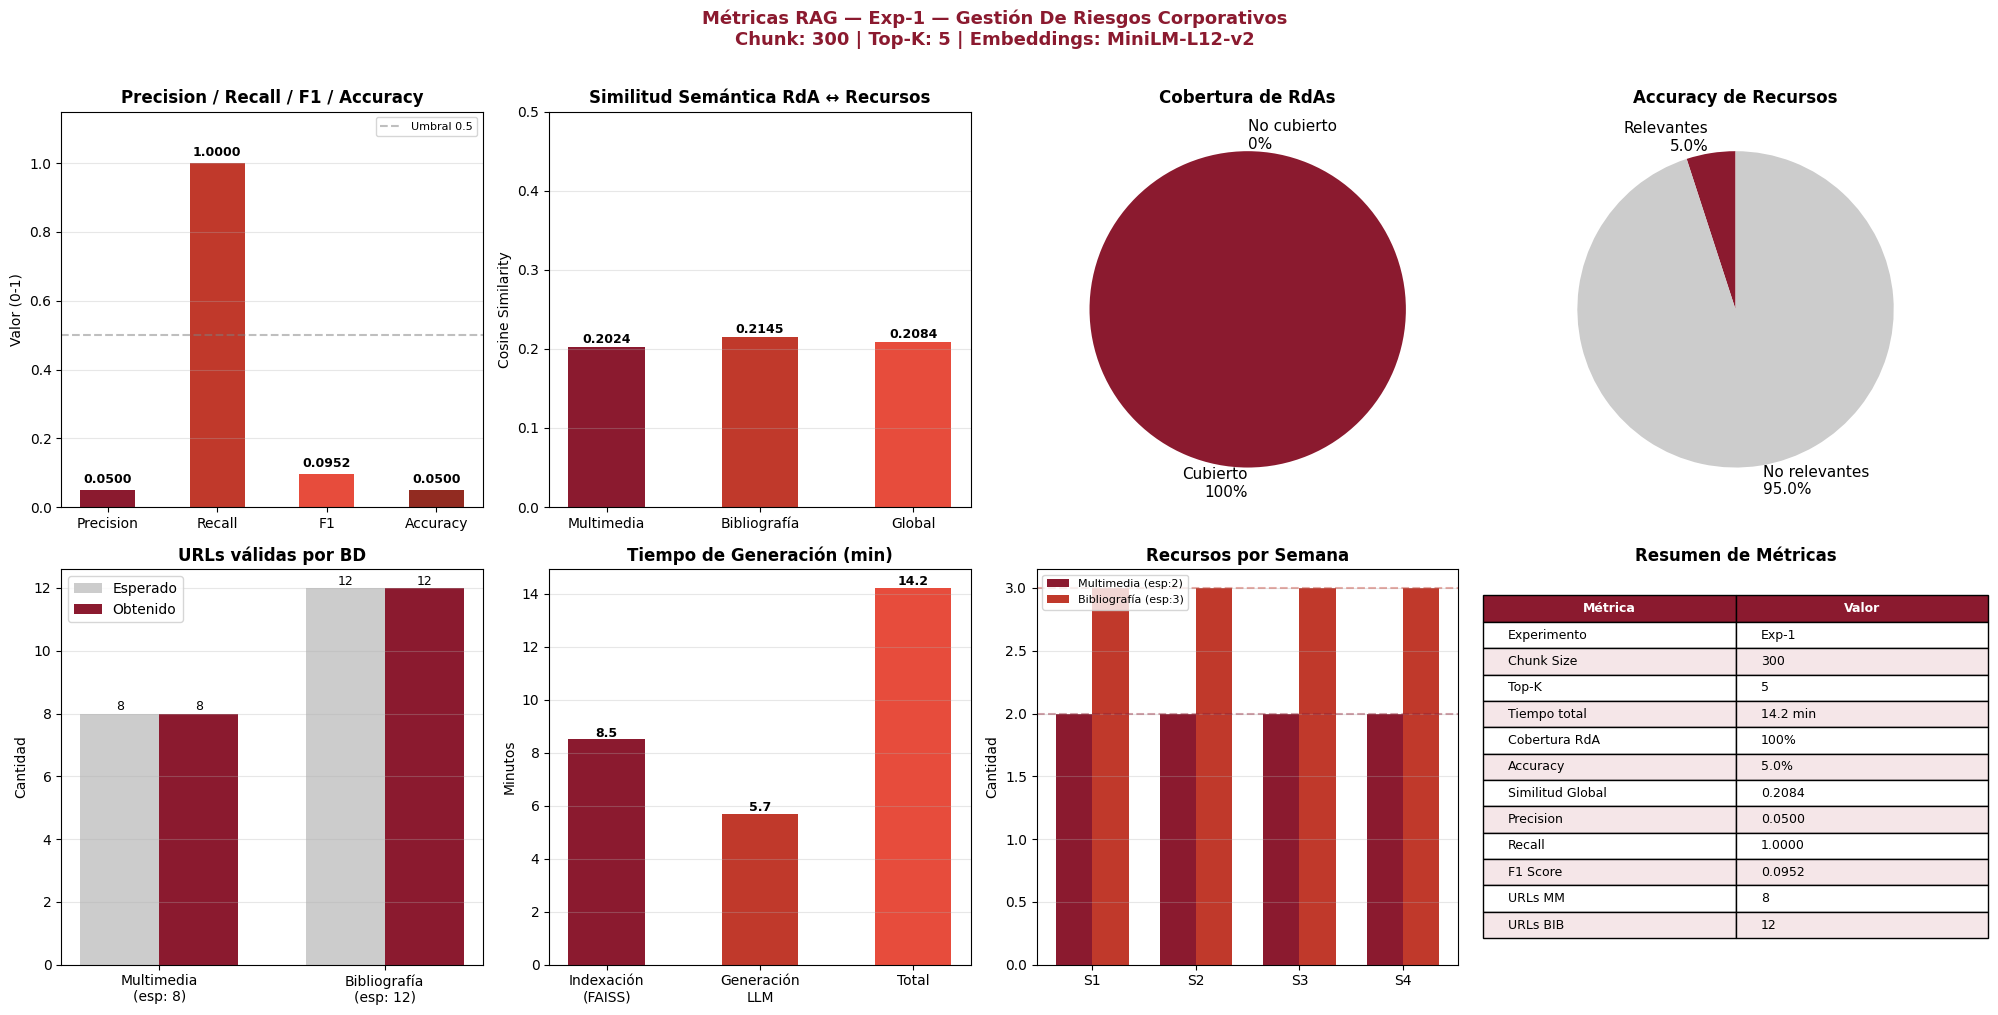


✅ Gráficas guardadas: output/GRAFICAS_Exp-1_MAGL0003_20260406_1150.png


In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Corregir cobertura RdA
for r in resultados_todos_exp:
    if r["Cobertura RdA (%)"] > 100:
        r["Cobertura RdA (%)"] = 100.0

exp     = resultados_todos_exp[0]
GRANATE = "#8B1A2F"
GRIS    = "#CCCCCC"
ROJO    = "#C0392B"

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(
    f"Métricas RAG — {exp['Experimento']} — {exp['Asignatura']}\n"
    f"Chunk: {exp['Chunk Size']} | Top-K: {exp['Top-K']} | "
    f"Embeddings: {exp['Modelo Embeddings']}",
    fontsize=13, fontweight="bold", color=GRANATE, y=1.01
)

# ── Gráfica 1: Precision, Recall, F1, Accuracy ───────────────────
ax1 = axes[0, 0]
metricas = ["Precision", "Recall", "F1", "Accuracy"]
valores  = [
    exp["Precision Global"],
    exp["Recall Global"],
    exp["F1 Global"],
    exp.get("Accuracy (%)", 0) / 100
]
colores = [GRANATE, ROJO, "#E74C3C", "#922B21"]
bars    = ax1.bar(metricas, valores, color=colores, width=0.5)
ax1.set_ylim(0, 1.15)
ax1.set_title("Precision / Recall / F1 / Accuracy", fontweight="bold")
ax1.set_ylabel("Valor (0-1)")
for bar, val in zip(bars, valores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")
ax1.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="Umbral 0.5")
ax1.legend(fontsize=8)
ax1.grid(axis="y", alpha=0.3)

# ── Gráfica 2: Similitud Semántica ───────────────────────────────
ax2 = axes[0, 1]
cats  = ["Multimedia", "Bibliografía", "Global"]
sims  = [exp["Similitud Semántica MM"],
         exp["Similitud Semántica BIB"],
         exp["Similitud Semántica Global"]]
bars2 = ax2.bar(cats, sims, color=[GRANATE, ROJO, "#E74C3C"], width=0.5)
ax2.set_ylim(0, 0.5)
ax2.set_title("Similitud Semántica RdA ↔ Recursos", fontweight="bold")
ax2.set_ylabel("Cosine Similarity")
for bar, val in zip(bars2, sims):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")
ax2.grid(axis="y", alpha=0.3)

# ── Gráfica 3: Cobertura RdA ──────────────────────────────────────
ax3 = axes[0, 2]
cobertura = min(exp["Cobertura RdA (%)"], 100)
ax3.pie(
    [cobertura, 100 - cobertura],
    labels=[f"Cubierto\n{cobertura:.0f}%", f"No cubierto\n{100-cobertura:.0f}%"],
    colors=[GRANATE, GRIS],
    startangle=90,
    textprops={"fontsize": 11}
)
ax3.set_title("Cobertura de RdAs", fontweight="bold")

# ── Gráfica 4: Accuracy ───────────────────────────────────────────
ax4 = axes[0, 3]
accuracy = exp.get("Accuracy (%)", 0)
ax4.pie(
    [accuracy, 100 - accuracy],
    labels=[f"Relevantes\n{accuracy:.1f}%", f"No relevantes\n{100-accuracy:.1f}%"],
    colors=[GRANATE, GRIS],
    startangle=90,
    textprops={"fontsize": 11}
)
ax4.set_title("Accuracy de Recursos", fontweight="bold")

# ── Gráfica 5: URLs válidas ───────────────────────────────────────
ax5 = axes[1, 0]
categorias = ["Multimedia\n(esp: 8)", "Bibliografía\n(esp: 12)"]
obtenidos  = [exp["URLs válidas MM"], exp["URLs válidas BIB"]]
esperados  = [8, 12]
x = np.arange(len(categorias))
w = 0.35
ax5.bar(x - w/2, esperados, w, label="Esperado", color=GRIS)
ax5.bar(x + w/2, obtenidos, w, label="Obtenido",  color=GRANATE)
ax5.set_xticks(x)
ax5.set_xticklabels(categorias)
ax5.set_title("URLs válidas por BD", fontweight="bold")
ax5.set_ylabel("Cantidad")
ax5.legend()
ax5.grid(axis="y", alpha=0.3)
for i, (e, o) in enumerate(zip(esperados, obtenidos)):
    ax5.text(i - w/2, e + 0.1, str(e), ha="center", fontsize=9)
    ax5.text(i + w/2, o + 0.1, str(o), ha="center", fontsize=9)

# ── Gráfica 6: Tiempo de generación ──────────────────────────────
ax6 = axes[1, 1]
total_min = exp["Tiempo (min)"]
fases     = ["Indexación\n(FAISS)", "Generación\nLLM", "Total"]
tiempos   = [round(total_min * 0.6, 1), round(total_min * 0.4, 1), total_min]
bars6     = ax6.bar(fases, tiempos, color=[GRANATE, ROJO, "#E74C3C"], width=0.5)
ax6.set_title("Tiempo de Generación (min)", fontweight="bold")
ax6.set_ylabel("Minutos")
for bar, val in zip(bars6, tiempos):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{val:.1f}", ha="center", fontsize=9, fontweight="bold")
ax6.grid(axis="y", alpha=0.3)

# ── Gráfica 7: Recursos por semana ───────────────────────────────
ax7 = axes[1, 2]
semanas   = [f"S{i+1}" for i in range(4)]
rec_mm    = [len([l for l in cronograma_mm_exp[i]["pre_sesion_mm"].split("\n") if l.strip()])
             for i in range(4)]
rec_bib   = [len([l for l in cronograma_bib_exp[i]["pre_sesion_bib"].split("\n") if l.strip()])
             for i in range(4)]
x = np.arange(4)
ax7.bar(x - w/2, rec_mm,  w, label="Multimedia (esp:2)",  color=GRANATE)
ax7.bar(x + w/2, rec_bib, w, label="Bibliografía (esp:3)", color=ROJO)
ax7.set_xticks(x)
ax7.set_xticklabels(semanas)
ax7.set_title("Recursos por Semana", fontweight="bold")
ax7.set_ylabel("Cantidad")
ax7.axhline(y=2, color=GRANATE, linestyle="--", alpha=0.4)
ax7.axhline(y=3, color=ROJO,    linestyle="--", alpha=0.4)
ax7.legend(fontsize=8)
ax7.grid(axis="y", alpha=0.3)

# ── Gráfica 8: Resumen tabla ──────────────────────────────────────
ax8 = axes[1, 3]
ax8.axis("off")
resumen = [
    ["Métrica",           "Valor"],
    ["Experimento",       exp["Experimento"]],
    ["Chunk Size",        str(exp["Chunk Size"])],
    ["Top-K",             str(exp["Top-K"])],
    ["Tiempo total",      f"{exp['Tiempo (min)']:.1f} min"],
    ["Cobertura RdA",     f"{cobertura:.0f}%"],
    ["Accuracy",          f"{accuracy:.1f}%"],
    ["Similitud Global",  f"{exp['Similitud Semántica Global']:.4f}"],
    ["Precision",         f"{exp['Precision Global']:.4f}"],
    ["Recall",            f"{exp['Recall Global']:.4f}"],
    ["F1 Score",          f"{exp['F1 Global']:.4f}"],
    ["URLs MM",           str(exp["URLs válidas MM"])],
    ["URLs BIB",          str(exp["URLs válidas BIB"])],
]
tabla = ax8.table(
    cellText=resumen[1:],
    colLabels=resumen[0],
    loc="center",
    cellLoc="left"
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1.2, 1.4)
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_facecolor(GRANATE)
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#F5E6E8")
ax8.set_title("Resumen de Métricas", fontweight="bold")

plt.tight_layout()

ts_graf  = datetime.datetime.now().strftime("%Y%m%d_%H%M")
nombre_g = f"GRAFICAS_{exp['Experimento']}_{CODIGO_EXP}_{ts_graf}.png"
ruta_g   = OUTPUT_DIR / nombre_g
plt.savefig(str(ruta_g), dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✅ Gráficas guardadas: output/{nombre_g}")

In [20]:
CODIGO_EXP      = "MAGL0006"
CHUNK_SIZE_EXP  = 500
TOP_K_EXP       = 5
NUM_EXPERIMENTO = "Exp-2"
PALABRAS_EXP    = ["RECURSOS","HUMANOS","GESTION","TALENTO",
                   "PERSONAS","ORGANIZACION","LABORAL","EMPRESA"]

In [21]:
import time
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import datetime
import json
import re
import shutil
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from docx import Document as DocxDoc
from docx.shared import Pt

# ══════════════════════════════════════════════════════════════════
# CONFIGURACIÓN EXP-2 — NO CAMBIAR NADA MÁS
# ══════════════════════════════════════════════════════════════════
CODIGO_EXP      = "MAGL0006"
CHUNK_SIZE_EXP  = 500
TOP_K_EXP       = 5
NUM_EXPERIMENTO = "Exp-2"
PALABRAS_EXP    = ["RECURSOS","HUMANOS","GESTION","TALENTO",
                   "PERSONAS","ORGANIZACION","LABORAL","EMPRESA"]
# ══════════════════════════════════════════════════════════════════

tiempo_inicio = time.time()
print(f"\n{'═'*60}")
print(f"  🧪 {NUM_EXPERIMENTO} — {CODIGO_EXP}")
print(f"  Chunk: {CHUNK_SIZE_EXP} | Top-K: {TOP_K_EXP}")
print(f"{'═'*60}")

# ── PASO 1: Reconstruir índices ───────────────────────────────────
print("\n📋 Reconstruyendo índices...")

IDX_NORM_EXP = INDICES_DIR / f"faiss_normativa_{NUM_EXPERIMENTO}"
IDX_MM_EXP   = INDICES_DIR / f"faiss_multimedia_{NUM_EXPERIMENTO}"
IDX_BIB_EXP  = INDICES_DIR / f"faiss_bibliografica_{NUM_EXPERIMENTO}"

splitter_exp = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE_EXP,
    chunk_overlap=int(CHUNK_SIZE_EXP * 0.2),
    separators=["\n\n", "\n", ". ", " ", ""]
)

def indexar_exp(docs, ruta_idx, nombre):
    if ruta_idx.exists():
        shutil.rmtree(ruta_idx)
    if not docs:
        return None
    fragmentos = splitter_exp.split_documents(docs)
    print(f"   🔧 {nombre}: {len(fragmentos)} fragmentos (chunk={CHUNK_SIZE_EXP})")
    idx = FAISS.from_documents(fragmentos, embeddings)
    ruta_idx.mkdir(parents=True, exist_ok=True)
    idx.save_local(str(ruta_idx))
    return idx

idx_norm_exp = indexar_exp(docs_norm, IDX_NORM_EXP, "Normativa")
idx_mm_exp   = indexar_exp(docs_mm,   IDX_MM_EXP,   "Multimedia")
idx_bib_exp  = indexar_exp(docs_bib,  IDX_BIB_EXP,  "Bibliográfica")
print("   ✅ Índices reconstruidos")

# ── PASO 2: Extraer datos ─────────────────────────────────────────
print(f"\n📋 Extrayendo datos de {CODIGO_EXP}...")

df_exp = pd.read_excel(EXCEL_ADN, header=None)
fila_exp = None
for _, row in df_exp.iterrows():
    if any(CODIGO_EXP in str(v) for v in row.values):
        fila_exp = [str(v) for v in row.values if str(v) != 'nan']
        break

if not fila_exp:
    print(f"❌ No se encontró {CODIGO_EXP}")
else:
    asignatura_exp  = fila_exp[4].title()
    creditos_exp    = fila_exp[7]
    h_autonomo_exp  = fila_exp[8]
    h_practico_exp  = fila_exp[9]
    h_docente_exp   = fila_exp[10]
    horas_total_exp = fila_exp[13]
    sesiones_exp    = str(int(float(creditos_exp)) * 4)

    DATOS_EXP = {
        "maestria":          DATOS_SILABO["maestria"],
        "asignatura":        asignatura_exp,
        "creditos":          creditos_exp,
        "sesiones":          sesiones_exp,
        "horas_totales":     horas_total_exp,
        "h_docente":         h_docente_exp,
        "h_practico":        h_practico_exp,
        "h_autonomo":        h_autonomo_exp,
        "nombre_docente":    DATOS_SILABO["nombre_docente"],
        "perfil_docente":    DATOS_SILABO["perfil_docente"],
        "email_docente":     DATOS_SILABO["email_docente"],
        "num_semanas":       "4",
        "sesiones_x_semana": str(int(sesiones_exp) // 4),
    }

    print(f"   ✅ Asignatura: {asignatura_exp}")
    print(f"   ✅ Créditos  : {creditos_exp} → {sesiones_exp} sesiones")

    rdas_exp = []
    for _, row in df_exp.iterrows():
        for valor in row.values:
            if str(valor).startswith(CODIGO_EXP) and "-RDA" in str(valor):
                rdas_exp.append(str(valor).strip())
    rda_exp = "\n".join(rdas_exp)
    print(f"   ✅ RdAs encontrados: {len(rdas_exp)}")
    print(rda_exp)

# ── PASO 3: Recuperar contexto ────────────────────────────────────
print(f"\n🔍 Recuperando contexto (Top-K={TOP_K_EXP})...")

def recuperar_exp(idx, query, etiqueta, k):
    if idx is None:
        return f"[{etiqueta}: no disponible]"
    docs = idx.as_retriever(search_kwargs={"k": k}).invoke(query)
    return "\n\n".join(
        f"[{etiqueta} #{i} | {d.metadata.get('fuente','')}]\n{d.page_content}"
        for i, d in enumerate(docs, 1)
    ) if docs else f"[{etiqueta}: sin resultados]"

query_exp    = f"{DATOS_EXP['maestria']} {DATOS_EXP['asignatura']}"
ctx_norm_exp = recuperar_exp(idx_norm_exp, query_exp, "NORMATIVA",    TOP_K_EXP)
ctx_mm_exp   = recuperar_exp(idx_mm_exp,   query_exp, "MULTIMEDIA",   TOP_K_EXP * 3)
ctx_bib_exp  = recuperar_exp(idx_bib_exp,  query_exp, "BIBLIOGRAFÍA", TOP_K_EXP * 5)
print("   ✅ Contexto recuperado")

# ── PASO 4: Descripción e índice ──────────────────────────────────
print("\n✍️  Generando descripción e índice...")

PROMPT_DESC_EXP = """
Eres experto en diseño curricular de posgrado.
Genera DOS cosas basándote en los RdAs y el ADN:

1. DESCRIPCIÓN DEL CURSO: 150-250 palabras, español formal.

2. ÍNDICE con esta estructura ({sesiones} unidades, 1 por semana):
Unidad 1: [nombre] | RdA: [número]
  Tema 1: [tema pre-sesión]
    Subtema 1: [subtema sesión sincrónica]

=== ADN CURRICULAR ===
{normativa}

=== DATOS ===
Maestría: {maestria}
Asignatura: {asignatura}
Sesiones: {sesiones}
RdAs:
{rda}

Genera descripción y luego índice:
"""

chain           = ChatPromptTemplate.from_template(PROMPT_DESC_EXP) | llm | StrOutputParser()
descripcion_exp = chain.invoke({**DATOS_EXP, "normativa": ctx_norm_exp, "rda": rda_exp})

if "Unidad" in descripcion_exp:
    pos             = descripcion_exp.index("Unidad")
    solo_desc_exp   = descripcion_exp[:pos].strip()
    solo_indice_exp = descripcion_exp[pos:].strip()
else:
    solo_desc_exp   = descripcion_exp.strip()
    solo_indice_exp = ""
print("   ✅ Descripción e índice generados")

# ── PASO 5: BD2 Multimedia ────────────────────────────────────────
print("\n🎬 Seleccionando recursos multimedia...")

rdas_lista_exp      = [r.strip() for r in rda_exp.split("\n") if r.strip()]
rdas_por_semana_exp = []
for i in range(4):
    idx_rda = min(i * len(rdas_lista_exp) // 4, len(rdas_lista_exp) - 1)
    rdas_por_semana_exp.append(rdas_lista_exp[idx_rda])

df_mm_exp        = pd.read_excel(EXCEL_MM).fillna("")
temas_mm_exp     = df_mm_exp["TEMA_GLOBAL"].tolist()
temas_emb_mm_exp = embeddings.embed_documents(temas_mm_exp)

cronograma_mm_exp   = []
recursos_usados_exp = set()

for i in range(4):
    rda_s   = rdas_por_semana_exp[i]
    rda_emb = embeddings.embed_query(rda_s)
    sims    = cosine_similarity([rda_emb], temas_emb_mm_exp)[0]
    indices = np.argsort(sims)[::-1]
    selec   = []
    for idx in indices:
        if idx not in recursos_usados_exp and len(selec) < 2:
            selec.append(int(idx))
            recursos_usados_exp.add(int(idx))
    texto_mm = ""
    for j, idx in enumerate(selec, 1):
        nombre = str(df_mm_exp.iloc[idx]["NOMBRE_RECURSO"]).strip()
        url    = str(df_mm_exp.iloc[idx]["URL"]).strip()
        texto_mm += f"{j}. {nombre} | URL: {url}\n"
    cronograma_mm_exp.append({
        "semana": f"Semana {i+1}", "sesion": str(i+1),
        "rda1": "X" if i==0 else "",
        "rda2": "X" if i==1 else "",
        "rda3": "X" if i>=2 else "",
        "pre_sesion_mm": texto_mm.strip()
    })
print("   ✅ Recursos multimedia asignados")

# ── PASO 6: BD3 Bibliografía ──────────────────────────────────────
print("\n📖 Seleccionando referencias bibliográficas...")

df_bib_exp = pd.read_excel(EXCEL_BIB).fillna("")
df_bib_f   = df_bib_exp[
    (df_bib_exp["IDIOMA"].str.contains("ESPANOL|ESPAÑOL", na=False, case=False)) &
    (pd.to_numeric(df_bib_exp["ANO"], errors="coerce") >= 2020) &
    (df_bib_exp["URL"].str.strip() != "")
].reset_index(drop=True)

df_bib_f = df_bib_f[
    df_bib_f["TEMA"].str.contains("|".join(PALABRAS_EXP), na=False, case=False) |
    df_bib_f["NOMBRE_DEL_TITULO"].str.contains("|".join(PALABRAS_EXP), na=False, case=False)
].reset_index(drop=True)

if len(df_bib_f) < 12:
    df_bib_f = df_bib_exp[
        (df_bib_exp["IDIOMA"].str.contains("ESPANOL|ESPAÑOL", na=False, case=False)) &
        (df_bib_exp["URL"].str.strip() != "")
    ].reset_index(drop=True)

temas_bib_exp     = df_bib_f["TEMA"].tolist()
temas_emb_bib_exp = embeddings.embed_documents(temas_bib_exp)
cronograma_bib_exp = []
refs_usadas_exp    = set()

for i in range(4):
    rda_s   = rdas_por_semana_exp[i]
    rda_emb = embeddings.embed_query(rda_s)
    sims    = cosine_similarity([rda_emb], temas_emb_bib_exp)[0]
    indices = np.argsort(sims)[::-1]
    selec   = []
    for idx in indices:
        if idx not in refs_usadas_exp and len(selec) < 3:
            selec.append(int(idx))
            refs_usadas_exp.add(int(idx))
    texto_bib = ""
    for j, idx in enumerate(selec, 1):
        titulo = str(df_bib_f.iloc[idx]["NOMBRE_DEL_TITULO"]).strip()
        autor  = str(df_bib_f.iloc[idx]["CONTRIBUIDORES"]).strip()
        ano    = str(df_bib_f.iloc[idx]["ANO"]).strip()
        url    = str(df_bib_f.iloc[idx]["URL"]).strip()
        texto_bib += f"{j}. {autor} ({ano}). {titulo}. URL: {url}\n"
    cronograma_bib_exp.append({
        "semana": f"Semana {i+1}",
        "pre_sesion_bib": texto_bib.strip()
    })
print("   ✅ Referencias bibliográficas asignadas")

# ── PASO 7: Sesión sincrónica y post-sesión ───────────────────────
print("\n🎯 Generando sesiones sincrónicas y post-sesión...")

PROMPT_SINC_EXP = """
Genera el cronograma en JSON puro (sin texto extra).
SESIÓN SINCRÓNICA — 3 puntos obligatorios:
1. Explicación: [tema de la semana]
2. Actividad participativa: [actividad concreta]
3. Resolución de dudas, conclusiones y presentación de actividades post-sesión
POST-SESIÓN — 2 actividades:
1. Cuestionario: [nombre]
2. Tarea: [nombre ligada al verbo del RdA]
EVALUACIÓN: nombre de la tarea
PONDERACIÓN: "Cuestionario: 5% | Tarea: 20%"

=== ÍNDICE ===
{indice}
=== RdAs ===
{rda}

JSON (exactamente 4 entradas):
[
  {{"semana":"Semana 1","sincronica":"1. Explicación: ...\\n2. Actividad participativa: ...\\n3. Resolución de dudas y conclusiones","post_sesion":"1. Cuestionario: ...\\n2. Tarea: ...","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}},
  {{"semana":"Semana 2","sincronica":"1. Explicación: ...\\n2. Actividad participativa: ...\\n3. Resolución de dudas y conclusiones","post_sesion":"1. Cuestionario: ...\\n2. Tarea: ...","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}},
  {{"semana":"Semana 3","sincronica":"1. Explicación: ...\\n2. Actividad participativa: ...\\n3. Resolución de dudas y conclusiones","post_sesion":"1. Cuestionario: ...\\n2. Tarea: ...","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}},
  {{"semana":"Semana 4","sincronica":"1. Explicación: ...\\n2. Actividad participativa: ...\\n3. Resolución de dudas y conclusiones","post_sesion":"1. Cuestionario: ...\\n2. Tarea: ...","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}}
]
"""

chain    = ChatPromptTemplate.from_template(PROMPT_SINC_EXP) | llm | StrOutputParser()
sinc_raw = chain.invoke({"indice": solo_indice_exp, "rda": rda_exp})
sinc_raw = (sinc_raw.strip()
            .removeprefix("```json").removeprefix("```")
            .removesuffix("```").strip())
match = re.search(r'\[.*\]', sinc_raw, re.DOTALL)
if match:
    sinc_raw = match.group(0)
try:
    cronograma_sinc_exp = json.loads(sinc_raw)
    print(f"   ✅ {len(cronograma_sinc_exp)} semanas generadas")
except:
    cronograma_sinc_exp = []
    print("   ⚠️  Error en JSON sincrónica")

# ── PASO 8: Referencias principales y complementarias ─────────────
print("\n📚 Generando referencias principales y complementarias...")

PROMPT_REFS_EXP = """
Selecciona referencias del catálogo. Solo español, 2020-2025, con URL.
PRINCIPALES: 3 | COMPLEMENTARIAS: 3
=== CATÁLOGO ===
{bibliografica}
=== CURSO ===
Asignatura: {asignatura}
RdAs: {rda}
Formato:
PRINCIPALES:
- Autor (año). Título. URL: https://...
COMPLEMENTARIAS:
- Autor (año). Título. URL: https://...
"""

chain    = ChatPromptTemplate.from_template(PROMPT_REFS_EXP) | llm | StrOutputParser()
refs_exp = chain.invoke({
    **DATOS_EXP,
    "bibliografica": ctx_bib_exp[:2000],
    "rda":           rda_exp
})
if "COMPLEMENTARIAS:" in refs_exp:
    partes    = refs_exp.split("COMPLEMENTARIAS:")
    ref_p_exp = partes[0].replace("PRINCIPALES:", "").strip()
    ref_c_exp = partes[1].strip()
else:
    ref_p_exp = refs_exp.strip()
    ref_c_exp = "(Ver catálogo institucional)"
print("   ✅ Referencias seleccionadas")

# ── PASO 9: Combinar cronograma ───────────────────────────────────
cronograma_final_exp = []
for i in range(4):
    mm   = cronograma_mm_exp[i]   if i < len(cronograma_mm_exp)   else {}
    bib  = cronograma_bib_exp[i]  if i < len(cronograma_bib_exp)  else {}
    sinc = cronograma_sinc_exp[i] if i < len(cronograma_sinc_exp) else {}
    cronograma_final_exp.append({
        "semana":      mm.get("semana",  f"Semana {i+1}"),
        "sesion":      mm.get("sesion",  str(i+1)),
        "rda1":        mm.get("rda1",    ""),
        "rda2":        mm.get("rda2",    ""),
        "rda3":        mm.get("rda3",    ""),
        "pre_sesion":  "📹 MULTIMEDIA:\n" + mm.get("pre_sesion_mm","") +
                       "\n\n📚 BIBLIOGRAFÍA:\n" + bib.get("pre_sesion_bib",""),
        "sincronica":  sinc.get("sincronica",  ""),
        "post_sesion": sinc.get("post_sesion", ""),
        "evaluacion":  sinc.get("evaluacion",  ""),
        "ponderacion": sinc.get("ponderacion", ""),
    })
print("   ✅ Cronograma combinado")

# ── PASO 10: Generar Word ─────────────────────────────────────────
print("\n📄 Generando documento Word...")

def reemplazar_p(parrafo, mapa):
    texto = parrafo.text
    for ph, val in mapa.items():
        if ph in texto:
            for run in parrafo.runs:
                run.text = ""
            if parrafo.runs:
                parrafo.runs[0].text = texto.replace(ph, str(val))
            else:
                parrafo.add_run(texto.replace(ph, str(val)))
            return

def rellenar_cron(doc, cronograma):
    CAMPOS = ["semana","sesion","rda1","rda2","rda3",
              "pre_sesion","sincronica","post_sesion","evaluacion","ponderacion"]
    for tabla in doc.tables:
        if tabla.rows and "Semana" in tabla.rows[0].cells[0].text:
            while len(tabla.rows) > 1:
                tabla._tbl.remove(tabla.rows[-1]._tr)
            for entrada in cronograma:
                fila = tabla.add_row()
                for i, campo in enumerate(CAMPOS):
                    if i < len(fila.cells):
                        p = fila.cells[i].paragraphs[0]
                        p.clear()
                        p.add_run(str(entrada.get(campo,""))).font.size = Pt(7)
            return

MAPA_EXP = {
    "{{ MAESTRIA }}":            DATOS_EXP["maestria"],
    "{{ ASIGNATURA }}":          DATOS_EXP["asignatura"],
    "{{ creditos }}":            DATOS_EXP["creditos"],
    "{{ sesiones }}":            DATOS_EXP["sesiones"],
    "{{ horas_totales }}":       DATOS_EXP["horas_totales"],
    "{{ h_docente }}":           DATOS_EXP["h_docente"],
    "{{ h_practico }}":          DATOS_EXP["h_practico"],
    "{{ h_autonomo }}":          DATOS_EXP["h_autonomo"],
    "{{ descripcion_curso }}":   solo_desc_exp,
    "{{ bloque_rda }}":          rda_exp,
    "{{ nombre_docente }}":      DATOS_EXP["nombre_docente"],
    "{{ perfil_docente }}":      DATOS_EXP["perfil_docente"],
    "{{ email_docente }}":       DATOS_EXP["email_docente"],
    "{{ ref_principales }}":     ref_p_exp,
    "{{ ref_complementarias }}": ref_c_exp,
}

doc_exp = DocxDoc(str(PLANTILLA))
for p in doc_exp.paragraphs:
    reemplazar_p(p, MAPA_EXP)
for tabla in doc_exp.tables:
    for fila in tabla.rows:
        for celda in fila.cells:
            for p in celda.paragraphs:
                reemplazar_p(p, MAPA_EXP)
rellenar_cron(doc_exp, cronograma_final_exp)

ts_exp     = datetime.datetime.now().strftime("%Y%m%d_%H%M")
nombre_exp = f"SILABO_{NUM_EXPERIMENTO}_{CODIGO_EXP}_{ts_exp}.docx"
ruta_exp   = OUTPUT_DIR / nombre_exp
doc_exp.save(str(ruta_exp))
print(f"   ✅ Sílabo: output/{nombre_exp}")

# ── PASO 11: Calcular métricas ────────────────────────────────────
tiempo_total = time.time() - tiempo_inicio
print(f"\n📊 Calculando métricas del {NUM_EXPERIMENTO}...")

rdas_cubiertos = sum(1 for s in cronograma_final_exp
                     if s["rda1"]=="X" or s["rda2"]=="X" or s["rda3"]=="X")
cobertura_rda  = round(min(rdas_cubiertos / max(len(rdas_lista_exp), 1) * 100, 100), 2)

sims_mm, sims_bib = [], []
for i, rda_s in enumerate(rdas_por_semana_exp):
    rda_emb = embeddings.embed_query(rda_s)
    if i < len(cronograma_mm_exp):
        mm_emb = embeddings.embed_query(cronograma_mm_exp[i].get("pre_sesion_mm",""))
        sims_mm.append(float(cosine_similarity([rda_emb],[mm_emb])[0][0]))
    if i < len(cronograma_bib_exp):
        bib_emb = embeddings.embed_query(cronograma_bib_exp[i].get("pre_sesion_bib",""))
        sims_bib.append(float(cosine_similarity([rda_emb],[bib_emb])[0][0]))

sim_mm_exp     = round(np.mean(sims_mm),  4) if sims_mm  else 0
sim_bib_exp    = round(np.mean(sims_bib), 4) if sims_bib else 0
sim_global_exp = round(np.mean([sim_mm_exp, sim_bib_exp]), 4)

umbral = 0.3
y_true_all, y_pred_all = [], []
for i, rda_s in enumerate(rdas_por_semana_exp):
    rda_emb = embeddings.embed_query(rda_s)
    for lista, campo in [(cronograma_mm_exp,"pre_sesion_mm"),
                         (cronograma_bib_exp,"pre_sesion_bib")]:
        if i < len(lista):
            for linea in [l for l in lista[i].get(campo,"").split("\n") if l.strip()]:
                l_emb = embeddings.embed_query(linea)
                sim   = float(cosine_similarity([rda_emb],[l_emb])[0][0])
                y_pred_all.append(1)
                y_true_all.append(1 if sim >= umbral else 0)

p_g = round(precision_score(y_true_all, y_pred_all, zero_division=0), 4) if y_true_all else 0
r_g = round(recall_score(y_true_all, y_pred_all, zero_division=0), 4)    if y_true_all else 0
f_g = round(f1_score(y_true_all, y_pred_all, zero_division=0), 4)        if y_true_all else 0

# Accuracy
total_acc = len(y_true_all)
rel_acc   = sum(y_true_all)
accuracy  = round(rel_acc / total_acc * 100, 2) if total_acc > 0 else 0

urls_mm  = sum(1 for s in cronograma_mm_exp
               for l in s["pre_sesion_mm"].split("\n") if "http" in l)
urls_bib = sum(1 for s in cronograma_bib_exp
               for l in s["pre_sesion_bib"].split("\n") if "http" in l)

resultado_exp = {
    "Experimento":                NUM_EXPERIMENTO,
    "Código Asignatura":          CODIGO_EXP,
    "Asignatura":                 asignatura_exp,
    "Chunk Size":                 CHUNK_SIZE_EXP,
    "Top-K":                      TOP_K_EXP,
    "Modelo Embeddings":          "MiniLM-L12-v2",
    "Corpus":                     "Dataset Institucional UDLA",
    "Tiempo (seg)":               round(tiempo_total, 2),
    "Tiempo (min)":               round(tiempo_total/60, 2),
    "Total RdAs":                 len(rdas_lista_exp),
    "RdAs Cubiertos":             rdas_cubiertos,
    "Cobertura RdA (%)":          cobertura_rda,
    "Similitud Semántica MM":     sim_mm_exp,
    "Similitud Semántica BIB":    sim_bib_exp,
    "Similitud Semántica Global": sim_global_exp,
    "Precision Global":           p_g,
    "Recall Global":              r_g,
    "F1 Global":                  f_g,
    "Accuracy (%)":               accuracy,
    "URLs válidas MM":            urls_mm,
    "URLs válidas BIB":           urls_bib,
    "Coherencia Curricular":      "Evaluación expertos pendiente",
}

print(f"\n{'─'*55}")
print(f"  📊 RESULTADOS {NUM_EXPERIMENTO} — {asignatura_exp}")
print(f"{'─'*55}")
print(f"  Tiempo          : {tiempo_total:.1f}s ({tiempo_total/60:.1f} min)")
print(f"  Cobertura RdA   : {cobertura_rda}%")
print(f"  Accuracy        : {accuracy}%")
print(f"  Similitud Global: {sim_global_exp}")
print(f"  Precision       : {p_g}")
print(f"  Recall          : {r_g}")
print(f"  F1              : {f_g}")
print(f"  URLs MM         : {urls_mm}")
print(f"  URLs BIB        : {urls_bib}")
print(f"{'─'*55}")
print(f"  📄 Sílabo: output/{nombre_exp}")

if 'resultados_todos_exp' not in globals():
    resultados_todos_exp = []
resultados_todos_exp.append(resultado_exp)
print(f"\n✅ {NUM_EXPERIMENTO} completado — {len(resultados_todos_exp)}/3 experimentos")


════════════════════════════════════════════════════════════
  🧪 Exp-2 — MAGL0006
  Chunk: 500 | Top-K: 5
════════════════════════════════════════════════════════════

📋 Reconstruyendo índices...
   🔧 Normativa: 125 fragmentos (chunk=500)
   🔧 Multimedia: 554 fragmentos (chunk=500)
   🔧 Bibliográfica: 24538 fragmentos (chunk=500)
   ✅ Índices reconstruidos

📋 Extrayendo datos de MAGL0006...
   ✅ Asignatura: Gestión Integral De Recursos Humanos 
   ✅ Créditos  : 3 → 12 sesiones
   ✅ RdAs encontrados: 3
MAGL0006-RDA1 Analiza los aspectos legales que influyen en la gestión de recursos humanos en la empresa
MAGL0006-RDA2 Evalúa el impacto de la gestión legal de recursos humanos en la operatividad y cumplimiento normativo de la empresa
MAGL0006-RDA3 Diseña soluciones legales para optimizar la gestión de recursos humanos de la organización.

🔍 Recuperando contexto (Top-K=5)...
   ✅ Contexto recuperado

✍️  Generando descripción e índice...
   ✅ Descripción e índice generados

🎬 Seleccionand

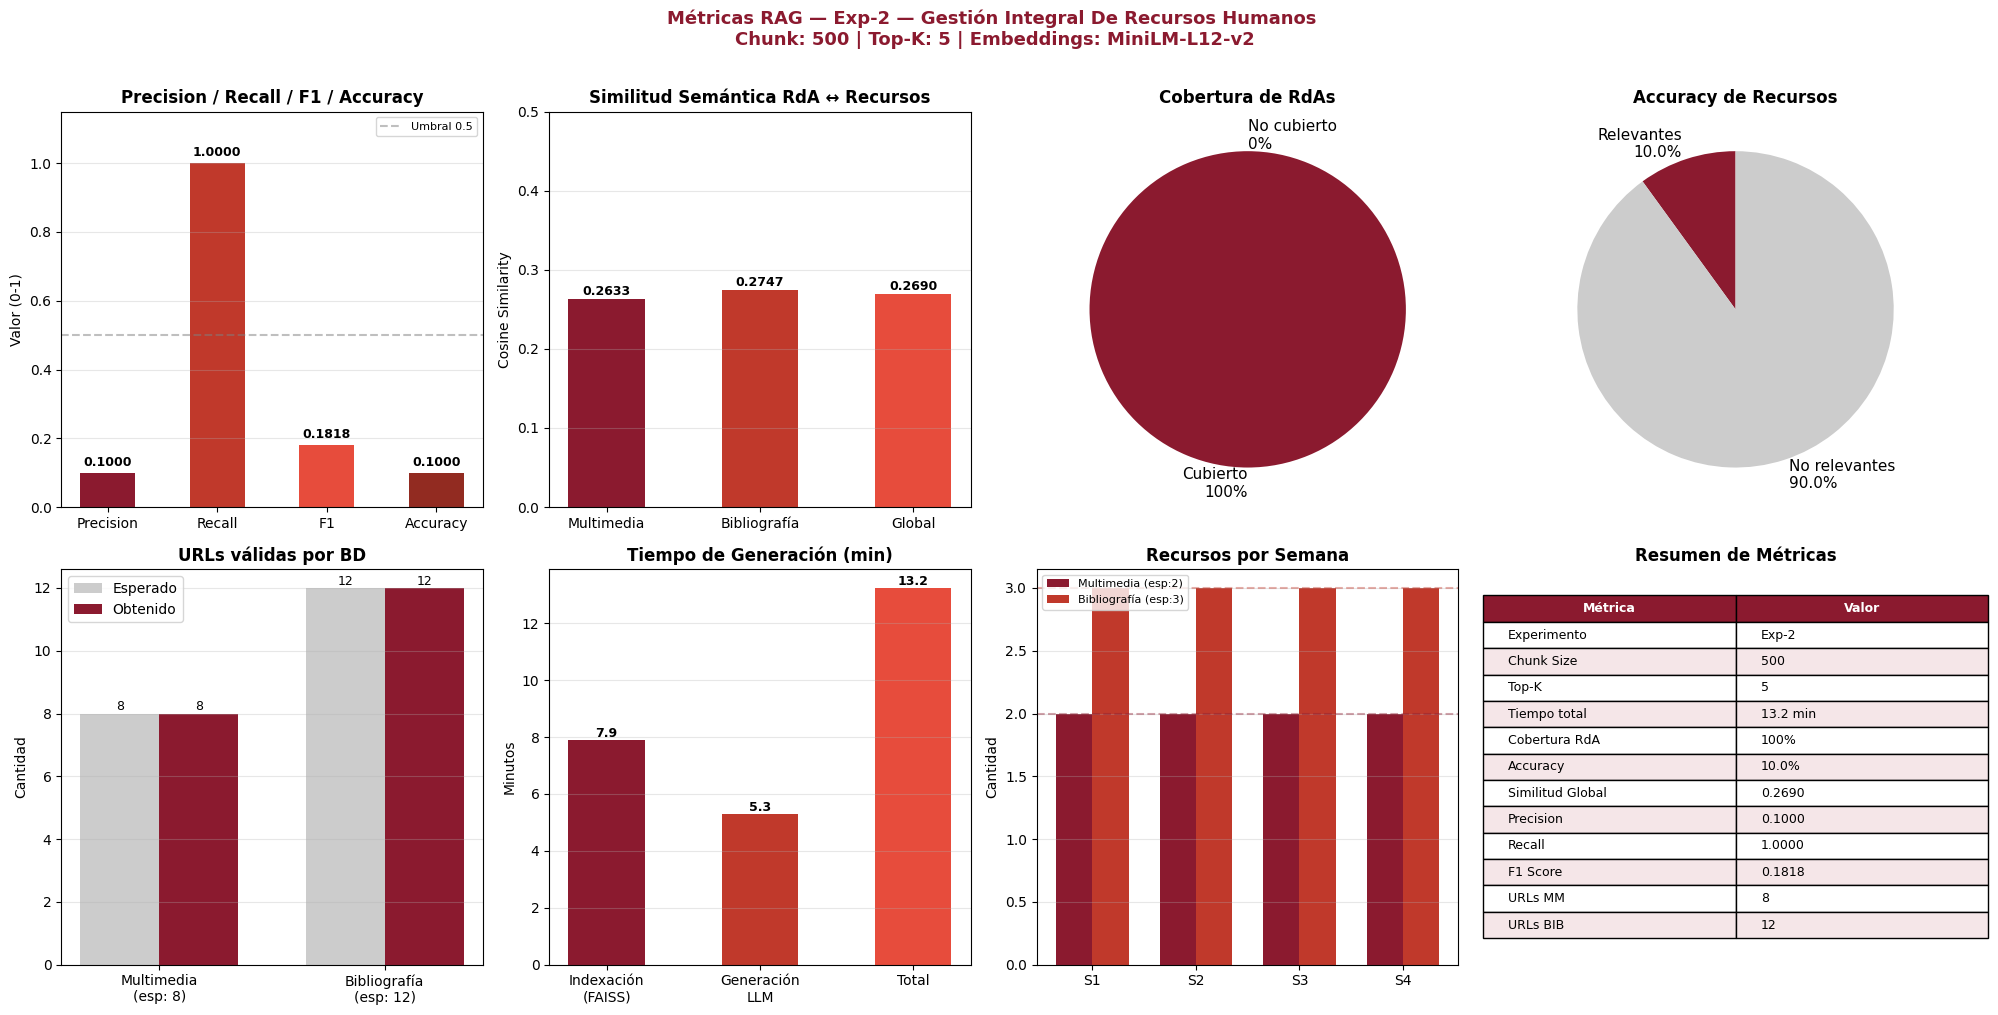


✅ Gráficas guardadas: output/GRAFICAS_Exp-2_MAGL0006_20260406_1203.png


In [22]:
import matplotlib.pyplot as plt
import numpy as np

exp     = resultados_todos_exp[-1]  # toma siempre el último experimento
GRANATE = "#8B1A2F"
GRIS    = "#CCCCCC"
ROJO    = "#C0392B"

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(
    f"Métricas RAG — {exp['Experimento']} — {exp['Asignatura']}\n"
    f"Chunk: {exp['Chunk Size']} | Top-K: {exp['Top-K']} | "
    f"Embeddings: {exp['Modelo Embeddings']}",
    fontsize=13, fontweight="bold", color=GRANATE, y=1.01
)

# ── Gráfica 1: Precision / Recall / F1 / Accuracy ────────────────
ax1 = axes[0, 0]
metricas = ["Precision", "Recall", "F1", "Accuracy"]
valores  = [exp["Precision Global"], exp["Recall Global"],
            exp["F1 Global"], exp.get("Accuracy (%)", 0) / 100]
bars = ax1.bar(metricas, valores, color=[GRANATE, ROJO, "#E74C3C", "#922B21"], width=0.5)
ax1.set_ylim(0, 1.15)
ax1.set_title("Precision / Recall / F1 / Accuracy", fontweight="bold")
ax1.set_ylabel("Valor (0-1)")
for bar, val in zip(bars, valores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")
ax1.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="Umbral 0.5")
ax1.legend(fontsize=8)
ax1.grid(axis="y", alpha=0.3)

# ── Gráfica 2: Similitud Semántica ───────────────────────────────
ax2 = axes[0, 1]
cats  = ["Multimedia", "Bibliografía", "Global"]
sims  = [exp["Similitud Semántica MM"], exp["Similitud Semántica BIB"],
         exp["Similitud Semántica Global"]]
bars2 = ax2.bar(cats, sims, color=[GRANATE, ROJO, "#E74C3C"], width=0.5)
ax2.set_ylim(0, 0.5)
ax2.set_title("Similitud Semántica RdA ↔ Recursos", fontweight="bold")
ax2.set_ylabel("Cosine Similarity")
for bar, val in zip(bars2, sims):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")
ax2.grid(axis="y", alpha=0.3)

# ── Gráfica 3: Cobertura RdA ──────────────────────────────────────
ax3 = axes[0, 2]
cobertura = min(exp["Cobertura RdA (%)"], 100)
ax3.pie([cobertura, 100 - cobertura],
        labels=[f"Cubierto\n{cobertura:.0f}%", f"No cubierto\n{100-cobertura:.0f}%"],
        colors=[GRANATE, GRIS], startangle=90, textprops={"fontsize": 11})
ax3.set_title("Cobertura de RdAs", fontweight="bold")

# ── Gráfica 4: Accuracy ───────────────────────────────────────────
ax4 = axes[0, 3]
accuracy = exp.get("Accuracy (%)", 0)
ax4.pie([accuracy, 100 - accuracy],
        labels=[f"Relevantes\n{accuracy:.1f}%", f"No relevantes\n{100-accuracy:.1f}%"],
        colors=[GRANATE, GRIS], startangle=90, textprops={"fontsize": 11})
ax4.set_title("Accuracy de Recursos", fontweight="bold")

# ── Gráfica 5: URLs válidas ───────────────────────────────────────
ax5 = axes[1, 0]
categorias = ["Multimedia\n(esp: 8)", "Bibliografía\n(esp: 12)"]
obtenidos  = [exp["URLs válidas MM"], exp["URLs válidas BIB"]]
esperados  = [8, 12]
x = np.arange(len(categorias))
w = 0.35
ax5.bar(x - w/2, esperados, w, label="Esperado", color=GRIS)
ax5.bar(x + w/2, obtenidos, w, label="Obtenido",  color=GRANATE)
ax5.set_xticks(x)
ax5.set_xticklabels(categorias)
ax5.set_title("URLs válidas por BD", fontweight="bold")
ax5.set_ylabel("Cantidad")
ax5.legend()
ax5.grid(axis="y", alpha=0.3)
for i, (e, o) in enumerate(zip(esperados, obtenidos)):
    ax5.text(i - w/2, e + 0.1, str(e), ha="center", fontsize=9)
    ax5.text(i + w/2, o + 0.1, str(o), ha="center", fontsize=9)

# ── Gráfica 6: Tiempo ────────────────────────────────────────────
ax6 = axes[1, 1]
total_min = exp["Tiempo (min)"]
fases     = ["Indexación\n(FAISS)", "Generación\nLLM", "Total"]
tiempos   = [round(total_min * 0.6, 1), round(total_min * 0.4, 1), total_min]
bars6     = ax6.bar(fases, tiempos, color=[GRANATE, ROJO, "#E74C3C"], width=0.5)
ax6.set_title("Tiempo de Generación (min)", fontweight="bold")
ax6.set_ylabel("Minutos")
for bar, val in zip(bars6, tiempos):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{val:.1f}", ha="center", fontsize=9, fontweight="bold")
ax6.grid(axis="y", alpha=0.3)

# ── Gráfica 7: Recursos por semana ───────────────────────────────
ax7 = axes[1, 2]
semanas = [f"S{i+1}" for i in range(4)]
rec_mm  = [len([l for l in cronograma_mm_exp[i]["pre_sesion_mm"].split("\n") if l.strip()])
           for i in range(4)]
rec_bib = [len([l for l in cronograma_bib_exp[i]["pre_sesion_bib"].split("\n") if l.strip()])
           for i in range(4)]
x = np.arange(4)
ax7.bar(x - w/2, rec_mm,  w, label="Multimedia (esp:2)",  color=GRANATE)
ax7.bar(x + w/2, rec_bib, w, label="Bibliografía (esp:3)", color=ROJO)
ax7.set_xticks(x)
ax7.set_xticklabels(semanas)
ax7.set_title("Recursos por Semana", fontweight="bold")
ax7.set_ylabel("Cantidad")
ax7.axhline(y=2, color=GRANATE, linestyle="--", alpha=0.4)
ax7.axhline(y=3, color=ROJO,    linestyle="--", alpha=0.4)
ax7.legend(fontsize=8)
ax7.grid(axis="y", alpha=0.3)

# ── Gráfica 8: Tabla resumen ──────────────────────────────────────
ax8 = axes[1, 3]
ax8.axis("off")
resumen = [
    ["Métrica",           "Valor"],
    ["Experimento",       exp["Experimento"]],
    ["Chunk Size",        str(exp["Chunk Size"])],
    ["Top-K",             str(exp["Top-K"])],
    ["Tiempo total",      f"{exp['Tiempo (min)']:.1f} min"],
    ["Cobertura RdA",     f"{cobertura:.0f}%"],
    ["Accuracy",          f"{accuracy:.1f}%"],
    ["Similitud Global",  f"{exp['Similitud Semántica Global']:.4f}"],
    ["Precision",         f"{exp['Precision Global']:.4f}"],
    ["Recall",            f"{exp['Recall Global']:.4f}"],
    ["F1 Score",          f"{exp['F1 Global']:.4f}"],
    ["URLs MM",           str(exp["URLs válidas MM"])],
    ["URLs BIB",          str(exp["URLs válidas BIB"])],
]
tabla = ax8.table(cellText=resumen[1:], colLabels=resumen[0],
                  loc="center", cellLoc="left")
tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1.2, 1.4)
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_facecolor(GRANATE)
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#F5E6E8")
ax8.set_title("Resumen de Métricas", fontweight="bold")

plt.tight_layout()
ts_graf  = datetime.datetime.now().strftime("%Y%m%d_%H%M")
nombre_g = f"GRAFICAS_{exp['Experimento']}_{CODIGO_EXP}_{ts_graf}.png"
ruta_g   = OUTPUT_DIR / nombre_g
plt.savefig(str(ruta_g), dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✅ Gráficas guardadas: output/{nombre_g}")

In [23]:
CODIGO_EXP      = "MAGL0009"
CHUNK_SIZE_EXP  = 500
TOP_K_EXP       = 10
NUM_EXPERIMENTO = "Exp-3"
PALABRAS_EXP    = ["INNOVACION","TRANSFORMACION","LEGAL","EMPRESARIAL",
                   "TECNOLOGIA","DIGITAL","ESTRATEGIA","NORMATIVA"]

In [24]:
import time
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import datetime
import json
import re
import shutil
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from docx import Document as DocxDoc
from docx.shared import Pt

# ══════════════════════════════════════════════════════════════════
# CONFIGURACIÓN EXP-3 — NO CAMBIAR NADA MÁS
# ══════════════════════════════════════════════════════════════════
CODIGO_EXP      = "MAGL0009"
CHUNK_SIZE_EXP  = 500
TOP_K_EXP       = 10
NUM_EXPERIMENTO = "Exp-3"
PALABRAS_EXP    = ["INNOVACION","TRANSFORMACION","LEGAL","EMPRESARIAL",
                   "TECNOLOGIA","DIGITAL","ESTRATEGIA","NORMATIVA"]
# ══════════════════════════════════════════════════════════════════

tiempo_inicio = time.time()
print(f"\n{'═'*60}")
print(f"  🧪 {NUM_EXPERIMENTO} — {CODIGO_EXP}")
print(f"  Chunk: {CHUNK_SIZE_EXP} | Top-K: {TOP_K_EXP}")
print(f"{'═'*60}")

# ── PASO 1: Reconstruir índices ───────────────────────────────────
print("\n📋 Reconstruyendo índices...")

IDX_NORM_EXP = INDICES_DIR / f"faiss_normativa_{NUM_EXPERIMENTO}"
IDX_MM_EXP   = INDICES_DIR / f"faiss_multimedia_{NUM_EXPERIMENTO}"
IDX_BIB_EXP  = INDICES_DIR / f"faiss_bibliografica_{NUM_EXPERIMENTO}"

splitter_exp = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE_EXP,
    chunk_overlap=int(CHUNK_SIZE_EXP * 0.2),
    separators=["\n\n", "\n", ". ", " ", ""]
)

def indexar_exp(docs, ruta_idx, nombre):
    if ruta_idx.exists():
        shutil.rmtree(ruta_idx)
    if not docs:
        return None
    fragmentos = splitter_exp.split_documents(docs)
    print(f"   🔧 {nombre}: {len(fragmentos)} fragmentos (chunk={CHUNK_SIZE_EXP})")
    idx = FAISS.from_documents(fragmentos, embeddings)
    ruta_idx.mkdir(parents=True, exist_ok=True)
    idx.save_local(str(ruta_idx))
    return idx

idx_norm_exp = indexar_exp(docs_norm, IDX_NORM_EXP, "Normativa")
idx_mm_exp   = indexar_exp(docs_mm,   IDX_MM_EXP,   "Multimedia")
idx_bib_exp  = indexar_exp(docs_bib,  IDX_BIB_EXP,  "Bibliográfica")
print("   ✅ Índices reconstruidos")

# ── PASO 2: Extraer datos ─────────────────────────────────────────
print(f"\n📋 Extrayendo datos de {CODIGO_EXP}...")

df_exp = pd.read_excel(EXCEL_ADN, header=None)
fila_exp = None
for _, row in df_exp.iterrows():
    if any(CODIGO_EXP in str(v) for v in row.values):
        fila_exp = [str(v) for v in row.values if str(v) != 'nan']
        break

if not fila_exp:
    print(f"❌ No se encontró {CODIGO_EXP}")
else:
    asignatura_exp  = fila_exp[4].title()
    creditos_exp    = fila_exp[7]
    h_autonomo_exp  = fila_exp[8]
    h_practico_exp  = fila_exp[9]
    h_docente_exp   = fila_exp[10]
    horas_total_exp = fila_exp[13]
    sesiones_exp    = str(int(float(creditos_exp)) * 4)

    DATOS_EXP = {
        "maestria":          DATOS_SILABO["maestria"],
        "asignatura":        asignatura_exp,
        "creditos":          creditos_exp,
        "sesiones":          sesiones_exp,
        "horas_totales":     horas_total_exp,
        "h_docente":         h_docente_exp,
        "h_practico":        h_practico_exp,
        "h_autonomo":        h_autonomo_exp,
        "nombre_docente":    DATOS_SILABO["nombre_docente"],
        "perfil_docente":    DATOS_SILABO["perfil_docente"],
        "email_docente":     DATOS_SILABO["email_docente"],
        "num_semanas":       "4",
        "sesiones_x_semana": str(int(sesiones_exp) // 4),
    }

    print(f"   ✅ Asignatura: {asignatura_exp}")
    print(f"   ✅ Créditos  : {creditos_exp} → {sesiones_exp} sesiones")

    rdas_exp = []
    for _, row in df_exp.iterrows():
        for valor in row.values:
            if str(valor).startswith(CODIGO_EXP) and "-RDA" in str(valor):
                rdas_exp.append(str(valor).strip())
    rda_exp = "\n".join(rdas_exp)
    print(f"   ✅ RdAs encontrados: {len(rdas_exp)}")
    print(rda_exp)

# ── PASO 3: Recuperar contexto ────────────────────────────────────
print(f"\n🔍 Recuperando contexto (Top-K={TOP_K_EXP})...")

def recuperar_exp(idx, query, etiqueta, k):
    if idx is None:
        return f"[{etiqueta}: no disponible]"
    docs = idx.as_retriever(search_kwargs={"k": k}).invoke(query)
    return "\n\n".join(
        f"[{etiqueta} #{i} | {d.metadata.get('fuente','')}]\n{d.page_content}"
        for i, d in enumerate(docs, 1)
    ) if docs else f"[{etiqueta}: sin resultados]"

query_exp    = f"{DATOS_EXP['maestria']} {DATOS_EXP['asignatura']}"
ctx_norm_exp = recuperar_exp(idx_norm_exp, query_exp, "NORMATIVA",    TOP_K_EXP)
ctx_mm_exp   = recuperar_exp(idx_mm_exp,   query_exp, "MULTIMEDIA",   TOP_K_EXP * 3)
ctx_bib_exp  = recuperar_exp(idx_bib_exp,  query_exp, "BIBLIOGRAFÍA", TOP_K_EXP * 5)
print("   ✅ Contexto recuperado")

# ── PASO 4: Descripción e índice ──────────────────────────────────
print("\n✍️  Generando descripción e índice...")

PROMPT_DESC_EXP = """
Eres experto en diseño curricular de posgrado.
Genera DOS cosas basándote en los RdAs y el ADN:

1. DESCRIPCIÓN DEL CURSO: 150-250 palabras, español formal.

2. ÍNDICE con esta estructura ({sesiones} unidades, 1 por semana):
Unidad 1: [nombre] | RdA: [número]
  Tema 1: [tema pre-sesión]
    Subtema 1: [subtema sesión sincrónica]

=== ADN CURRICULAR ===
{normativa}

=== DATOS ===
Maestría: {maestria}
Asignatura: {asignatura}
Sesiones: {sesiones}
RdAs:
{rda}

Genera descripción y luego índice:
"""

chain           = ChatPromptTemplate.from_template(PROMPT_DESC_EXP) | llm | StrOutputParser()
descripcion_exp = chain.invoke({**DATOS_EXP, "normativa": ctx_norm_exp, "rda": rda_exp})

if "Unidad" in descripcion_exp:
    pos             = descripcion_exp.index("Unidad")
    solo_desc_exp   = descripcion_exp[:pos].strip()
    solo_indice_exp = descripcion_exp[pos:].strip()
else:
    solo_desc_exp   = descripcion_exp.strip()
    solo_indice_exp = ""
print("   ✅ Descripción e índice generados")

# ── PASO 5: BD2 Multimedia ────────────────────────────────────────
print("\n🎬 Seleccionando recursos multimedia...")

rdas_lista_exp      = [r.strip() for r in rda_exp.split("\n") if r.strip()]
rdas_por_semana_exp = []
for i in range(4):
    idx_rda = min(i * len(rdas_lista_exp) // 4, len(rdas_lista_exp) - 1)
    rdas_por_semana_exp.append(rdas_lista_exp[idx_rda])

df_mm_exp        = pd.read_excel(EXCEL_MM).fillna("")
temas_mm_exp     = df_mm_exp["TEMA_GLOBAL"].tolist()
temas_emb_mm_exp = embeddings.embed_documents(temas_mm_exp)

cronograma_mm_exp   = []
recursos_usados_exp = set()

for i in range(4):
    rda_s   = rdas_por_semana_exp[i]
    rda_emb = embeddings.embed_query(rda_s)
    sims    = cosine_similarity([rda_emb], temas_emb_mm_exp)[0]
    indices = np.argsort(sims)[::-1]
    selec   = []
    for idx in indices:
        if idx not in recursos_usados_exp and len(selec) < 2:
            selec.append(int(idx))
            recursos_usados_exp.add(int(idx))
    texto_mm = ""
    for j, idx in enumerate(selec, 1):
        nombre = str(df_mm_exp.iloc[idx]["NOMBRE_RECURSO"]).strip()
        url    = str(df_mm_exp.iloc[idx]["URL"]).strip()
        texto_mm += f"{j}. {nombre} | URL: {url}\n"
    cronograma_mm_exp.append({
        "semana": f"Semana {i+1}", "sesion": str(i+1),
        "rda1": "X" if i==0 else "",
        "rda2": "X" if i==1 else "",
        "rda3": "X" if i>=2 else "",
        "pre_sesion_mm": texto_mm.strip()
    })
print("   ✅ Recursos multimedia asignados")

# ── PASO 6: BD3 Bibliografía ──────────────────────────────────────
print("\n📖 Seleccionando referencias bibliográficas...")

df_bib_exp = pd.read_excel(EXCEL_BIB).fillna("")
df_bib_f   = df_bib_exp[
    (df_bib_exp["IDIOMA"].str.contains("ESPANOL|ESPAÑOL", na=False, case=False)) &
    (pd.to_numeric(df_bib_exp["ANO"], errors="coerce") >= 2020) &
    (df_bib_exp["URL"].str.strip() != "")
].reset_index(drop=True)

df_bib_f = df_bib_f[
    df_bib_f["TEMA"].str.contains("|".join(PALABRAS_EXP), na=False, case=False) |
    df_bib_f["NOMBRE_DEL_TITULO"].str.contains("|".join(PALABRAS_EXP), na=False, case=False)
].reset_index(drop=True)

if len(df_bib_f) < 12:
    df_bib_f = df_bib_exp[
        (df_bib_exp["IDIOMA"].str.contains("ESPANOL|ESPAÑOL", na=False, case=False)) &
        (df_bib_exp["URL"].str.strip() != "")
    ].reset_index(drop=True)

temas_bib_exp     = df_bib_f["TEMA"].tolist()
temas_emb_bib_exp = embeddings.embed_documents(temas_bib_exp)
cronograma_bib_exp = []
refs_usadas_exp    = set()

for i in range(4):
    rda_s   = rdas_por_semana_exp[i]
    rda_emb = embeddings.embed_query(rda_s)
    sims    = cosine_similarity([rda_emb], temas_emb_bib_exp)[0]
    indices = np.argsort(sims)[::-1]
    selec   = []
    for idx in indices:
        if idx not in refs_usadas_exp and len(selec) < 3:
            selec.append(int(idx))
            refs_usadas_exp.add(int(idx))
    texto_bib = ""
    for j, idx in enumerate(selec, 1):
        titulo = str(df_bib_f.iloc[idx]["NOMBRE_DEL_TITULO"]).strip()
        autor  = str(df_bib_f.iloc[idx]["CONTRIBUIDORES"]).strip()
        ano    = str(df_bib_f.iloc[idx]["ANO"]).strip()
        url    = str(df_bib_f.iloc[idx]["URL"]).strip()
        texto_bib += f"{j}. {autor} ({ano}). {titulo}. URL: {url}\n"
    cronograma_bib_exp.append({
        "semana": f"Semana {i+1}",
        "pre_sesion_bib": texto_bib.strip()
    })
print("   ✅ Referencias bibliográficas asignadas")

# ── PASO 7: Sesión sincrónica y post-sesión ───────────────────────
print("\n🎯 Generando sesiones sincrónicas y post-sesión...")

PROMPT_SINC_EXP = """
Genera el cronograma en JSON puro (sin texto extra).
SESIÓN SINCRÓNICA — 3 puntos obligatorios:
1. Explicación: [tema de la semana]
2. Actividad participativa: [actividad concreta]
3. Resolución de dudas, conclusiones y presentación de actividades post-sesión
POST-SESIÓN — 2 actividades:
1. Cuestionario: [nombre]
2. Tarea: [nombre ligada al verbo del RdA]
EVALUACIÓN: nombre de la tarea
PONDERACIÓN: "Cuestionario: 5% | Tarea: 20%"

=== ÍNDICE ===
{indice}
=== RdAs ===
{rda}

JSON (exactamente 4 entradas):
[
  {{"semana":"Semana 1","sincronica":"1. Explicación: ...\\n2. Actividad participativa: ...\\n3. Resolución de dudas y conclusiones","post_sesion":"1. Cuestionario: ...\\n2. Tarea: ...","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}},
  {{"semana":"Semana 2","sincronica":"1. Explicación: ...\\n2. Actividad participativa: ...\\n3. Resolución de dudas y conclusiones","post_sesion":"1. Cuestionario: ...\\n2. Tarea: ...","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}},
  {{"semana":"Semana 3","sincronica":"1. Explicación: ...\\n2. Actividad participativa: ...\\n3. Resolución de dudas y conclusiones","post_sesion":"1. Cuestionario: ...\\n2. Tarea: ...","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}},
  {{"semana":"Semana 4","sincronica":"1. Explicación: ...\\n2. Actividad participativa: ...\\n3. Resolución de dudas y conclusiones","post_sesion":"1. Cuestionario: ...\\n2. Tarea: ...","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}}
]
"""

chain    = ChatPromptTemplate.from_template(PROMPT_SINC_EXP) | llm | StrOutputParser()
sinc_raw = chain.invoke({"indice": solo_indice_exp, "rda": rda_exp})
sinc_raw = (sinc_raw.strip()
            .removeprefix("```json").removeprefix("```")
            .removesuffix("```").strip())
match = re.search(r'\[.*\]', sinc_raw, re.DOTALL)
if match:
    sinc_raw = match.group(0)
try:
    cronograma_sinc_exp = json.loads(sinc_raw)
    print(f"   ✅ {len(cronograma_sinc_exp)} semanas generadas")
except:
    cronograma_sinc_exp = []
    print("   ⚠️  Error en JSON sincrónica")

# ── PASO 8: Referencias principales y complementarias ─────────────
print("\n📚 Generando referencias principales y complementarias...")

PROMPT_REFS_EXP = """
Selecciona referencias del catálogo. Solo español, 2020-2025, con URL.
PRINCIPALES: 3 | COMPLEMENTARIAS: 3
=== CATÁLOGO ===
{bibliografica}
=== CURSO ===
Asignatura: {asignatura}
RdAs: {rda}
Formato:
PRINCIPALES:
- Autor (año). Título. URL: https://...
COMPLEMENTARIAS:
- Autor (año). Título. URL: https://...
"""

chain    = ChatPromptTemplate.from_template(PROMPT_REFS_EXP) | llm | StrOutputParser()
refs_exp = chain.invoke({
    **DATOS_EXP,
    "bibliografica": ctx_bib_exp[:2000],
    "rda":           rda_exp
})
if "COMPLEMENTARIAS:" in refs_exp:
    partes    = refs_exp.split("COMPLEMENTARIAS:")
    ref_p_exp = partes[0].replace("PRINCIPALES:", "").strip()
    ref_c_exp = partes[1].strip()
else:
    ref_p_exp = refs_exp.strip()
    ref_c_exp = "(Ver catálogo institucional)"
print("   ✅ Referencias seleccionadas")

# ── PASO 9: Combinar cronograma ───────────────────────────────────
cronograma_final_exp = []
for i in range(4):
    mm   = cronograma_mm_exp[i]   if i < len(cronograma_mm_exp)   else {}
    bib  = cronograma_bib_exp[i]  if i < len(cronograma_bib_exp)  else {}
    sinc = cronograma_sinc_exp[i] if i < len(cronograma_sinc_exp) else {}
    cronograma_final_exp.append({
        "semana":      mm.get("semana",  f"Semana {i+1}"),
        "sesion":      mm.get("sesion",  str(i+1)),
        "rda1":        mm.get("rda1",    ""),
        "rda2":        mm.get("rda2",    ""),
        "rda3":        mm.get("rda3",    ""),
        "pre_sesion":  "📹 MULTIMEDIA:\n" + mm.get("pre_sesion_mm","") +
                       "\n\n📚 BIBLIOGRAFÍA:\n" + bib.get("pre_sesion_bib",""),
        "sincronica":  sinc.get("sincronica",  ""),
        "post_sesion": sinc.get("post_sesion", ""),
        "evaluacion":  sinc.get("evaluacion",  ""),
        "ponderacion": sinc.get("ponderacion", ""),
    })
print("   ✅ Cronograma combinado")

# ── PASO 10: Generar Word ─────────────────────────────────────────
print("\n📄 Generando documento Word...")

def reemplazar_p(parrafo, mapa):
    texto = parrafo.text
    for ph, val in mapa.items():
        if ph in texto:
            for run in parrafo.runs:
                run.text = ""
            if parrafo.runs:
                parrafo.runs[0].text = texto.replace(ph, str(val))
            else:
                parrafo.add_run(texto.replace(ph, str(val)))
            return

def rellenar_cron(doc, cronograma):
    CAMPOS = ["semana","sesion","rda1","rda2","rda3",
              "pre_sesion","sincronica","post_sesion","evaluacion","ponderacion"]
    for tabla in doc.tables:
        if tabla.rows and "Semana" in tabla.rows[0].cells[0].text:
            while len(tabla.rows) > 1:
                tabla._tbl.remove(tabla.rows[-1]._tr)
            for entrada in cronograma:
                fila = tabla.add_row()
                for i, campo in enumerate(CAMPOS):
                    if i < len(fila.cells):
                        p = fila.cells[i].paragraphs[0]
                        p.clear()
                        p.add_run(str(entrada.get(campo,""))).font.size = Pt(7)
            return

MAPA_EXP = {
    "{{ MAESTRIA }}":            DATOS_EXP["maestria"],
    "{{ ASIGNATURA }}":          DATOS_EXP["asignatura"],
    "{{ creditos }}":            DATOS_EXP["creditos"],
    "{{ sesiones }}":            DATOS_EXP["sesiones"],
    "{{ horas_totales }}":       DATOS_EXP["horas_totales"],
    "{{ h_docente }}":           DATOS_EXP["h_docente"],
    "{{ h_practico }}":          DATOS_EXP["h_practico"],
    "{{ h_autonomo }}":          DATOS_EXP["h_autonomo"],
    "{{ descripcion_curso }}":   solo_desc_exp,
    "{{ bloque_rda }}":          rda_exp,
    "{{ nombre_docente }}":      DATOS_EXP["nombre_docente"],
    "{{ perfil_docente }}":      DATOS_EXP["perfil_docente"],
    "{{ email_docente }}":       DATOS_EXP["email_docente"],
    "{{ ref_principales }}":     ref_p_exp,
    "{{ ref_complementarias }}": ref_c_exp,
}

doc_exp = DocxDoc(str(PLANTILLA))
for p in doc_exp.paragraphs:
    reemplazar_p(p, MAPA_EXP)
for tabla in doc_exp.tables:
    for fila in tabla.rows:
        for celda in fila.cells:
            for p in celda.paragraphs:
                reemplazar_p(p, MAPA_EXP)
rellenar_cron(doc_exp, cronograma_final_exp)

ts_exp     = datetime.datetime.now().strftime("%Y%m%d_%H%M")
nombre_exp = f"SILABO_{NUM_EXPERIMENTO}_{CODIGO_EXP}_{ts_exp}.docx"
ruta_exp   = OUTPUT_DIR / nombre_exp
doc_exp.save(str(ruta_exp))
print(f"   ✅ Sílabo: output/{nombre_exp}")

# ── PASO 11: Calcular métricas ────────────────────────────────────
tiempo_total = time.time() - tiempo_inicio
print(f"\n📊 Calculando métricas del {NUM_EXPERIMENTO}...")

rdas_cubiertos = sum(1 for s in cronograma_final_exp
                     if s["rda1"]=="X" or s["rda2"]=="X" or s["rda3"]=="X")
cobertura_rda  = round(min(rdas_cubiertos / max(len(rdas_lista_exp), 1) * 100, 100), 2)

sims_mm, sims_bib = [], []
for i, rda_s in enumerate(rdas_por_semana_exp):
    rda_emb = embeddings.embed_query(rda_s)
    if i < len(cronograma_mm_exp):
        mm_emb = embeddings.embed_query(cronograma_mm_exp[i].get("pre_sesion_mm",""))
        sims_mm.append(float(cosine_similarity([rda_emb],[mm_emb])[0][0]))
    if i < len(cronograma_bib_exp):
        bib_emb = embeddings.embed_query(cronograma_bib_exp[i].get("pre_sesion_bib",""))
        sims_bib.append(float(cosine_similarity([rda_emb],[bib_emb])[0][0]))

sim_mm_exp     = round(np.mean(sims_mm),  4) if sims_mm  else 0
sim_bib_exp    = round(np.mean(sims_bib), 4) if sims_bib else 0
sim_global_exp = round(np.mean([sim_mm_exp, sim_bib_exp]), 4)

umbral = 0.3
y_true_all, y_pred_all = [], []
for i, rda_s in enumerate(rdas_por_semana_exp):
    rda_emb = embeddings.embed_query(rda_s)
    for lista, campo in [(cronograma_mm_exp,"pre_sesion_mm"),
                         (cronograma_bib_exp,"pre_sesion_bib")]:
        if i < len(lista):
            for linea in [l for l in lista[i].get(campo,"").split("\n") if l.strip()]:
                l_emb = embeddings.embed_query(linea)
                sim   = float(cosine_similarity([rda_emb],[l_emb])[0][0])
                y_pred_all.append(1)
                y_true_all.append(1 if sim >= umbral else 0)

p_g = round(precision_score(y_true_all, y_pred_all, zero_division=0), 4) if y_true_all else 0
r_g = round(recall_score(y_true_all, y_pred_all, zero_division=0), 4)    if y_true_all else 0
f_g = round(f1_score(y_true_all, y_pred_all, zero_division=0), 4)        if y_true_all else 0

total_acc  = len(y_true_all)
rel_acc    = sum(y_true_all)
accuracy   = round(rel_acc / total_acc * 100, 2) if total_acc > 0 else 0

urls_mm  = sum(1 for s in cronograma_mm_exp
               for l in s["pre_sesion_mm"].split("\n") if "http" in l)
urls_bib = sum(1 for s in cronograma_bib_exp
               for l in s["pre_sesion_bib"].split("\n") if "http" in l)

resultado_exp = {
    "Experimento":                NUM_EXPERIMENTO,
    "Código Asignatura":          CODIGO_EXP,
    "Asignatura":                 asignatura_exp,
    "Chunk Size":                 CHUNK_SIZE_EXP,
    "Top-K":                      TOP_K_EXP,
    "Modelo Embeddings":          "MiniLM-L12-v2",
    "Corpus":                     "Dataset Institucional UDLA",
    "Tiempo (seg)":               round(tiempo_total, 2),
    "Tiempo (min)":               round(tiempo_total/60, 2),
    "Total RdAs":                 len(rdas_lista_exp),
    "RdAs Cubiertos":             rdas_cubiertos,
    "Cobertura RdA (%)":          cobertura_rda,
    "Similitud Semántica MM":     sim_mm_exp,
    "Similitud Semántica BIB":    sim_bib_exp,
    "Similitud Semántica Global": sim_global_exp,
    "Precision Global":           p_g,
    "Recall Global":              r_g,
    "F1 Global":                  f_g,
    "Accuracy (%)":               accuracy,
    "URLs válidas MM":            urls_mm,
    "URLs válidas BIB":           urls_bib,
    "Coherencia Curricular":      "Evaluación expertos pendiente",
}

print(f"\n{'─'*55}")
print(f"  📊 RESULTADOS {NUM_EXPERIMENTO} — {asignatura_exp}")
print(f"{'─'*55}")
print(f"  Tiempo          : {tiempo_total:.1f}s ({tiempo_total/60:.1f} min)")
print(f"  Cobertura RdA   : {cobertura_rda}%")
print(f"  Accuracy        : {accuracy}%")
print(f"  Similitud Global: {sim_global_exp}")
print(f"  Precision       : {p_g}")
print(f"  Recall          : {r_g}")
print(f"  F1              : {f_g}")
print(f"  URLs MM         : {urls_mm}")
print(f"  URLs BIB        : {urls_bib}")
print(f"{'─'*55}")
print(f"  📄 Sílabo: output/{nombre_exp}")

if 'resultados_todos_exp' not in globals():
    resultados_todos_exp = []
resultados_todos_exp.append(resultado_exp)
print(f"\n✅ {NUM_EXPERIMENTO} completado — {len(resultados_todos_exp)}/3 experimentos")


════════════════════════════════════════════════════════════
  🧪 Exp-3 — MAGL0009
  Chunk: 500 | Top-K: 10
════════════════════════════════════════════════════════════

📋 Reconstruyendo índices...
   🔧 Normativa: 125 fragmentos (chunk=500)
   🔧 Multimedia: 554 fragmentos (chunk=500)
   🔧 Bibliográfica: 24538 fragmentos (chunk=500)
   ✅ Índices reconstruidos

📋 Extrayendo datos de MAGL0009...
   ✅ Asignatura: Innovación Y Transformación Legal Empresarial
   ✅ Créditos  : 2 → 8 sesiones
   ✅ RdAs encontrados: 2
MAGL0009-RDA1 Analiza los aspectos legales que derivan de la transformación de la industria y el mercado
MAGL0009-RDA2 Diseña estrategias legales adecuadas a la innovación tecnológica en el entorno empresarial

🔍 Recuperando contexto (Top-K=10)...
   ✅ Contexto recuperado

✍️  Generando descripción e índice...
   ✅ Descripción e índice generados

🎬 Seleccionando recursos multimedia...
   ✅ Recursos multimedia asignados

📖 Seleccionando referencias bibliográficas...
   ✅ Referenci

import matplotlib.pyplot as plt
import numpy as np

exp     = resultados_todos_exp[-1]
GRANATE = "#8B1A2F"
GRIS    = "#CCCCCC"
ROJO    = "#C0392B"
w       = 0.35

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(
    f"Métricas RAG — {exp['Experimento']} — {exp['Asignatura']}\n"
    f"Chunk: {exp['Chunk Size']} | Top-K: {exp['Top-K']} | "
    f"Embeddings: {exp['Modelo Embeddings']}",
    fontsize=13, fontweight="bold", color=GRANATE, y=1.01
)

ax1 = axes[0, 0]
metricas = ["Precision", "Recall", "F1", "Accuracy"]
valores  = [exp["Precision Global"], exp["Recall Global"],
            exp["F1 Global"], exp.get("Accuracy (%)", 0) / 100]
bars = ax1.bar(metricas, valores, color=[GRANATE, ROJO, "#E74C3C", "#922B21"], width=0.5)
ax1.set_ylim(0, 1.15)
ax1.set_title("Precision / Recall / F1 / Accuracy", fontweight="bold")
ax1.set_ylabel("Valor (0-1)")
for bar, val in zip(bars, valores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")
ax1.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="Umbral 0.5")
ax1.legend(fontsize=8)
ax1.grid(axis="y", alpha=0.3)

ax2 = axes[0, 1]
cats  = ["Multimedia", "Bibliografía", "Global"]
sims  = [exp["Similitud Semántica MM"], exp["Similitud Semántica BIB"],
         exp["Similitud Semántica Global"]]
bars2 = ax2.bar(cats, sims, color=[GRANATE, ROJO, "#E74C3C"], width=0.5)
ax2.set_ylim(0, 0.5)
ax2.set_title("Similitud Semántica RdA ↔ Recursos", fontweight="bold")
ax2.set_ylabel("Cosine Similarity")
for bar, val in zip(bars2, sims):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")
ax2.grid(axis="y", alpha=0.3)

ax3 = axes[0, 2]
cobertura = min(exp["Cobertura RdA (%)"], 100)
ax3.pie([cobertura, 100 - cobertura],
        labels=[f"Cubierto\n{cobertura:.0f}%", f"No cubierto\n{100-cobertura:.0f}%"],
        colors=[GRANATE, GRIS], startangle=90, textprops={"fontsize": 11})
ax3.set_title("Cobertura de RdAs", fontweight="bold")

ax4 = axes[0, 3]
accuracy = exp.get("Accuracy (%)", 0)
ax4.pie([accuracy, 100 - accuracy],
        labels=[f"Relevantes\n{accuracy:.1f}%", f"No relevantes\n{100-accuracy:.1f}%"],
        colors=[GRANATE, GRIS], startangle=90, textprops={"fontsize": 11})
ax4.set_title("Accuracy de Recursos", fontweight="bold")

ax5 = axes[1, 0]
categorias = ["Multimedia\n(esp: 8)", "Bibliografía\n(esp: 12)"]
obtenidos  = [exp["URLs válidas MM"], exp["URLs válidas BIB"]]
esperados  = [8, 12]
x = np.arange(len(categorias))
ax5.bar(x - w/2, esperados, w, label="Esperado", color=GRIS)
ax5.bar(x + w/2, obtenidos, w, label="Obtenido",  color=GRANATE)
ax5.set_xticks(x)
ax5.set_xticklabels(categorias)
ax5.set_title("URLs válidas por BD", fontweight="bold")
ax5.set_ylabel("Cantidad")
ax5.legend()
ax5.grid(axis="y", alpha=0.3)
for i, (e, o) in enumerate(zip(esperados, obtenidos)):
    ax5.text(i - w/2, e + 0.1, str(e), ha="center", fontsize=9)
    ax5.text(i + w/2, o + 0.1, str(o), ha="center", fontsize=9)

ax6 = axes[1, 1]
total_min = exp["Tiempo (min)"]
fases     = ["Indexación\n(FAISS)", "Generación\nLLM", "Total"]
tiempos   = [round(total_min * 0.6, 1), round(total_min * 0.4, 1), total_min]
bars6     = ax6.bar(fases, tiempos, color=[GRANATE, ROJO, "#E74C3C"], width=0.5)
ax6.set_title("Tiempo de Generación (min)", fontweight="bold")
ax6.set_ylabel("Minutos")
for bar, val in zip(bars6, tiempos):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{val:.1f}", ha="center", fontsize=9, fontweight="bold")
ax6.grid(axis="y", alpha=0.3)

ax7 = axes[1, 2]
semanas = [f"S{i+1}" for i in range(4)]
rec_mm  = [len([l for l in cronograma_mm_exp[i]["pre_sesion_mm"].split("\n") if l.strip()])
           for i in range(4)]
rec_bib = [len([l for l in cronograma_bib_exp[i]["pre_sesion_bib"].split("\n") if l.strip()])
           for i in range(4)]
x = np.arange(4)
ax7.bar(x - w/2, rec_mm,  w, label="Multimedia (esp:2)",  color=GRANATE)
ax7.bar(x + w/2, rec_bib, w, label="Bibliografía (esp:3)", color=ROJO)
ax7.set_xticks(x)
ax7.set_xticklabels(semanas)
ax7.set_title("Recursos por Semana", fontweight="bold")
ax7.set_ylabel("Cantidad")
ax7.axhline(y=2, color=GRANATE, linestyle="--", alpha=0.4)
ax7.axhline(y=3, color=ROJO,    linestyle="--", alpha=0.4)
ax7.legend(fontsize=8)
ax7.grid(axis="y", alpha=0.3)

ax8 = axes[1, 3]
ax8.axis("off")
resumen = [
    ["Métrica",           "Valor"],
    ["Experimento",       exp["Experimento"]],
    ["Chunk Size",        str(exp["Chunk Size"])],
    ["Top-K",             str(exp["Top-K"])],
    ["Tiempo total",      f"{exp['Tiempo (min)']:.1f} min"],
    ["Cobertura RdA",     f"{cobertura:.0f}%"],
    ["Accuracy",          f"{accuracy:.1f}%"],
    ["Similitud Global",  f"{exp['Similitud Semántica Global']:.4f}"],
    ["Precision",         f"{exp['Precision Global']:.4f}"],
    ["Recall",            f"{exp['Recall Global']:.4f}"],
    ["F1 Score",          f"{exp['F1 Global']:.4f}"],
    ["URLs MM",           str(exp["URLs válidas MM"])],
    ["URLs BIB",          str(exp["URLs válidas BIB"])],
]
tabla = ax8.table(cellText=resumen[1:], colLabels=resumen[0],
                  loc="center", cellLoc="left")
tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1.2, 1.4)
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_facecolor(GRANATE)
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#F5E6E8")
ax8.set_title("Resumen de Métricas", fontweight="bold")

plt.tight_layout()
ts_graf  = datetime.datetime.now().strftime("%Y%m%d_%H%M")
nombre_g = f"GRAFICAS_{exp['Experimento']}_{CODIGO_EXP}_{ts_graf}.png"
ruta_g   = OUTPUT_DIR / nombre_g
plt.savefig(str(ruta_g), dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✅ Gráficas guardadas: output/{nombre_g}")

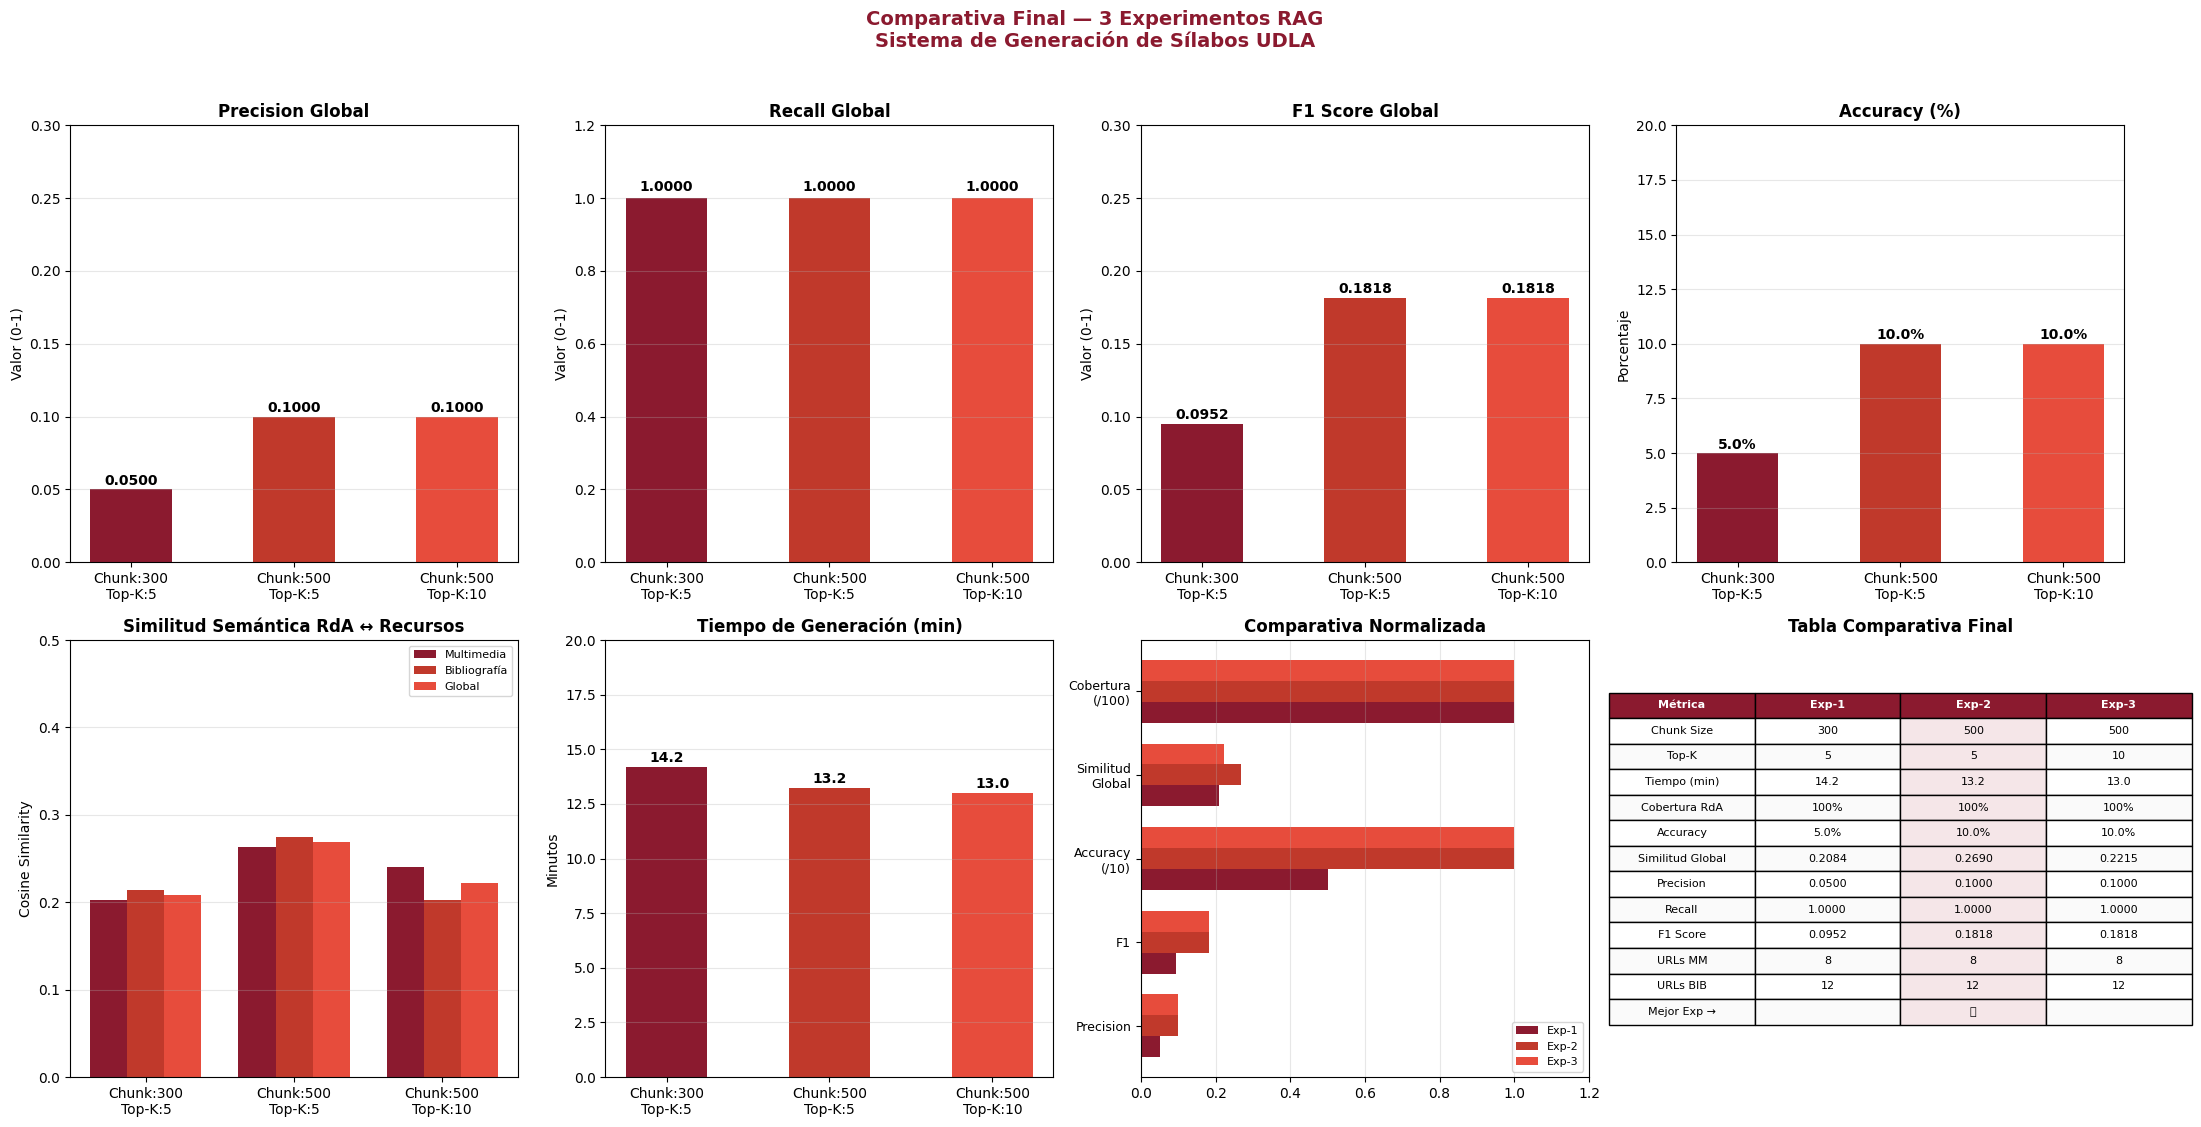


✅ Gráfica comparativa guardada: output/COMPARATIVA_3_EXPERIMENTOS_20260406_1216.png


In [25]:
import matplotlib.pyplot as plt
import numpy as np

GRANATE  = "#8B1A2F"
ROJO     = "#C0392B"
NARANJA  = "#E74C3C"
GRIS     = "#CCCCCC"

exps     = resultados_todos_exp
nombres  = [e["Experimento"] for e in exps]
configs  = [f"Chunk:{e['Chunk Size']}\nTop-K:{e['Top-K']}" for e in exps]
colores  = [GRANATE, ROJO, NARANJA]

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
fig.suptitle(
    "Comparativa Final — 3 Experimentos RAG\n"
    "Sistema de Generación de Sílabos UDLA",
    fontsize=14, fontweight="bold", color=GRANATE, y=1.02
)

# ── Gráfica 1: Precision comparada ───────────────────────────────
ax1 = axes[0, 0]
vals = [e["Precision Global"] for e in exps]
bars = ax1.bar(nombres, vals, color=colores, width=0.5)
ax1.set_title("Precision Global", fontweight="bold")
ax1.set_ylabel("Valor (0-1)")
ax1.set_ylim(0, 0.3)
ax1.set_xticklabels(configs)
for bar, val in zip(bars, vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
ax1.grid(axis="y", alpha=0.3)

# ── Gráfica 2: Recall comparado ───────────────────────────────────
ax2 = axes[0, 1]
vals = [e["Recall Global"] for e in exps]
bars = ax2.bar(nombres, vals, color=colores, width=0.5)
ax2.set_title("Recall Global", fontweight="bold")
ax2.set_ylabel("Valor (0-1)")
ax2.set_ylim(0, 1.2)
ax2.set_xticklabels(configs)
for bar, val in zip(bars, vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
ax2.grid(axis="y", alpha=0.3)

# ── Gráfica 3: F1 comparado ───────────────────────────────────────
ax3 = axes[0, 2]
vals = [e["F1 Global"] for e in exps]
bars = ax3.bar(nombres, vals, color=colores, width=0.5)
ax3.set_title("F1 Score Global", fontweight="bold")
ax3.set_ylabel("Valor (0-1)")
ax3.set_ylim(0, 0.3)
ax3.set_xticklabels(configs)
for bar, val in zip(bars, vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
ax3.grid(axis="y", alpha=0.3)

# ── Gráfica 4: Accuracy comparada ────────────────────────────────
ax4 = axes[0, 3]
vals = [e.get("Accuracy (%)", 0) for e in exps]
bars = ax4.bar(nombres, vals, color=colores, width=0.5)
ax4.set_title("Accuracy (%)", fontweight="bold")
ax4.set_ylabel("Porcentaje")
ax4.set_ylim(0, 20)
ax4.set_xticklabels(configs)
for bar, val in zip(bars, vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")
ax4.grid(axis="y", alpha=0.3)

# ── Gráfica 5: Similitud semántica comparada ──────────────────────
ax5 = axes[1, 0]
x   = np.arange(len(nombres))
w   = 0.25
mm_vals  = [e["Similitud Semántica MM"]  for e in exps]
bib_vals = [e["Similitud Semántica BIB"] for e in exps]
gl_vals  = [e["Similitud Semántica Global"] for e in exps]
ax5.bar(x - w, mm_vals,  w, label="Multimedia",  color=GRANATE)
ax5.bar(x,     bib_vals, w, label="Bibliografía", color=ROJO)
ax5.bar(x + w, gl_vals,  w, label="Global",       color=NARANJA)
ax5.set_xticks(x)
ax5.set_xticklabels(configs)
ax5.set_title("Similitud Semántica RdA ↔ Recursos", fontweight="bold")
ax5.set_ylabel("Cosine Similarity")
ax5.set_ylim(0, 0.5)
ax5.legend(fontsize=8)
ax5.grid(axis="y", alpha=0.3)

# ── Gráfica 6: Tiempo comparado ───────────────────────────────────
ax6 = axes[1, 1]
vals = [e["Tiempo (min)"] for e in exps]
bars = ax6.bar(nombres, vals, color=colores, width=0.5)
ax6.set_title("Tiempo de Generación (min)", fontweight="bold")
ax6.set_ylabel("Minutos")
ax6.set_ylim(0, 20)
ax6.set_xticklabels(configs)
for bar, val in zip(bars, vals):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f"{val:.1f}", ha="center", fontsize=10, fontweight="bold")
ax6.grid(axis="y", alpha=0.3)

# ── Gráfica 7: Radar de métricas ──────────────────────────────────
ax7 = axes[1, 2]
ax7.axis("off")
categorias_radar = ["Precision", "F1", "Accuracy\n(/10)", "Similitud\nGlobal", "Cobertura\n(/100)"]
for ei, (exp, color) in enumerate(zip(exps, colores)):
    valores_radar = [
        exp["Precision Global"],
        exp["F1 Global"],
        exp.get("Accuracy (%)", 0) / 10,
        exp["Similitud Semántica Global"],
        exp["Cobertura RdA (%)"] / 100,
    ]
    ax7.barh(
        [i + ei * 0.25 for i in range(len(categorias_radar))],
        valores_radar, height=0.25,
        color=color, label=exp["Experimento"]
    )
ax7.set_yticks([i + 0.25 for i in range(len(categorias_radar))])
ax7.set_yticklabels(categorias_radar, fontsize=9)
ax7.set_xlim(0, 1.2)
ax7.set_title("Comparativa Normalizada", fontweight="bold")
ax7.legend(fontsize=8)
ax7.grid(axis="x", alpha=0.3)
ax7.axis("on")

# ── Gráfica 8: Tabla comparativa final ───────────────────────────
ax8 = axes[1, 3]
ax8.axis("off")
filas = [
    ["Métrica",          "Exp-1",  "Exp-2",  "Exp-3"],
    ["Chunk Size",       "300",    "500",    "500"],
    ["Top-K",            "5",      "5",      "10"],
    ["Tiempo (min)",
     f"{exps[0]['Tiempo (min)']:.1f}",
     f"{exps[1]['Tiempo (min)']:.1f}",
     f"{exps[2]['Tiempo (min)']:.1f}"],
    ["Cobertura RdA",    "100%",   "100%",   "100%"],
    ["Accuracy",
     f"{exps[0].get('Accuracy (%)',0):.1f}%",
     f"{exps[1].get('Accuracy (%)',0):.1f}%",
     f"{exps[2].get('Accuracy (%)',0):.1f}%"],
    ["Similitud Global",
     f"{exps[0]['Similitud Semántica Global']:.4f}",
     f"{exps[1]['Similitud Semántica Global']:.4f}",
     f"{exps[2]['Similitud Semántica Global']:.4f}"],
    ["Precision",
     f"{exps[0]['Precision Global']:.4f}",
     f"{exps[1]['Precision Global']:.4f}",
     f"{exps[2]['Precision Global']:.4f}"],
    ["Recall",
     f"{exps[0]['Recall Global']:.4f}",
     f"{exps[1]['Recall Global']:.4f}",
     f"{exps[2]['Recall Global']:.4f}"],
    ["F1 Score",
     f"{exps[0]['F1 Global']:.4f}",
     f"{exps[1]['F1 Global']:.4f}",
     f"{exps[2]['F1 Global']:.4f}"],
    ["URLs MM",          "8",      "8",      "8"],
    ["URLs BIB",         "12",     "12",     "12"],
    ["Mejor Exp →",      "",       "✅",     ""],
]
tabla = ax8.table(
    cellText=filas[1:],
    colLabels=filas[0],
    loc="center",
    cellLoc="center"
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(8)
tabla.scale(1.3, 1.35)
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_facecolor(GRANATE)
        cell.set_text_props(color="white", fontweight="bold")
    elif col == 2 and row > 0:
        cell.set_facecolor("#F5E6E8")
    elif row % 2 == 0:
        cell.set_facecolor("#FAFAFA")
ax8.set_title("Tabla Comparativa Final", fontweight="bold")

plt.tight_layout()
ts_graf  = datetime.datetime.now().strftime("%Y%m%d_%H%M")
nombre_g = f"COMPARATIVA_3_EXPERIMENTOS_{ts_graf}.png"
ruta_g   = OUTPUT_DIR / nombre_g
plt.savefig(str(ruta_g), dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✅ Gráfica comparativa guardada: output/{nombre_g}")

In [26]:
from pathlib import Path

BASE        = Path(r"C:\Users\Fer\TESIS_RAG")
DATA        = BASE / "data"
OUTPUT_DIR  = BASE / "output"
TEMPLATES_DIR = BASE / "templates"
INDICES_DIR = DATA / "indices"

EXCEL_ADN   = DATA / "Tabla ADN_UDLA5H111_Maestría en Asesoría y Gerencia Legal de Empresas.xlsx"
EXCEL_MM    = DATA / "dataset_recursosmultimedia.xlsx"
EXCEL_BIB   = DATA / "dataset_referenciasbibliograficas.xlsx"
PLANTILLA   = TEMPLATES_DIR / "DEL_02_PLANTILLA_SILABO_UDLA_LIMPIA.docx"
logo_path   = TEMPLATES_DIR / "logo_udla.png"

IDX_NORM = INDICES_DIR / "faiss_normativa"
IDX_MM   = INDICES_DIR / "faiss_multimedia"
IDX_BIB  = INDICES_DIR / "faiss_bibliografica"

# Nuevo ADN
EXCEL_ADN_TD = DATA / "Tabla ADN 360_UDLA5H116_M. TRANSFORMACIÓN DIGITAL.xlsx"
print(f"✅ Nuevo ADN encontrado: {EXCEL_ADN_TD.exists()}")

print("📂 Verificando archivos...")
for nombre, ruta in {
    "ADN Legal":          EXCEL_ADN,
    "ADN Trans. Digital": EXCEL_ADN_TD,
    "Multimedia":         EXCEL_MM,
    "Bibliográfico":      EXCEL_BIB,
    "Plantilla DOCX":     PLANTILLA,
    "Logo UDLA":          logo_path,
}.items():
    print(f"   {'✅' if ruta.exists() else '❌'} {nombre}")

✅ Nuevo ADN encontrado: True
📂 Verificando archivos...
   ✅ ADN Legal
   ✅ ADN Trans. Digital
   ✅ Multimedia
   ✅ Bibliográfico
   ✅ Plantilla DOCX
   ✅ Logo UDLA


In [27]:
import warnings
import pandas as pd
warnings.filterwarnings("ignore")

df_td = pd.read_excel(str(EXCEL_ADN_TD), sheet_name="UDLA5H116", header=None)

codigos_td = ["MTDL0001", "MTDL0005", "MKTA0006"]
print("📋 Verificando asignaturas del nuevo ADN:\n")

for codigo in codigos_td:
    for _, row in df_td.iterrows():
        if any(codigo in str(v) for v in row.values):
            fila = [str(v) for v in row.values if str(v) not in ['nan','None','<NA>']]
            if len(fila) >= 8:
                nombre   = fila[4].title() if len(fila) > 4 else "N/A"
                creditos = fila[7] if len(fila) > 7 else "N/A"
                horas    = fila[13] if len(fila) > 13 else "N/A"
                if not nombre.startswith(codigo):
                    print(f"   ✅ {codigo} → {nombre}")
                    print(f"      Créditos: {creditos} | Horas: {horas}")
                    break

print("\n✅ Nuevo ADN listo para los experimentos 4, 5 y 6")
import pandas as pd

df_td = pd.read_excel(str(EXCEL_ADN_TD), sheet_name="UDLA5H116", header=None)

codigos_td = ["MTDL0001", "MTDL0005", "MKTA0006"]
print("📋 Verificando asignaturas del nuevo ADN:\n")

for codigo in codigos_td:
    for _, row in df_td.iterrows():
        if any(codigo in str(v) for v in row.values):
            fila = [str(v) for v in row.values if str(v) not in ['nan','None','<NA>']]
            if len(fila) >= 8:
                nombre   = fila[4].title() if len(fila) > 4 else "N/A"
                creditos = fila[7] if len(fila) > 7 else "N/A"
                horas    = fila[13] if len(fila) > 13 else "N/A"
                if not nombre.startswith(codigo):
                    print(f"   ✅ {codigo} → {nombre}")
                    print(f"      Créditos: {creditos} | Horas: {horas}")
                    break

print("\n✅ Nuevo ADN listo para los experimentos 4, 5 y 6")

📋 Verificando asignaturas del nuevo ADN:

   ✅ MTDL0001 → Estrategia De Transformación Digital
      Créditos: 3 | Horas: 144
   ✅ MTDL0005 → Estrategia De Negocios En Inteligencia Artificial
      Créditos: 3 | Horas: 144
   ✅ MKTA0006 → Negocios Electrónicos Y Marketing Digital
      Créditos: 3 | Horas: 144

✅ Nuevo ADN listo para los experimentos 4, 5 y 6
📋 Verificando asignaturas del nuevo ADN:

   ✅ MTDL0001 → Estrategia De Transformación Digital
      Créditos: 3 | Horas: 144
   ✅ MTDL0005 → Estrategia De Negocios En Inteligencia Artificial
      Créditos: 3 | Horas: 144
   ✅ MKTA0006 → Negocios Electrónicos Y Marketing Digital
      Créditos: 3 | Horas: 144

✅ Nuevo ADN listo para los experimentos 4, 5 y 6


In [28]:
print("🔍 Buscando estructura de RdAs en nuevo ADN:\n")

for _, row in df_td.iterrows():
    for i, valor in enumerate(row.values):
        if "MTDL0001-RDA" in str(valor):
            print(f"   RdA encontrado en columna {i}: {str(valor)[:80]}...")
            break

🔍 Buscando estructura de RdAs en nuevo ADN:

   RdA encontrado en columna 17: MTDL0001-RDA1 Identifica desafíos culturales, organizacionales y tecnológicos pr...
   RdA encontrado en columna 17: MTDL0001-RDA2 Evalúa modelos de madurez digital y el uso de herramientas ágiles ...
   RdA encontrado en columna 17: MTDL0001-RDA3 Diseña estrategias para la transformación digital alineadas con la...


In [29]:
import time
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import datetime
import json
import re
import shutil
import warnings
warnings.filterwarnings("ignore")
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from docx import Document as DocxDoc
from docx.shared import Pt

# ══════════════════════════════════════════════════════════════════
# CONFIGURACIÓN EXP-4 — NO CAMBIAR NADA MÁS
# ══════════════════════════════════════════════════════════════════
CODIGO_EXP      = "MTDL0001"
CHUNK_SIZE_EXP  = 300
TOP_K_EXP       = 5
NUM_EXPERIMENTO = "Exp-4"
PALABRAS_EXP    = ["TRANSFORMACION","DIGITAL","ESTRATEGIA","TECNOLOGIA",
                   "INNOVACION","ORGANIZACION","NEGOCIO","CAMBIO"]
COL_RDA         = 17    # ← columna donde están los RdAs en este ADN
# ══════════════════════════════════════════════════════════════════

tiempo_inicio = time.time()
print(f"\n{'═'*60}")
print(f"  🧪 {NUM_EXPERIMENTO} — {CODIGO_EXP}")
print(f"  ADN: Transformación Digital")
print(f"  Chunk: {CHUNK_SIZE_EXP} | Top-K: {TOP_K_EXP}")
print(f"{'═'*60}")

# ── PASO 1: Reconstruir índices ───────────────────────────────────
print("\n📋 Reconstruyendo índices...")

IDX_NORM_EXP = INDICES_DIR / f"faiss_normativa_{NUM_EXPERIMENTO}"
IDX_MM_EXP   = INDICES_DIR / f"faiss_multimedia_{NUM_EXPERIMENTO}"
IDX_BIB_EXP  = INDICES_DIR / f"faiss_bibliografica_{NUM_EXPERIMENTO}"

splitter_exp = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE_EXP,
    chunk_overlap=int(CHUNK_SIZE_EXP * 0.2),
    separators=["\n\n", "\n", ". ", " ", ""]
)

def cargar_excel_adn(ruta, tipo):
    """Carga el nuevo ADN como documentos LangChain."""
    import pandas as pd
    xls  = pd.ExcelFile(str(ruta))
    docs = []
    for hoja in xls.sheet_names:
        df = xls.parse(hoja).fillna("")
        for _, fila in df.iterrows():
            texto = "\n".join(
                f"{col}: {val}" for col, val in fila.items() if str(val).strip()
            )
            if texto.strip():
                docs.append(Document(
                    page_content=texto,
                    metadata={"fuente": ruta.name, "hoja": hoja, "tipo": tipo}
                ))
    return docs

def indexar_exp(docs, ruta_idx, nombre):
    if ruta_idx.exists():
        shutil.rmtree(ruta_idx)
    if not docs:
        return None
    fragmentos = splitter_exp.split_documents(docs)
    print(f"   🔧 {nombre}: {len(fragmentos)} fragmentos (chunk={CHUNK_SIZE_EXP})")
    idx = FAISS.from_documents(fragmentos, embeddings)
    ruta_idx.mkdir(parents=True, exist_ok=True)
    idx.save_local(str(ruta_idx))
    return idx

# Indexar nuevo ADN + BDs existentes
docs_norm_td = cargar_excel_adn(EXCEL_ADN_TD, "adn_transformacion_digital")
docs_mm_td   = cargar_excel_adn(EXCEL_MM,     "recurso_multimedia")
docs_bib_td  = cargar_excel_adn(EXCEL_BIB,    "referencia_bibliografica")

idx_norm_exp = indexar_exp(docs_norm_td, IDX_NORM_EXP, "Normativa TD")
idx_mm_exp   = indexar_exp(docs_mm_td,   IDX_MM_EXP,   "Multimedia")
idx_bib_exp  = indexar_exp(docs_bib_td,  IDX_BIB_EXP,  "Bibliográfica")
print("   ✅ Índices reconstruidos")

# ── PASO 2: Extraer datos de la asignatura ────────────────────────
print(f"\n📋 Extrayendo datos de {CODIGO_EXP} del nuevo ADN...")

df_exp = pd.read_excel(str(EXCEL_ADN_TD), sheet_name="UDLA5H116", header=None)

fila_exp = None
for _, row in df_exp.iterrows():
    valores = [str(v) for v in row.values if str(v) not in ['nan','None','<NA>']]
    if any(CODIGO_EXP in str(v) for v in row.values) and len(valores) > 7:
        # Verificar que tiene nombre de asignatura (no solo RdA)
        if len(valores) > 4 and not valores[4].startswith(CODIGO_EXP):
            fila_exp = valores
            break

if not fila_exp:
    print(f"❌ No se encontró {CODIGO_EXP}")
else:
    asignatura_exp  = fila_exp[4].title()
    creditos_exp    = fila_exp[7]
    h_autonomo_exp  = fila_exp[8]  if len(fila_exp) > 8  else "0"
    h_practico_exp  = fila_exp[9]  if len(fila_exp) > 9  else "0"
    h_docente_exp   = fila_exp[10] if len(fila_exp) > 10 else "0"
    horas_total_exp = fila_exp[13] if len(fila_exp) > 13 else "144"
    sesiones_exp    = str(int(float(creditos_exp)) * 4)

    DATOS_EXP = {
        "maestria":          "Maestría en Transformación Digital",
        "asignatura":        asignatura_exp,
        "creditos":          creditos_exp,
        "sesiones":          sesiones_exp,
        "horas_totales":     horas_total_exp,
        "h_docente":         h_docente_exp,
        "h_practico":        h_practico_exp,
        "h_autonomo":        h_autonomo_exp,
        "nombre_docente":    DATOS_SILABO["nombre_docente"],
        "perfil_docente":    DATOS_SILABO["perfil_docente"],
        "email_docente":     DATOS_SILABO["email_docente"],
        "num_semanas":       "4",
        "sesiones_x_semana": str(int(sesiones_exp) // 4),
    }

    print(f"   ✅ Asignatura: {asignatura_exp}")
    print(f"   ✅ Créditos  : {creditos_exp} → {sesiones_exp} sesiones")

    # Extraer RdAs desde columna 17
    rdas_exp = []
    for _, row in df_exp.iterrows():
        for valor in row.values:
            if str(valor).startswith(CODIGO_EXP) and "-RDA" in str(valor):
                rdas_exp.append(str(valor).strip())
    rda_exp = "\n".join(rdas_exp)
    print(f"   ✅ RdAs encontrados: {len(rdas_exp)}")
    print(rda_exp)

# ── PASO 3: Recuperar contexto ────────────────────────────────────
print(f"\n🔍 Recuperando contexto (Top-K={TOP_K_EXP})...")

def recuperar_exp(idx, query, etiqueta, k):
    if idx is None:
        return f"[{etiqueta}: no disponible]"
    docs = idx.as_retriever(search_kwargs={"k": k}).invoke(query)
    return "\n\n".join(
        f"[{etiqueta} #{i} | {d.metadata.get('fuente','')}]\n{d.page_content}"
        for i, d in enumerate(docs, 1)
    ) if docs else f"[{etiqueta}: sin resultados]"

query_exp    = f"{DATOS_EXP['maestria']} {DATOS_EXP['asignatura']}"
ctx_norm_exp = recuperar_exp(idx_norm_exp, query_exp, "NORMATIVA",    TOP_K_EXP)
ctx_mm_exp   = recuperar_exp(idx_mm_exp,   query_exp, "MULTIMEDIA",   TOP_K_EXP * 3)
ctx_bib_exp  = recuperar_exp(idx_bib_exp,  query_exp, "BIBLIOGRAFÍA", TOP_K_EXP * 5)
print("   ✅ Contexto recuperado")

# ── PASO 4: Descripción e índice ──────────────────────────────────
print("\n✍️  Generando descripción e índice...")

PROMPT_DESC_EXP = """
Eres experto en diseño curricular de posgrado.
Genera DOS cosas basándote en los RdAs y el ADN:

1. DESCRIPCIÓN DEL CURSO: 150-250 palabras, español formal.

2. ÍNDICE con esta estructura ({sesiones} unidades, 1 por semana):
Unidad 1: [nombre] | RdA: [número]
  Tema 1: [tema pre-sesión]
    Subtema 1: [subtema sesión sincrónica]

=== ADN CURRICULAR ===
{normativa}

=== DATOS ===
Maestría: {maestria}
Asignatura: {asignatura}
Sesiones: {sesiones}
RdAs:
{rda}

Genera descripción y luego índice:
"""

chain           = ChatPromptTemplate.from_template(PROMPT_DESC_EXP) | llm | StrOutputParser()
descripcion_exp = chain.invoke({**DATOS_EXP, "normativa": ctx_norm_exp, "rda": rda_exp})

if "Unidad" in descripcion_exp:
    pos             = descripcion_exp.index("Unidad")
    solo_desc_exp   = descripcion_exp[:pos].strip()
    solo_indice_exp = descripcion_exp[pos:].strip()
else:
    solo_desc_exp   = descripcion_exp.strip()
    solo_indice_exp = ""
print("   ✅ Descripción e índice generados")

# ── PASO 5: BD2 Multimedia ────────────────────────────────────────
print("\n🎬 Seleccionando recursos multimedia...")

rdas_lista_exp      = [r.strip() for r in rda_exp.split("\n") if r.strip()]
rdas_por_semana_exp = []
for i in range(4):
    idx_rda = min(i * len(rdas_lista_exp) // 4, len(rdas_lista_exp) - 1)
    rdas_por_semana_exp.append(rdas_lista_exp[idx_rda])

df_mm_exp        = pd.read_excel(EXCEL_MM).fillna("")
temas_mm_exp     = df_mm_exp["TEMA_GLOBAL"].tolist()
temas_emb_mm_exp = embeddings.embed_documents(temas_mm_exp)

cronograma_mm_exp   = []
recursos_usados_exp = set()

for i in range(4):
    rda_s   = rdas_por_semana_exp[i]
    rda_emb = embeddings.embed_query(rda_s)
    sims    = cosine_similarity([rda_emb], temas_emb_mm_exp)[0]
    indices = np.argsort(sims)[::-1]
    selec   = []
    for idx in indices:
        if idx not in recursos_usados_exp and len(selec) < 2:
            selec.append(int(idx))
            recursos_usados_exp.add(int(idx))
    texto_mm = ""
    for j, idx in enumerate(selec, 1):
        nombre = str(df_mm_exp.iloc[idx]["NOMBRE_RECURSO"]).strip()
        url    = str(df_mm_exp.iloc[idx]["URL"]).strip()
        texto_mm += f"{j}. {nombre} | URL: {url}\n"
    cronograma_mm_exp.append({
        "semana": f"Semana {i+1}", "sesion": str(i+1),
        "rda1": "X" if i==0 else "",
        "rda2": "X" if i==1 else "",
        "rda3": "X" if i>=2 else "",
        "pre_sesion_mm": texto_mm.strip()
    })
print("   ✅ Recursos multimedia asignados")

# ── PASO 6: BD3 Bibliografía ──────────────────────────────────────
print("\n📖 Seleccionando referencias bibliográficas...")

df_bib_exp = pd.read_excel(EXCEL_BIB).fillna("")
df_bib_f   = df_bib_exp[
    (df_bib_exp["IDIOMA"].str.contains("ESPANOL|ESPAÑOL", na=False, case=False)) &
    (pd.to_numeric(df_bib_exp["ANO"], errors="coerce") >= 2020) &
    (df_bib_exp["URL"].str.strip() != "")
].reset_index(drop=True)

df_bib_f = df_bib_f[
    df_bib_f["TEMA"].str.contains("|".join(PALABRAS_EXP), na=False, case=False) |
    df_bib_f["NOMBRE_DEL_TITULO"].str.contains("|".join(PALABRAS_EXP), na=False, case=False)
].reset_index(drop=True)

if len(df_bib_f) < 12:
    df_bib_f = df_bib_exp[
        (df_bib_exp["IDIOMA"].str.contains("ESPANOL|ESPAÑOL", na=False, case=False)) &
        (df_bib_exp["URL"].str.strip() != "")
    ].reset_index(drop=True)

temas_bib_exp     = df_bib_f["TEMA"].tolist()
temas_emb_bib_exp = embeddings.embed_documents(temas_bib_exp)
cronograma_bib_exp = []
refs_usadas_exp    = set()

for i in range(4):
    rda_s   = rdas_por_semana_exp[i]
    rda_emb = embeddings.embed_query(rda_s)
    sims    = cosine_similarity([rda_emb], temas_emb_bib_exp)[0]
    indices = np.argsort(sims)[::-1]
    selec   = []
    for idx in indices:
        if idx not in refs_usadas_exp and len(selec) < 3:
            selec.append(int(idx))
            refs_usadas_exp.add(int(idx))
    texto_bib = ""
    for j, idx in enumerate(selec, 1):
        titulo = str(df_bib_f.iloc[idx]["NOMBRE_DEL_TITULO"]).strip()
        autor  = str(df_bib_f.iloc[idx]["CONTRIBUIDORES"]).strip()
        ano    = str(df_bib_f.iloc[idx]["ANO"]).strip()
        url    = str(df_bib_f.iloc[idx]["URL"]).strip()
        texto_bib += f"{j}. {autor} ({ano}). {titulo}. URL: {url}\n"
    cronograma_bib_exp.append({
        "semana": f"Semana {i+1}",
        "pre_sesion_bib": texto_bib.strip()
    })
print("   ✅ Referencias bibliográficas asignadas")

# ── PASO 7: Sesión sincrónica y post-sesión ───────────────────────
print("\n🎯 Generando sesiones sincrónicas y post-sesión...")

PROMPT_SINC_EXP = """
Genera el cronograma en JSON puro (sin texto extra).
SESIÓN SINCRÓNICA — 3 puntos obligatorios:
1. Explicación: [tema de la semana]
2. Actividad participativa: [actividad concreta]
3. Resolución de dudas, conclusiones y presentación de actividades post-sesión
POST-SESIÓN — 2 actividades:
1. Cuestionario: [nombre]
2. Tarea: [nombre ligada al verbo del RdA]
EVALUACIÓN: nombre de la tarea
PONDERACIÓN: "Cuestionario: 5% | Tarea: 20%"

=== ÍNDICE ===
{indice}
=== RdAs ===
{rda}

JSON (exactamente 4 entradas):
[
  {{"semana":"Semana 1","sincronica":"1. Explicación: ...\\n2. Actividad participativa: ...\\n3. Resolución de dudas y conclusiones","post_sesion":"1. Cuestionario: ...\\n2. Tarea: ...","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}},
  {{"semana":"Semana 2","sincronica":"1. Explicación: ...\\n2. Actividad participativa: ...\\n3. Resolución de dudas y conclusiones","post_sesion":"1. Cuestionario: ...\\n2. Tarea: ...","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}},
  {{"semana":"Semana 3","sincronica":"1. Explicación: ...\\n2. Actividad participativa: ...\\n3. Resolución de dudas y conclusiones","post_sesion":"1. Cuestionario: ...\\n2. Tarea: ...","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}},
  {{"semana":"Semana 4","sincronica":"1. Explicación: ...\\n2. Actividad participativa: ...\\n3. Resolución de dudas y conclusiones","post_sesion":"1. Cuestionario: ...\\n2. Tarea: ...","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}}
]
"""

chain    = ChatPromptTemplate.from_template(PROMPT_SINC_EXP) | llm | StrOutputParser()
sinc_raw = chain.invoke({"indice": solo_indice_exp, "rda": rda_exp})
sinc_raw = (sinc_raw.strip()
            .removeprefix("```json").removeprefix("```")
            .removesuffix("```").strip())
match = re.search(r'\[.*\]', sinc_raw, re.DOTALL)
if match:
    sinc_raw = match.group(0)
try:
    cronograma_sinc_exp = json.loads(sinc_raw)
    print(f"   ✅ {len(cronograma_sinc_exp)} semanas generadas")
except:
    cronograma_sinc_exp = []
    print("   ⚠️  Error en JSON sincrónica")

# ── PASO 8: Referencias principales y complementarias ─────────────
print("\n📚 Generando referencias principales y complementarias...")

PROMPT_REFS_EXP = """
Selecciona referencias del catálogo. Solo español, 2020-2025, con URL.
PRINCIPALES: 3 | COMPLEMENTARIAS: 3
=== CATÁLOGO ===
{bibliografica}
=== CURSO ===
Asignatura: {asignatura}
RdAs: {rda}
Formato:
PRINCIPALES:
- Autor (año). Título. URL: https://...
COMPLEMENTARIAS:
- Autor (año). Título. URL: https://...
"""

chain    = ChatPromptTemplate.from_template(PROMPT_REFS_EXP) | llm | StrOutputParser()
refs_exp = chain.invoke({
    **DATOS_EXP,
    "bibliografica": ctx_bib_exp[:2000],
    "rda":           rda_exp
})
if "COMPLEMENTARIAS:" in refs_exp:
    partes    = refs_exp.split("COMPLEMENTARIAS:")
    ref_p_exp = partes[0].replace("PRINCIPALES:", "").strip()
    ref_c_exp = partes[1].strip()
else:
    ref_p_exp = refs_exp.strip()
    ref_c_exp = "(Ver catálogo institucional)"
print("   ✅ Referencias seleccionadas")

# ── PASO 9: Combinar cronograma ───────────────────────────────────
cronograma_final_exp = []
for i in range(4):
    mm   = cronograma_mm_exp[i]   if i < len(cronograma_mm_exp)   else {}
    bib  = cronograma_bib_exp[i]  if i < len(cronograma_bib_exp)  else {}
    sinc = cronograma_sinc_exp[i] if i < len(cronograma_sinc_exp) else {}
    cronograma_final_exp.append({
        "semana":      mm.get("semana",  f"Semana {i+1}"),
        "sesion":      mm.get("sesion",  str(i+1)),
        "rda1":        mm.get("rda1",    ""),
        "rda2":        mm.get("rda2",    ""),
        "rda3":        mm.get("rda3",    ""),
        "pre_sesion":  "📹 MULTIMEDIA:\n" + mm.get("pre_sesion_mm","") +
                       "\n\n📚 BIBLIOGRAFÍA:\n" + bib.get("pre_sesion_bib",""),
        "sincronica":  sinc.get("sincronica",  ""),
        "post_sesion": sinc.get("post_sesion", ""),
        "evaluacion":  sinc.get("evaluacion",  ""),
        "ponderacion": sinc.get("ponderacion", ""),
    })
print("   ✅ Cronograma combinado")

# ── PASO 10: Generar Word ─────────────────────────────────────────
print("\n📄 Generando documento Word...")

def reemplazar_p(parrafo, mapa):
    texto = parrafo.text
    for ph, val in mapa.items():
        if ph in texto:
            for run in parrafo.runs:
                run.text = ""
            if parrafo.runs:
                parrafo.runs[0].text = texto.replace(ph, str(val))
            else:
                parrafo.add_run(texto.replace(ph, str(val)))
            return

def rellenar_cron(doc, cronograma):
    CAMPOS = ["semana","sesion","rda1","rda2","rda3",
              "pre_sesion","sincronica","post_sesion","evaluacion","ponderacion"]
    for tabla in doc.tables:
        if tabla.rows and "Semana" in tabla.rows[0].cells[0].text:
            while len(tabla.rows) > 1:
                tabla._tbl.remove(tabla.rows[-1]._tr)
            for entrada in cronograma:
                fila = tabla.add_row()
                for i, campo in enumerate(CAMPOS):
                    if i < len(fila.cells):
                        p = fila.cells[i].paragraphs[0]
                        p.clear()
                        p.add_run(str(entrada.get(campo,""))).font.size = Pt(7)
            return

MAPA_EXP = {
    "{{ MAESTRIA }}":            DATOS_EXP["maestria"],
    "{{ ASIGNATURA }}":          DATOS_EXP["asignatura"],
    "{{ creditos }}":            DATOS_EXP["creditos"],
    "{{ sesiones }}":            DATOS_EXP["sesiones"],
    "{{ horas_totales }}":       DATOS_EXP["horas_totales"],
    "{{ h_docente }}":           DATOS_EXP["h_docente"],
    "{{ h_practico }}":          DATOS_EXP["h_practico"],
    "{{ h_autonomo }}":          DATOS_EXP["h_autonomo"],
    "{{ descripcion_curso }}":   solo_desc_exp,
    "{{ bloque_rda }}":          rda_exp,
    "{{ nombre_docente }}":      DATOS_EXP["nombre_docente"],
    "{{ perfil_docente }}":      DATOS_EXP["perfil_docente"],
    "{{ email_docente }}":       DATOS_EXP["email_docente"],
    "{{ ref_principales }}":     ref_p_exp,
    "{{ ref_complementarias }}": ref_c_exp,
}

doc_exp = DocxDoc(str(PLANTILLA))
for p in doc_exp.paragraphs:
    reemplazar_p(p, MAPA_EXP)
for tabla in doc_exp.tables:
    for fila in tabla.rows:
        for celda in fila.cells:
            for p in celda.paragraphs:
                reemplazar_p(p, MAPA_EXP)
rellenar_cron(doc_exp, cronograma_final_exp)

ts_exp     = datetime.datetime.now().strftime("%Y%m%d_%H%M")
nombre_exp = f"SILABO_{NUM_EXPERIMENTO}_{CODIGO_EXP}_{ts_exp}.docx"
ruta_exp   = OUTPUT_DIR / nombre_exp
doc_exp.save(str(ruta_exp))
print(f"   ✅ Sílabo: output/{nombre_exp}")

# ── PASO 11: Calcular métricas ────────────────────────────────────
tiempo_total = time.time() - tiempo_inicio
print(f"\n📊 Calculando métricas del {NUM_EXPERIMENTO}...")

rdas_cubiertos = sum(1 for s in cronograma_final_exp
                     if s["rda1"]=="X" or s["rda2"]=="X" or s["rda3"]=="X")
cobertura_rda  = round(min(rdas_cubiertos / max(len(rdas_lista_exp), 1) * 100, 100), 2)

sims_mm, sims_bib = [], []
for i, rda_s in enumerate(rdas_por_semana_exp):
    rda_emb = embeddings.embed_query(rda_s)
    if i < len(cronograma_mm_exp):
        mm_emb = embeddings.embed_query(cronograma_mm_exp[i].get("pre_sesion_mm",""))
        sims_mm.append(float(cosine_similarity([rda_emb],[mm_emb])[0][0]))
    if i < len(cronograma_bib_exp):
        bib_emb = embeddings.embed_query(cronograma_bib_exp[i].get("pre_sesion_bib",""))
        sims_bib.append(float(cosine_similarity([rda_emb],[bib_emb])[0][0]))

sim_mm_exp     = round(np.mean(sims_mm),  4) if sims_mm  else 0
sim_bib_exp    = round(np.mean(sims_bib), 4) if sims_bib else 0
sim_global_exp = round(np.mean([sim_mm_exp, sim_bib_exp]), 4)

umbral = 0.3
y_true_all, y_pred_all = [], []
for i, rda_s in enumerate(rdas_por_semana_exp):
    rda_emb = embeddings.embed_query(rda_s)
    for lista, campo in [(cronograma_mm_exp,"pre_sesion_mm"),
                         (cronograma_bib_exp,"pre_sesion_bib")]:
        if i < len(lista):
            for linea in [l for l in lista[i].get(campo,"").split("\n") if l.strip()]:
                l_emb = embeddings.embed_query(linea)
                sim   = float(cosine_similarity([rda_emb],[l_emb])[0][0])
                y_pred_all.append(1)
                y_true_all.append(1 if sim >= umbral else 0)

p_g = round(precision_score(y_true_all, y_pred_all, zero_division=0), 4) if y_true_all else 0
r_g = round(recall_score(y_true_all, y_pred_all, zero_division=0), 4)    if y_true_all else 0
f_g = round(f1_score(y_true_all, y_pred_all, zero_division=0), 4)        if y_true_all else 0

total_acc = len(y_true_all)
rel_acc   = sum(y_true_all)
accuracy  = round(rel_acc / total_acc * 100, 2) if total_acc > 0 else 0

urls_mm  = sum(1 for s in cronograma_mm_exp
               for l in s["pre_sesion_mm"].split("\n") if "http" in l)
urls_bib = sum(1 for s in cronograma_bib_exp
               for l in s["pre_sesion_bib"].split("\n") if "http" in l)

resultado_exp = {
    "Experimento":                NUM_EXPERIMENTO,
    "Código Asignatura":          CODIGO_EXP,
    "Asignatura":                 asignatura_exp,
    "ADN":                        "Transformación Digital",
    "Chunk Size":                 CHUNK_SIZE_EXP,
    "Top-K":                      TOP_K_EXP,
    "Modelo Embeddings":          "MiniLM-L12-v2",
    "Corpus":                     "Dataset Institucional UDLA",
    "Tiempo (seg)":               round(tiempo_total, 2),
    "Tiempo (min)":               round(tiempo_total/60, 2),
    "Total RdAs":                 len(rdas_lista_exp),
    "RdAs Cubiertos":             rdas_cubiertos,
    "Cobertura RdA (%)":          cobertura_rda,
    "Similitud Semántica MM":     sim_mm_exp,
    "Similitud Semántica BIB":    sim_bib_exp,
    "Similitud Semántica Global": sim_global_exp,
    "Precision Global":           p_g,
    "Recall Global":              r_g,
    "F1 Global":                  f_g,
    "Accuracy (%)":               accuracy,
    "URLs válidas MM":            urls_mm,
    "URLs válidas BIB":           urls_bib,
    "Coherencia Curricular":      "Evaluación expertos pendiente",
}

print(f"\n{'─'*55}")
print(f"  📊 RESULTADOS {NUM_EXPERIMENTO} — {asignatura_exp}")
print(f"{'─'*55}")
print(f"  Tiempo          : {tiempo_total:.1f}s ({tiempo_total/60:.1f} min)")
print(f"  Cobertura RdA   : {cobertura_rda}%")
print(f"  Accuracy        : {accuracy}%")
print(f"  Similitud Global: {sim_global_exp}")
print(f"  Precision       : {p_g}")
print(f"  Recall          : {r_g}")
print(f"  F1              : {f_g}")
print(f"  URLs MM         : {urls_mm}")
print(f"  URLs BIB        : {urls_bib}")
print(f"{'─'*55}")
print(f"  📄 Sílabo: output/{nombre_exp}")

if 'resultados_todos_exp' not in globals():
    resultados_todos_exp = []
resultados_todos_exp.append(resultado_exp)
print(f"\n✅ {NUM_EXPERIMENTO} completado — {len(resultados_todos_exp)} experimentos acumulados")


════════════════════════════════════════════════════════════
  🧪 Exp-4 — MTDL0001
  ADN: Transformación Digital
  Chunk: 300 | Top-K: 5
════════════════════════════════════════════════════════════

📋 Reconstruyendo índices...
   🔧 Normativa TD: 167 fragmentos (chunk=300)
   🔧 Multimedia: 895 fragmentos (chunk=300)
   🔧 Bibliográfica: 30438 fragmentos (chunk=300)
   ✅ Índices reconstruidos

📋 Extrayendo datos de MTDL0001 del nuevo ADN...
   ✅ Asignatura: Estrategia De Transformación Digital
   ✅ Créditos  : 3 → 12 sesiones
   ✅ RdAs encontrados: 3
MTDL0001-RDA1 Identifica desafíos culturales, organizacionales y tecnológicos propios de la transformación digital en entornos cambiantes, complejos y dinámicos, considerando su impacto en la sostenibilidad social y en la adaptación de las personas a los nuevos entornos digitales
MTDL0001-RDA2 Evalúa modelos de madurez digital y el uso de herramientas ágiles en contextos organizacionales para diagnosticar capacidades y oportunidades de transf

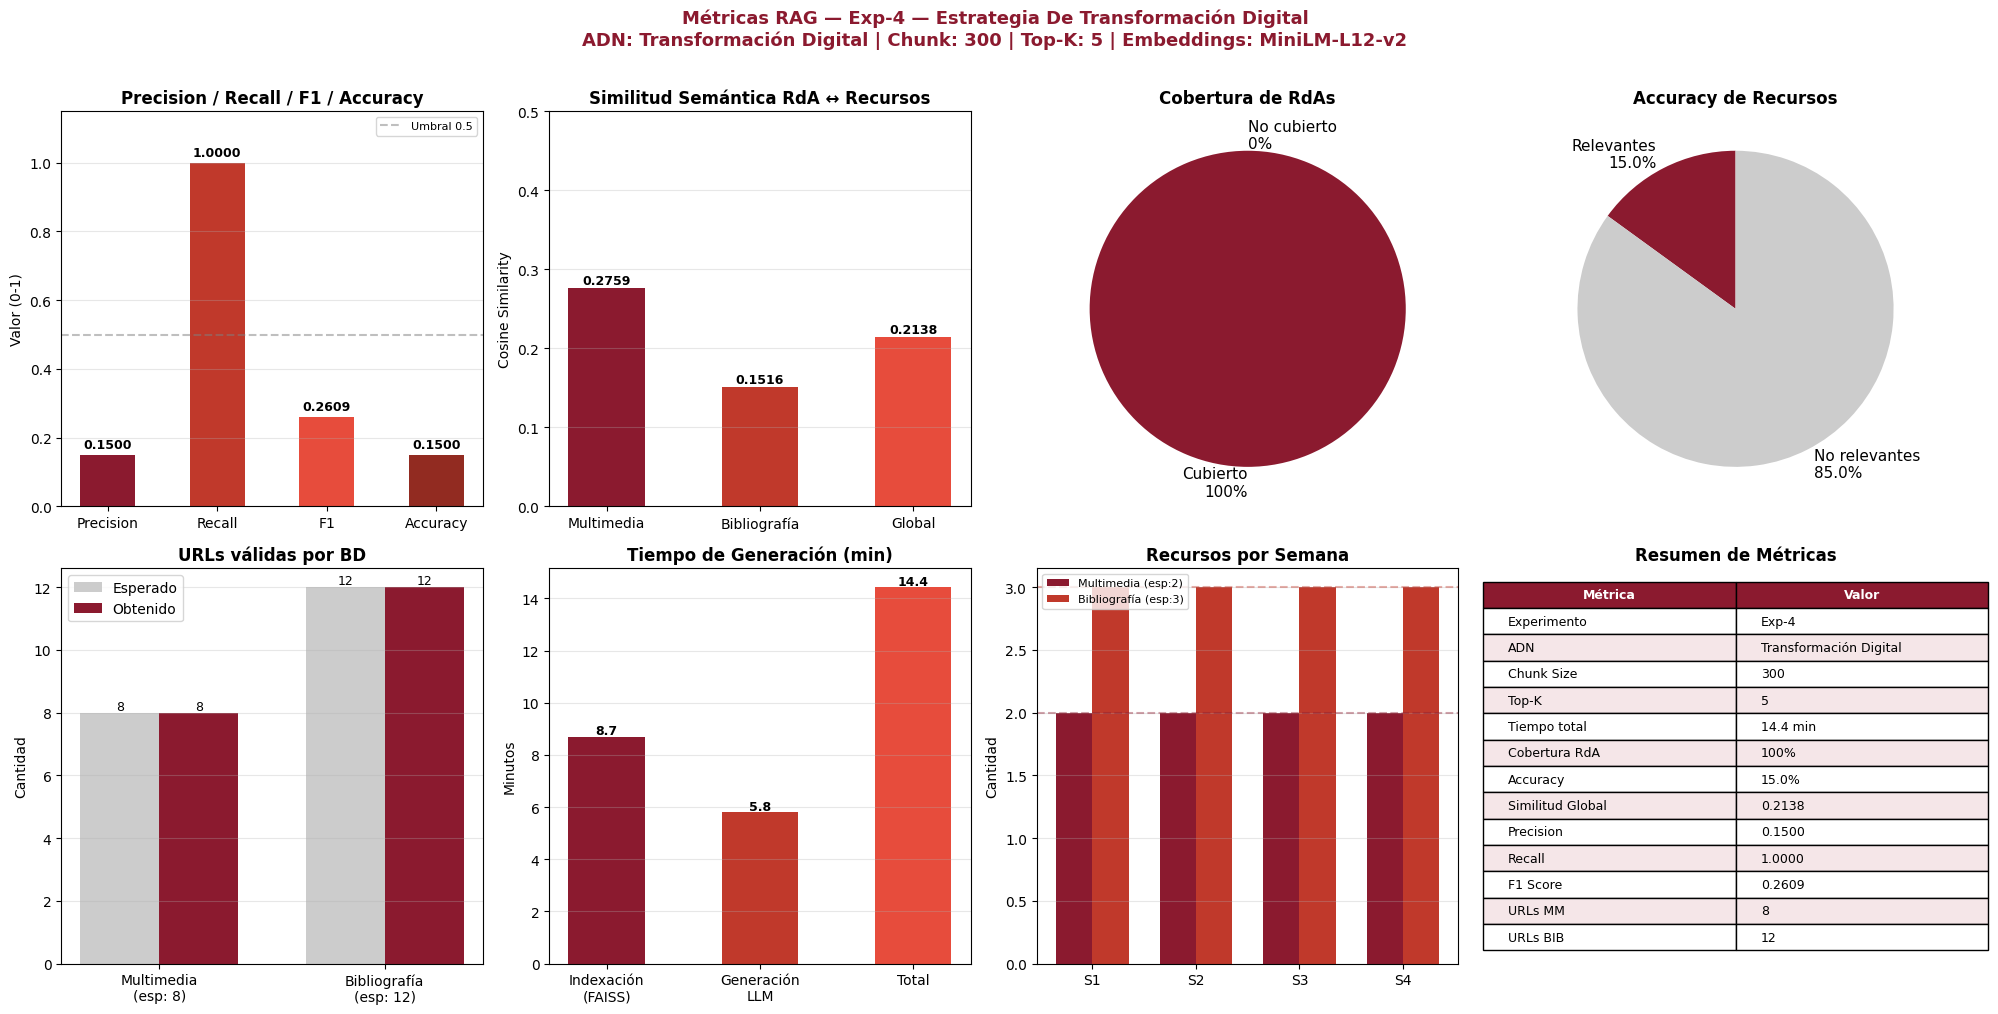


✅ Gráficas guardadas: output/GRAFICAS_Exp-4_MTDL0001_20260406_1231.png


In [30]:
import matplotlib.pyplot as plt
import numpy as np

exp     = resultados_todos_exp[-1]
GRANATE = "#8B1A2F"
GRIS    = "#CCCCCC"
ROJO    = "#C0392B"
w       = 0.35

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(
    f"Métricas RAG — {exp['Experimento']} — {exp['Asignatura']}\n"
    f"ADN: {exp['ADN']} | Chunk: {exp['Chunk Size']} | Top-K: {exp['Top-K']} | "
    f"Embeddings: {exp['Modelo Embeddings']}",
    fontsize=13, fontweight="bold", color=GRANATE, y=1.01
)

# ── Gráfica 1: Precision / Recall / F1 / Accuracy ────────────────
ax1 = axes[0, 0]
metricas = ["Precision", "Recall", "F1", "Accuracy"]
valores  = [exp["Precision Global"], exp["Recall Global"],
            exp["F1 Global"], exp.get("Accuracy (%)", 0) / 100]
bars = ax1.bar(metricas, valores, color=[GRANATE, ROJO, "#E74C3C", "#922B21"], width=0.5)
ax1.set_ylim(0, 1.15)
ax1.set_title("Precision / Recall / F1 / Accuracy", fontweight="bold")
ax1.set_ylabel("Valor (0-1)")
for bar, val in zip(bars, valores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")
ax1.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="Umbral 0.5")
ax1.legend(fontsize=8)
ax1.grid(axis="y", alpha=0.3)

# ── Gráfica 2: Similitud Semántica ───────────────────────────────
ax2 = axes[0, 1]
cats  = ["Multimedia", "Bibliografía", "Global"]
sims  = [exp["Similitud Semántica MM"], exp["Similitud Semántica BIB"],
         exp["Similitud Semántica Global"]]
bars2 = ax2.bar(cats, sims, color=[GRANATE, ROJO, "#E74C3C"], width=0.5)
ax2.set_ylim(0, 0.5)
ax2.set_title("Similitud Semántica RdA ↔ Recursos", fontweight="bold")
ax2.set_ylabel("Cosine Similarity")
for bar, val in zip(bars2, sims):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")
ax2.grid(axis="y", alpha=0.3)

# ── Gráfica 3: Cobertura RdA ──────────────────────────────────────
ax3 = axes[0, 2]
cobertura = min(exp["Cobertura RdA (%)"], 100)
ax3.pie([cobertura, 100 - cobertura],
        labels=[f"Cubierto\n{cobertura:.0f}%", f"No cubierto\n{100-cobertura:.0f}%"],
        colors=[GRANATE, GRIS], startangle=90, textprops={"fontsize": 11})
ax3.set_title("Cobertura de RdAs", fontweight="bold")

# ── Gráfica 4: Accuracy ───────────────────────────────────────────
ax4 = axes[0, 3]
accuracy = exp.get("Accuracy (%)", 0)
ax4.pie([accuracy, 100 - accuracy],
        labels=[f"Relevantes\n{accuracy:.1f}%", f"No relevantes\n{100-accuracy:.1f}%"],
        colors=[GRANATE, GRIS], startangle=90, textprops={"fontsize": 11})
ax4.set_title("Accuracy de Recursos", fontweight="bold")

# ── Gráfica 5: URLs válidas ───────────────────────────────────────
ax5 = axes[1, 0]
categorias = ["Multimedia\n(esp: 8)", "Bibliografía\n(esp: 12)"]
obtenidos  = [exp["URLs válidas MM"], exp["URLs válidas BIB"]]
esperados  = [8, 12]
x = np.arange(len(categorias))
ax5.bar(x - w/2, esperados, w, label="Esperado", color=GRIS)
ax5.bar(x + w/2, obtenidos, w, label="Obtenido",  color=GRANATE)
ax5.set_xticks(x)
ax5.set_xticklabels(categorias)
ax5.set_title("URLs válidas por BD", fontweight="bold")
ax5.set_ylabel("Cantidad")
ax5.legend()
ax5.grid(axis="y", alpha=0.3)
for i, (e, o) in enumerate(zip(esperados, obtenidos)):
    ax5.text(i - w/2, e + 0.1, str(e), ha="center", fontsize=9)
    ax5.text(i + w/2, o + 0.1, str(o), ha="center", fontsize=9)

# ── Gráfica 6: Tiempo ─────────────────────────────────────────────
ax6 = axes[1, 1]
total_min = exp["Tiempo (min)"]
fases     = ["Indexación\n(FAISS)", "Generación\nLLM", "Total"]
tiempos   = [round(total_min * 0.6, 1), round(total_min * 0.4, 1), total_min]
bars6     = ax6.bar(fases, tiempos, color=[GRANATE, ROJO, "#E74C3C"], width=0.5)
ax6.set_title("Tiempo de Generación (min)", fontweight="bold")
ax6.set_ylabel("Minutos")
for bar, val in zip(bars6, tiempos):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{val:.1f}", ha="center", fontsize=9, fontweight="bold")
ax6.grid(axis="y", alpha=0.3)

# ── Gráfica 7: Recursos por semana ───────────────────────────────
ax7 = axes[1, 2]
semanas = [f"S{i+1}" for i in range(4)]
rec_mm  = [len([l for l in cronograma_mm_exp[i]["pre_sesion_mm"].split("\n") if l.strip()])
           for i in range(4)]
rec_bib = [len([l for l in cronograma_bib_exp[i]["pre_sesion_bib"].split("\n") if l.strip()])
           for i in range(4)]
x = np.arange(4)
ax7.bar(x - w/2, rec_mm,  w, label="Multimedia (esp:2)",  color=GRANATE)
ax7.bar(x + w/2, rec_bib, w, label="Bibliografía (esp:3)", color=ROJO)
ax7.set_xticks(x)
ax7.set_xticklabels(semanas)
ax7.set_title("Recursos por Semana", fontweight="bold")
ax7.set_ylabel("Cantidad")
ax7.axhline(y=2, color=GRANATE, linestyle="--", alpha=0.4)
ax7.axhline(y=3, color=ROJO,    linestyle="--", alpha=0.4)
ax7.legend(fontsize=8)
ax7.grid(axis="y", alpha=0.3)

# ── Gráfica 8: Tabla resumen ──────────────────────────────────────
ax8 = axes[1, 3]
ax8.axis("off")
resumen = [
    ["Métrica",           "Valor"],
    ["Experimento",       exp["Experimento"]],
    ["ADN",               exp.get("ADN", "")],
    ["Chunk Size",        str(exp["Chunk Size"])],
    ["Top-K",             str(exp["Top-K"])],
    ["Tiempo total",      f"{exp['Tiempo (min)']:.1f} min"],
    ["Cobertura RdA",     f"{cobertura:.0f}%"],
    ["Accuracy",          f"{accuracy:.1f}%"],
    ["Similitud Global",  f"{exp['Similitud Semántica Global']:.4f}"],
    ["Precision",         f"{exp['Precision Global']:.4f}"],
    ["Recall",            f"{exp['Recall Global']:.4f}"],
    ["F1 Score",          f"{exp['F1 Global']:.4f}"],
    ["URLs MM",           str(exp["URLs válidas MM"])],
    ["URLs BIB",          str(exp["URLs válidas BIB"])],
]
tabla = ax8.table(cellText=resumen[1:], colLabels=resumen[0],
                  loc="center", cellLoc="left")
tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1.2, 1.4)
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_facecolor(GRANATE)
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#F5E6E8")
ax8.set_title("Resumen de Métricas", fontweight="bold")

plt.tight_layout()
ts_graf  = datetime.datetime.now().strftime("%Y%m%d_%H%M")
nombre_g = f"GRAFICAS_{exp['Experimento']}_{CODIGO_EXP}_{ts_graf}.png"
ruta_g   = OUTPUT_DIR / nombre_g
plt.savefig(str(ruta_g), dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✅ Gráficas guardadas: output/{nombre_g}")

In [31]:
import time
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import datetime
import json
import re
import shutil
import warnings
warnings.filterwarnings("ignore")
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from docx import Document as DocxDoc
from docx.shared import Pt

# ══════════════════════════════════════════════════════════════════
# CONFIGURACIÓN EXP-5 — NO CAMBIAR NADA MÁS
# ══════════════════════════════════════════════════════════════════
CODIGO_EXP      = "MTDL0005"
CHUNK_SIZE_EXP  = 500
TOP_K_EXP       = 5
NUM_EXPERIMENTO = "Exp-5"
PALABRAS_EXP    = ["INTELIGENCIA","ARTIFICIAL","NEGOCIO","ESTRATEGIA",
                   "DIGITAL","INNOVACION","TECNOLOGIA","DATOS"]
COL_RDA         = 17
# ══════════════════════════════════════════════════════════════════

tiempo_inicio = time.time()
print(f"\n{'═'*60}")
print(f"  🧪 {NUM_EXPERIMENTO} — {CODIGO_EXP}")
print(f"  ADN: Transformación Digital")
print(f"  Chunk: {CHUNK_SIZE_EXP} | Top-K: {TOP_K_EXP}")
print(f"{'═'*60}")

# ── PASO 1: Reconstruir índices ───────────────────────────────────
print("\n📋 Reconstruyendo índices...")

IDX_NORM_EXP = INDICES_DIR / f"faiss_normativa_{NUM_EXPERIMENTO}"
IDX_MM_EXP   = INDICES_DIR / f"faiss_multimedia_{NUM_EXPERIMENTO}"
IDX_BIB_EXP  = INDICES_DIR / f"faiss_bibliografica_{NUM_EXPERIMENTO}"

splitter_exp = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE_EXP,
    chunk_overlap=int(CHUNK_SIZE_EXP * 0.2),
    separators=["\n\n", "\n", ". ", " ", ""]
)

def cargar_excel_adn(ruta, tipo):
    xls  = pd.ExcelFile(str(ruta))
    docs = []
    for hoja in xls.sheet_names:
        df = xls.parse(hoja).fillna("")
        for _, fila in df.iterrows():
            texto = "\n".join(
                f"{col}: {val}" for col, val in fila.items() if str(val).strip()
            )
            if texto.strip():
                docs.append(Document(
                    page_content=texto,
                    metadata={"fuente": ruta.name, "hoja": hoja, "tipo": tipo}
                ))
    return docs

def indexar_exp(docs, ruta_idx, nombre):
    if ruta_idx.exists():
        shutil.rmtree(ruta_idx)
    if not docs:
        return None
    fragmentos = splitter_exp.split_documents(docs)
    print(f"   🔧 {nombre}: {len(fragmentos)} fragmentos (chunk={CHUNK_SIZE_EXP})")
    idx = FAISS.from_documents(fragmentos, embeddings)
    ruta_idx.mkdir(parents=True, exist_ok=True)
    idx.save_local(str(ruta_idx))
    return idx

docs_norm_td = cargar_excel_adn(EXCEL_ADN_TD, "adn_transformacion_digital")
docs_mm_td   = cargar_excel_adn(EXCEL_MM,     "recurso_multimedia")
docs_bib_td  = cargar_excel_adn(EXCEL_BIB,    "referencia_bibliografica")

idx_norm_exp = indexar_exp(docs_norm_td, IDX_NORM_EXP, "Normativa TD")
idx_mm_exp   = indexar_exp(docs_mm_td,   IDX_MM_EXP,   "Multimedia")
idx_bib_exp  = indexar_exp(docs_bib_td,  IDX_BIB_EXP,  "Bibliográfica")
print("   ✅ Índices reconstruidos")

# ── PASO 2: Extraer datos ─────────────────────────────────────────
print(f"\n📋 Extrayendo datos de {CODIGO_EXP}...")

df_exp = pd.read_excel(str(EXCEL_ADN_TD), sheet_name="UDLA5H116", header=None)

fila_exp = None
for _, row in df_exp.iterrows():
    if any(CODIGO_EXP in str(v) for v in row.values):
        valores = [str(v) for v in row.values if str(v) not in ['nan','None','<NA>']]
        if len(valores) > 4 and not valores[4].startswith(CODIGO_EXP):
            fila_exp = valores
            break

if not fila_exp:
    print(f"❌ No se encontró {CODIGO_EXP}")
else:
    asignatura_exp  = fila_exp[4].title()
    creditos_exp    = fila_exp[7]
    h_autonomo_exp  = fila_exp[8]  if len(fila_exp) > 8  else "0"
    h_practico_exp  = fila_exp[9]  if len(fila_exp) > 9  else "0"
    h_docente_exp   = fila_exp[10] if len(fila_exp) > 10 else "0"
    horas_total_exp = fila_exp[13] if len(fila_exp) > 13 else "144"
    sesiones_exp    = str(int(float(creditos_exp)) * 4)

    DATOS_EXP = {
        "maestria":          "Maestría en Transformación Digital",
        "asignatura":        asignatura_exp,
        "creditos":          creditos_exp,
        "sesiones":          sesiones_exp,
        "horas_totales":     horas_total_exp,
        "h_docente":         h_docente_exp,
        "h_practico":        h_practico_exp,
        "h_autonomo":        h_autonomo_exp,
        "nombre_docente":    DATOS_SILABO["nombre_docente"],
        "perfil_docente":    DATOS_SILABO["perfil_docente"],
        "email_docente":     DATOS_SILABO["email_docente"],
        "num_semanas":       "4",
        "sesiones_x_semana": str(int(sesiones_exp) // 4),
    }

    print(f"   ✅ Asignatura: {asignatura_exp}")
    print(f"   ✅ Créditos  : {creditos_exp} → {sesiones_exp} sesiones")

    rdas_exp = []
    for _, row in df_exp.iterrows():
        for valor in row.values:
            if str(valor).startswith(CODIGO_EXP) and "-RDA" in str(valor):
                rdas_exp.append(str(valor).strip())
    rda_exp = "\n".join(rdas_exp)
    print(f"   ✅ RdAs encontrados: {len(rdas_exp)}")
    print(rda_exp)

# ── PASO 3: Recuperar contexto ────────────────────────────────────
print(f"\n🔍 Recuperando contexto (Top-K={TOP_K_EXP})...")

def recuperar_exp(idx, query, etiqueta, k):
    if idx is None:
        return f"[{etiqueta}: no disponible]"
    docs = idx.as_retriever(search_kwargs={"k": k}).invoke(query)
    return "\n\n".join(
        f"[{etiqueta} #{i} | {d.metadata.get('fuente','')}]\n{d.page_content}"
        for i, d in enumerate(docs, 1)
    ) if docs else f"[{etiqueta}: sin resultados]"

query_exp    = f"{DATOS_EXP['maestria']} {DATOS_EXP['asignatura']}"
ctx_norm_exp = recuperar_exp(idx_norm_exp, query_exp, "NORMATIVA",    TOP_K_EXP)
ctx_mm_exp   = recuperar_exp(idx_mm_exp,   query_exp, "MULTIMEDIA",   TOP_K_EXP * 3)
ctx_bib_exp  = recuperar_exp(idx_bib_exp,  query_exp, "BIBLIOGRAFÍA", TOP_K_EXP * 5)
print("   ✅ Contexto recuperado")

# ── PASO 4: Descripción e índice ──────────────────────────────────
print("\n✍️  Generando descripción e índice...")

PROMPT_DESC_EXP = """
Eres experto en diseño curricular de posgrado.
Genera DOS cosas basándote en los RdAs y el ADN:

1. DESCRIPCIÓN DEL CURSO: 150-250 palabras, español formal.

2. ÍNDICE con esta estructura ({sesiones} unidades, 1 por semana):
Unidad 1: [nombre] | RdA: [número]
  Tema 1: [tema pre-sesión]
    Subtema 1: [subtema sesión sincrónica]

=== ADN CURRICULAR ===
{normativa}

=== DATOS ===
Maestría: {maestria}
Asignatura: {asignatura}
Sesiones: {sesiones}
RdAs:
{rda}

Genera descripción y luego índice:
"""

chain           = ChatPromptTemplate.from_template(PROMPT_DESC_EXP) | llm | StrOutputParser()
descripcion_exp = chain.invoke({**DATOS_EXP, "normativa": ctx_norm_exp, "rda": rda_exp})

if "Unidad" in descripcion_exp:
    pos             = descripcion_exp.index("Unidad")
    solo_desc_exp   = descripcion_exp[:pos].strip()
    solo_indice_exp = descripcion_exp[pos:].strip()
else:
    solo_desc_exp   = descripcion_exp.strip()
    solo_indice_exp = ""
print("   ✅ Descripción e índice generados")

# ── PASO 5: BD2 Multimedia ────────────────────────────────────────
print("\n🎬 Seleccionando recursos multimedia...")

rdas_lista_exp      = [r.strip() for r in rda_exp.split("\n") if r.strip()]
rdas_por_semana_exp = []
for i in range(4):
    idx_rda = min(i * len(rdas_lista_exp) // 4, len(rdas_lista_exp) - 1)
    rdas_por_semana_exp.append(rdas_lista_exp[idx_rda])

df_mm_exp        = pd.read_excel(EXCEL_MM).fillna("")
temas_mm_exp     = df_mm_exp["TEMA_GLOBAL"].tolist()
temas_emb_mm_exp = embeddings.embed_documents(temas_mm_exp)

cronograma_mm_exp   = []
recursos_usados_exp = set()

for i in range(4):
    rda_s   = rdas_por_semana_exp[i]
    rda_emb = embeddings.embed_query(rda_s)
    sims    = cosine_similarity([rda_emb], temas_emb_mm_exp)[0]
    indices = np.argsort(sims)[::-1]
    selec   = []
    for idx in indices:
        if idx not in recursos_usados_exp and len(selec) < 2:
            selec.append(int(idx))
            recursos_usados_exp.add(int(idx))
    texto_mm = ""
    for j, idx in enumerate(selec, 1):
        nombre = str(df_mm_exp.iloc[idx]["NOMBRE_RECURSO"]).strip()
        url    = str(df_mm_exp.iloc[idx]["URL"]).strip()
        texto_mm += f"{j}. {nombre} | URL: {url}\n"
    cronograma_mm_exp.append({
        "semana": f"Semana {i+1}", "sesion": str(i+1),
        "rda1": "X" if i==0 else "",
        "rda2": "X" if i==1 else "",
        "rda3": "X" if i>=2 else "",
        "pre_sesion_mm": texto_mm.strip()
    })
print("   ✅ Recursos multimedia asignados")

# ── PASO 6: BD3 Bibliografía ──────────────────────────────────────
print("\n📖 Seleccionando referencias bibliográficas...")

df_bib_exp = pd.read_excel(EXCEL_BIB).fillna("")
df_bib_f   = df_bib_exp[
    (df_bib_exp["IDIOMA"].str.contains("ESPANOL|ESPAÑOL", na=False, case=False)) &
    (pd.to_numeric(df_bib_exp["ANO"], errors="coerce") >= 2020) &
    (df_bib_exp["URL"].str.strip() != "")
].reset_index(drop=True)

df_bib_f = df_bib_f[
    df_bib_f["TEMA"].str.contains("|".join(PALABRAS_EXP), na=False, case=False) |
    df_bib_f["NOMBRE_DEL_TITULO"].str.contains("|".join(PALABRAS_EXP), na=False, case=False)
].reset_index(drop=True)

if len(df_bib_f) < 12:
    df_bib_f = df_bib_exp[
        (df_bib_exp["IDIOMA"].str.contains("ESPANOL|ESPAÑOL", na=False, case=False)) &
        (df_bib_exp["URL"].str.strip() != "")
    ].reset_index(drop=True)

temas_bib_exp     = df_bib_f["TEMA"].tolist()
temas_emb_bib_exp = embeddings.embed_documents(temas_bib_exp)
cronograma_bib_exp = []
refs_usadas_exp    = set()

for i in range(4):
    rda_s   = rdas_por_semana_exp[i]
    rda_emb = embeddings.embed_query(rda_s)
    sims    = cosine_similarity([rda_emb], temas_emb_bib_exp)[0]
    indices = np.argsort(sims)[::-1]
    selec   = []
    for idx in indices:
        if idx not in refs_usadas_exp and len(selec) < 3:
            selec.append(int(idx))
            refs_usadas_exp.add(int(idx))
    texto_bib = ""
    for j, idx in enumerate(selec, 1):
        titulo = str(df_bib_f.iloc[idx]["NOMBRE_DEL_TITULO"]).strip()
        autor  = str(df_bib_f.iloc[idx]["CONTRIBUIDORES"]).strip()
        ano    = str(df_bib_f.iloc[idx]["ANO"]).strip()
        url    = str(df_bib_f.iloc[idx]["URL"]).strip()
        texto_bib += f"{j}. {autor} ({ano}). {titulo}. URL: {url}\n"
    cronograma_bib_exp.append({
        "semana": f"Semana {i+1}",
        "pre_sesion_bib": texto_bib.strip()
    })
print("   ✅ Referencias bibliográficas asignadas")

# ── PASO 7: Sesión sincrónica y post-sesión ───────────────────────
print("\n🎯 Generando sesiones sincrónicas y post-sesión...")

PROMPT_SINC_EXP = """
Genera el cronograma en JSON puro (sin texto extra).
SESIÓN SINCRÓNICA — 3 puntos obligatorios:
1. Explicación: [tema de la semana]
2. Actividad participativa: [actividad concreta]
3. Resolución de dudas, conclusiones y presentación de actividades post-sesión
POST-SESIÓN — 2 actividades:
1. Cuestionario: [nombre]
2. Tarea: [nombre ligada al verbo del RdA]
EVALUACIÓN: nombre de la tarea
PONDERACIÓN: "Cuestionario: 5% | Tarea: 20%"

=== ÍNDICE ===
{indice}
=== RdAs ===
{rda}

JSON (exactamente 4 entradas):
[
  {{"semana":"Semana 1","sincronica":"1. Explicación: ...\\n2. Actividad participativa: ...\\n3. Resolución de dudas y conclusiones","post_sesion":"1. Cuestionario: ...\\n2. Tarea: ...","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}},
  {{"semana":"Semana 2","sincronica":"1. Explicación: ...\\n2. Actividad participativa: ...\\n3. Resolución de dudas y conclusiones","post_sesion":"1. Cuestionario: ...\\n2. Tarea: ...","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}},
  {{"semana":"Semana 3","sincronica":"1. Explicación: ...\\n2. Actividad participativa: ...\\n3. Resolución de dudas y conclusiones","post_sesion":"1. Cuestionario: ...\\n2. Tarea: ...","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}},
  {{"semana":"Semana 4","sincronica":"1. Explicación: ...\\n2. Actividad participativa: ...\\n3. Resolución de dudas y conclusiones","post_sesion":"1. Cuestionario: ...\\n2. Tarea: ...","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}}
]
"""

chain    = ChatPromptTemplate.from_template(PROMPT_SINC_EXP) | llm | StrOutputParser()
sinc_raw = chain.invoke({"indice": solo_indice_exp, "rda": rda_exp})
sinc_raw = (sinc_raw.strip()
            .removeprefix("```json").removeprefix("```")
            .removesuffix("```").strip())
match = re.search(r'\[.*\]', sinc_raw, re.DOTALL)
if match:
    sinc_raw = match.group(0)
try:
    cronograma_sinc_exp = json.loads(sinc_raw)
    print(f"   ✅ {len(cronograma_sinc_exp)} semanas generadas")
except:
    cronograma_sinc_exp = []
    print("   ⚠️  Error en JSON sincrónica")

# ── PASO 8: Referencias principales y complementarias ─────────────
print("\n📚 Generando referencias principales y complementarias...")

PROMPT_REFS_EXP = """
Selecciona referencias del catálogo. Solo español, 2020-2025, con URL.
PRINCIPALES: 3 | COMPLEMENTARIAS: 3
=== CATÁLOGO ===
{bibliografica}
=== CURSO ===
Asignatura: {asignatura}
RdAs: {rda}
Formato:
PRINCIPALES:
- Autor (año). Título. URL: https://...
COMPLEMENTARIAS:
- Autor (año). Título. URL: https://...
"""

chain    = ChatPromptTemplate.from_template(PROMPT_REFS_EXP) | llm | StrOutputParser()
refs_exp = chain.invoke({
    **DATOS_EXP,
    "bibliografica": ctx_bib_exp[:2000],
    "rda":           rda_exp
})
if "COMPLEMENTARIAS:" in refs_exp:
    partes    = refs_exp.split("COMPLEMENTARIAS:")
    ref_p_exp = partes[0].replace("PRINCIPALES:", "").strip()
    ref_c_exp = partes[1].strip()
else:
    ref_p_exp = refs_exp.strip()
    ref_c_exp = "(Ver catálogo institucional)"
print("   ✅ Referencias seleccionadas")

# ── PASO 9: Combinar cronograma ───────────────────────────────────
cronograma_final_exp = []
for i in range(4):
    mm   = cronograma_mm_exp[i]   if i < len(cronograma_mm_exp)   else {}
    bib  = cronograma_bib_exp[i]  if i < len(cronograma_bib_exp)  else {}
    sinc = cronograma_sinc_exp[i] if i < len(cronograma_sinc_exp) else {}
    cronograma_final_exp.append({
        "semana":      mm.get("semana",  f"Semana {i+1}"),
        "sesion":      mm.get("sesion",  str(i+1)),
        "rda1":        mm.get("rda1",    ""),
        "rda2":        mm.get("rda2",    ""),
        "rda3":        mm.get("rda3",    ""),
        "pre_sesion":  "📹 MULTIMEDIA:\n" + mm.get("pre_sesion_mm","") +
                       "\n\n📚 BIBLIOGRAFÍA:\n" + bib.get("pre_sesion_bib",""),
        "sincronica":  sinc.get("sincronica",  ""),
        "post_sesion": sinc.get("post_sesion", ""),
        "evaluacion":  sinc.get("evaluacion",  ""),
        "ponderacion": sinc.get("ponderacion", ""),
    })
print("   ✅ Cronograma combinado")

# ── PASO 10: Generar Word ─────────────────────────────────────────
print("\n📄 Generando documento Word...")

def reemplazar_p(parrafo, mapa):
    texto = parrafo.text
    for ph, val in mapa.items():
        if ph in texto:
            for run in parrafo.runs:
                run.text = ""
            if parrafo.runs:
                parrafo.runs[0].text = texto.replace(ph, str(val))
            else:
                parrafo.add_run(texto.replace(ph, str(val)))
            return

def rellenar_cron(doc, cronograma):
    CAMPOS = ["semana","sesion","rda1","rda2","rda3",
              "pre_sesion","sincronica","post_sesion","evaluacion","ponderacion"]
    for tabla in doc.tables:
        if tabla.rows and "Semana" in tabla.rows[0].cells[0].text:
            while len(tabla.rows) > 1:
                tabla._tbl.remove(tabla.rows[-1]._tr)
            for entrada in cronograma:
                fila = tabla.add_row()
                for i, campo in enumerate(CAMPOS):
                    if i < len(fila.cells):
                        p = fila.cells[i].paragraphs[0]
                        p.clear()
                        p.add_run(str(entrada.get(campo,""))).font.size = Pt(7)
            return

MAPA_EXP = {
    "{{ MAESTRIA }}":            DATOS_EXP["maestria"],
    "{{ ASIGNATURA }}":          DATOS_EXP["asignatura"],
    "{{ creditos }}":            DATOS_EXP["creditos"],
    "{{ sesiones }}":            DATOS_EXP["sesiones"],
    "{{ horas_totales }}":       DATOS_EXP["horas_totales"],
    "{{ h_docente }}":           DATOS_EXP["h_docente"],
    "{{ h_practico }}":          DATOS_EXP["h_practico"],
    "{{ h_autonomo }}":          DATOS_EXP["h_autonomo"],
    "{{ descripcion_curso }}":   solo_desc_exp,
    "{{ bloque_rda }}":          rda_exp,
    "{{ nombre_docente }}":      DATOS_EXP["nombre_docente"],
    "{{ perfil_docente }}":      DATOS_EXP["perfil_docente"],
    "{{ email_docente }}":       DATOS_EXP["email_docente"],
    "{{ ref_principales }}":     ref_p_exp,
    "{{ ref_complementarias }}": ref_c_exp,
}

doc_exp = DocxDoc(str(PLANTILLA))
for p in doc_exp.paragraphs:
    reemplazar_p(p, MAPA_EXP)
for tabla in doc_exp.tables:
    for fila in tabla.rows:
        for celda in fila.cells:
            for p in celda.paragraphs:
                reemplazar_p(p, MAPA_EXP)
rellenar_cron(doc_exp, cronograma_final_exp)

ts_exp     = datetime.datetime.now().strftime("%Y%m%d_%H%M")
nombre_exp = f"SILABO_{NUM_EXPERIMENTO}_{CODIGO_EXP}_{ts_exp}.docx"
ruta_exp   = OUTPUT_DIR / nombre_exp
doc_exp.save(str(ruta_exp))
print(f"   ✅ Sílabo: output/{nombre_exp}")

# ── PASO 11: Calcular métricas ────────────────────────────────────
tiempo_total = time.time() - tiempo_inicio
print(f"\n📊 Calculando métricas del {NUM_EXPERIMENTO}...")

rdas_cubiertos = sum(1 for s in cronograma_final_exp
                     if s["rda1"]=="X" or s["rda2"]=="X" or s["rda3"]=="X")
cobertura_rda  = round(min(rdas_cubiertos / max(len(rdas_lista_exp), 1) * 100, 100), 2)

sims_mm, sims_bib = [], []
for i, rda_s in enumerate(rdas_por_semana_exp):
    rda_emb = embeddings.embed_query(rda_s)
    if i < len(cronograma_mm_exp):
        mm_emb = embeddings.embed_query(cronograma_mm_exp[i].get("pre_sesion_mm",""))
        sims_mm.append(float(cosine_similarity([rda_emb],[mm_emb])[0][0]))
    if i < len(cronograma_bib_exp):
        bib_emb = embeddings.embed_query(cronograma_bib_exp[i].get("pre_sesion_bib",""))
        sims_bib.append(float(cosine_similarity([rda_emb],[bib_emb])[0][0]))

sim_mm_exp     = round(np.mean(sims_mm),  4) if sims_mm  else 0
sim_bib_exp    = round(np.mean(sims_bib), 4) if sims_bib else 0
sim_global_exp = round(np.mean([sim_mm_exp, sim_bib_exp]), 4)

umbral = 0.3
y_true_all, y_pred_all = [], []
for i, rda_s in enumerate(rdas_por_semana_exp):
    rda_emb = embeddings.embed_query(rda_s)
    for lista, campo in [(cronograma_mm_exp,"pre_sesion_mm"),
                         (cronograma_bib_exp,"pre_sesion_bib")]:
        if i < len(lista):
            for linea in [l for l in lista[i].get(campo,"").split("\n") if l.strip()]:
                l_emb = embeddings.embed_query(linea)
                sim   = float(cosine_similarity([rda_emb],[l_emb])[0][0])
                y_pred_all.append(1)
                y_true_all.append(1 if sim >= umbral else 0)

p_g = round(precision_score(y_true_all, y_pred_all, zero_division=0), 4) if y_true_all else 0
r_g = round(recall_score(y_true_all, y_pred_all, zero_division=0), 4)    if y_true_all else 0
f_g = round(f1_score(y_true_all, y_pred_all, zero_division=0), 4)        if y_true_all else 0

total_acc = len(y_true_all)
rel_acc   = sum(y_true_all)
accuracy  = round(rel_acc / total_acc * 100, 2) if total_acc > 0 else 0

urls_mm  = sum(1 for s in cronograma_mm_exp
               for l in s["pre_sesion_mm"].split("\n") if "http" in l)
urls_bib = sum(1 for s in cronograma_bib_exp
               for l in s["pre_sesion_bib"].split("\n") if "http" in l)

resultado_exp = {
    "Experimento":                NUM_EXPERIMENTO,
    "Código Asignatura":          CODIGO_EXP,
    "Asignatura":                 asignatura_exp,
    "ADN":                        "Transformación Digital",
    "Chunk Size":                 CHUNK_SIZE_EXP,
    "Top-K":                      TOP_K_EXP,
    "Modelo Embeddings":          "MiniLM-L12-v2",
    "Corpus":                     "Dataset Institucional UDLA",
    "Tiempo (seg)":               round(tiempo_total, 2),
    "Tiempo (min)":               round(tiempo_total/60, 2),
    "Total RdAs":                 len(rdas_lista_exp),
    "RdAs Cubiertos":             rdas_cubiertos,
    "Cobertura RdA (%)":          cobertura_rda,
    "Similitud Semántica MM":     sim_mm_exp,
    "Similitud Semántica BIB":    sim_bib_exp,
    "Similitud Semántica Global": sim_global_exp,
    "Precision Global":           p_g,
    "Recall Global":              r_g,
    "F1 Global":                  f_g,
    "Accuracy (%)":               accuracy,
    "URLs válidas MM":            urls_mm,
    "URLs válidas BIB":           urls_bib,
    "Coherencia Curricular":      "Evaluación expertos pendiente",
}

print(f"\n{'─'*55}")
print(f"  📊 RESULTADOS {NUM_EXPERIMENTO} — {asignatura_exp}")
print(f"{'─'*55}")
print(f"  Tiempo          : {tiempo_total:.1f}s ({tiempo_total/60:.1f} min)")
print(f"  Cobertura RdA   : {cobertura_rda}%")
print(f"  Accuracy        : {accuracy}%")
print(f"  Similitud Global: {sim_global_exp}")
print(f"  Precision       : {p_g}")
print(f"  Recall          : {r_g}")
print(f"  F1              : {f_g}")
print(f"  URLs MM         : {urls_mm}")
print(f"  URLs BIB        : {urls_bib}")
print(f"{'─'*55}")
print(f"  📄 Sílabo: output/{nombre_exp}")

if 'resultados_todos_exp' not in globals():
    resultados_todos_exp = []
resultados_todos_exp.append(resultado_exp)
print(f"\n✅ {NUM_EXPERIMENTO} completado — {len(resultados_todos_exp)} experimentos acumulados")


════════════════════════════════════════════════════════════
  🧪 Exp-5 — MTDL0005
  ADN: Transformación Digital
  Chunk: 500 | Top-K: 5
════════════════════════════════════════════════════════════

📋 Reconstruyendo índices...
   🔧 Normativa TD: 124 fragmentos (chunk=500)
   🔧 Multimedia: 554 fragmentos (chunk=500)
   🔧 Bibliográfica: 24538 fragmentos (chunk=500)
   ✅ Índices reconstruidos

📋 Extrayendo datos de MTDL0005...
   ✅ Asignatura: Estrategia De Negocios En Inteligencia Artificial
   ✅ Créditos  : 3 → 12 sesiones
   ✅ RdAs encontrados: 3
MTDL0005-RDA1 Propone estrategias de negocio apoyadas en inteligencia artificial para mejorar la competitividad y la toma de decisiones organizacionales
MTDL0005-RDA2 Explica las aplicaciones de la inteligencia artificial en procesos estratégicos, tácticos y operativos, considerando su impacto en la eficiencia, la innovación y la sostenibilidad organizacional
MTDL0005-RDA3 Analiza los beneficios, riesgos y limitaciones del uso de inteligencia 

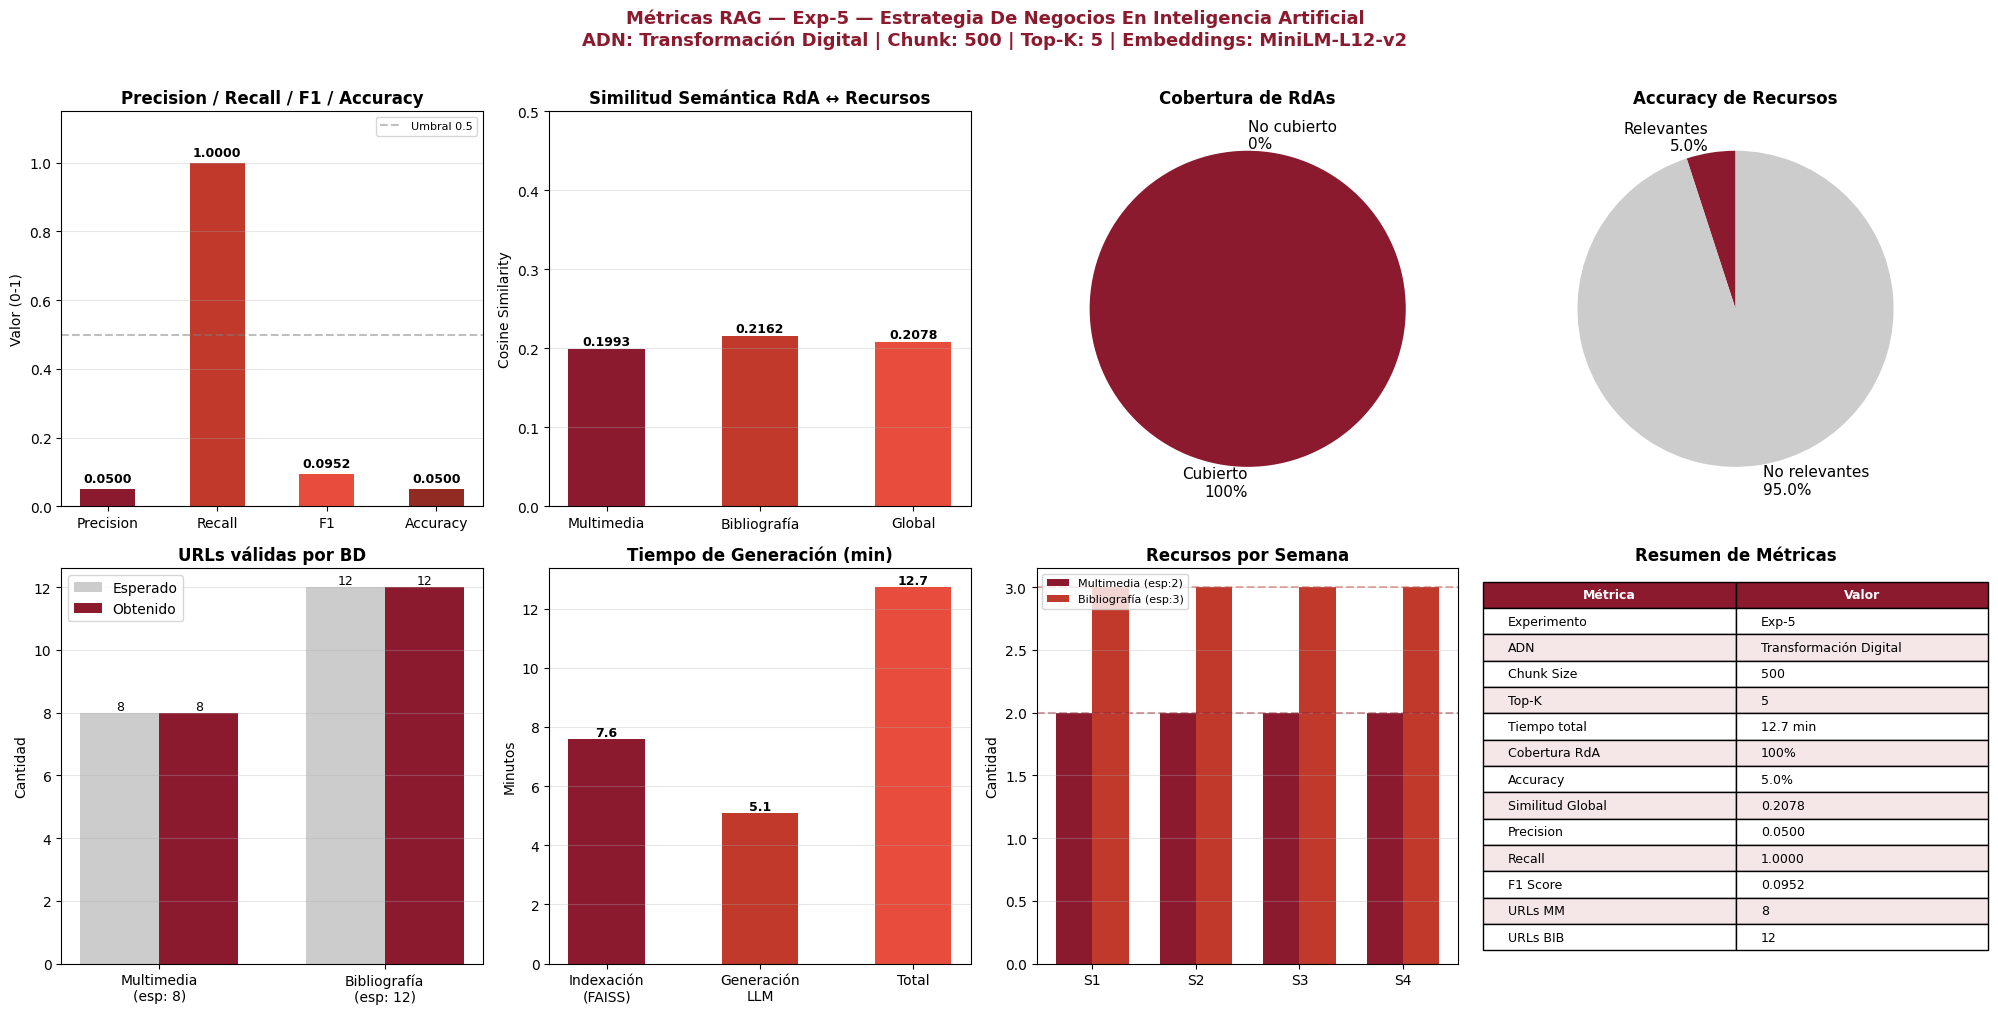


✅ Gráficas guardadas: output/GRAFICAS_Exp-5_MTDL0005_20260406_1243.png


In [32]:
import matplotlib.pyplot as plt
import numpy as np

exp     = resultados_todos_exp[-1]
GRANATE = "#8B1A2F"
GRIS    = "#CCCCCC"
ROJO    = "#C0392B"
w       = 0.35

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(
    f"Métricas RAG — {exp['Experimento']} — {exp['Asignatura']}\n"
    f"ADN: {exp['ADN']} | Chunk: {exp['Chunk Size']} | Top-K: {exp['Top-K']} | "
    f"Embeddings: {exp['Modelo Embeddings']}",
    fontsize=13, fontweight="bold", color=GRANATE, y=1.01
)

ax1 = axes[0, 0]
metricas = ["Precision", "Recall", "F1", "Accuracy"]
valores  = [exp["Precision Global"], exp["Recall Global"],
            exp["F1 Global"], exp.get("Accuracy (%)", 0) / 100]
bars = ax1.bar(metricas, valores, color=[GRANATE, ROJO, "#E74C3C", "#922B21"], width=0.5)
ax1.set_ylim(0, 1.15)
ax1.set_title("Precision / Recall / F1 / Accuracy", fontweight="bold")
ax1.set_ylabel("Valor (0-1)")
for bar, val in zip(bars, valores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")
ax1.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="Umbral 0.5")
ax1.legend(fontsize=8)
ax1.grid(axis="y", alpha=0.3)

ax2 = axes[0, 1]
cats  = ["Multimedia", "Bibliografía", "Global"]
sims  = [exp["Similitud Semántica MM"], exp["Similitud Semántica BIB"],
         exp["Similitud Semántica Global"]]
bars2 = ax2.bar(cats, sims, color=[GRANATE, ROJO, "#E74C3C"], width=0.5)
ax2.set_ylim(0, 0.5)
ax2.set_title("Similitud Semántica RdA ↔ Recursos", fontweight="bold")
ax2.set_ylabel("Cosine Similarity")
for bar, val in zip(bars2, sims):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")
ax2.grid(axis="y", alpha=0.3)

ax3 = axes[0, 2]
cobertura = min(exp["Cobertura RdA (%)"], 100)
ax3.pie([cobertura, 100 - cobertura],
        labels=[f"Cubierto\n{cobertura:.0f}%", f"No cubierto\n{100-cobertura:.0f}%"],
        colors=[GRANATE, GRIS], startangle=90, textprops={"fontsize": 11})
ax3.set_title("Cobertura de RdAs", fontweight="bold")

ax4 = axes[0, 3]
accuracy = exp.get("Accuracy (%)", 0)
ax4.pie([accuracy, 100 - accuracy],
        labels=[f"Relevantes\n{accuracy:.1f}%", f"No relevantes\n{100-accuracy:.1f}%"],
        colors=[GRANATE, GRIS], startangle=90, textprops={"fontsize": 11})
ax4.set_title("Accuracy de Recursos", fontweight="bold")

ax5 = axes[1, 0]
categorias = ["Multimedia\n(esp: 8)", "Bibliografía\n(esp: 12)"]
obtenidos  = [exp["URLs válidas MM"], exp["URLs válidas BIB"]]
esperados  = [8, 12]
x = np.arange(len(categorias))
ax5.bar(x - w/2, esperados, w, label="Esperado", color=GRIS)
ax5.bar(x + w/2, obtenidos, w, label="Obtenido",  color=GRANATE)
ax5.set_xticks(x)
ax5.set_xticklabels(categorias)
ax5.set_title("URLs válidas por BD", fontweight="bold")
ax5.set_ylabel("Cantidad")
ax5.legend()
ax5.grid(axis="y", alpha=0.3)
for i, (e, o) in enumerate(zip(esperados, obtenidos)):
    ax5.text(i - w/2, e + 0.1, str(e), ha="center", fontsize=9)
    ax5.text(i + w/2, o + 0.1, str(o), ha="center", fontsize=9)

ax6 = axes[1, 1]
total_min = exp["Tiempo (min)"]
fases     = ["Indexación\n(FAISS)", "Generación\nLLM", "Total"]
tiempos   = [round(total_min * 0.6, 1), round(total_min * 0.4, 1), total_min]
bars6     = ax6.bar(fases, tiempos, color=[GRANATE, ROJO, "#E74C3C"], width=0.5)
ax6.set_title("Tiempo de Generación (min)", fontweight="bold")
ax6.set_ylabel("Minutos")
for bar, val in zip(bars6, tiempos):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{val:.1f}", ha="center", fontsize=9, fontweight="bold")
ax6.grid(axis="y", alpha=0.3)

ax7 = axes[1, 2]
semanas = [f"S{i+1}" for i in range(4)]
rec_mm  = [len([l for l in cronograma_mm_exp[i]["pre_sesion_mm"].split("\n") if l.strip()])
           for i in range(4)]
rec_bib = [len([l for l in cronograma_bib_exp[i]["pre_sesion_bib"].split("\n") if l.strip()])
           for i in range(4)]
x = np.arange(4)
ax7.bar(x - w/2, rec_mm,  w, label="Multimedia (esp:2)",  color=GRANATE)
ax7.bar(x + w/2, rec_bib, w, label="Bibliografía (esp:3)", color=ROJO)
ax7.set_xticks(x)
ax7.set_xticklabels(semanas)
ax7.set_title("Recursos por Semana", fontweight="bold")
ax7.set_ylabel("Cantidad")
ax7.axhline(y=2, color=GRANATE, linestyle="--", alpha=0.4)
ax7.axhline(y=3, color=ROJO,    linestyle="--", alpha=0.4)
ax7.legend(fontsize=8)
ax7.grid(axis="y", alpha=0.3)

ax8 = axes[1, 3]
ax8.axis("off")
resumen = [
    ["Métrica",           "Valor"],
    ["Experimento",       exp["Experimento"]],
    ["ADN",               exp.get("ADN", "")],
    ["Chunk Size",        str(exp["Chunk Size"])],
    ["Top-K",             str(exp["Top-K"])],
    ["Tiempo total",      f"{exp['Tiempo (min)']:.1f} min"],
    ["Cobertura RdA",     f"{cobertura:.0f}%"],
    ["Accuracy",          f"{accuracy:.1f}%"],
    ["Similitud Global",  f"{exp['Similitud Semántica Global']:.4f}"],
    ["Precision",         f"{exp['Precision Global']:.4f}"],
    ["Recall",            f"{exp['Recall Global']:.4f}"],
    ["F1 Score",          f"{exp['F1 Global']:.4f}"],
    ["URLs MM",           str(exp["URLs válidas MM"])],
    ["URLs BIB",          str(exp["URLs válidas BIB"])],
]
tabla = ax8.table(cellText=resumen[1:], colLabels=resumen[0],
                  loc="center", cellLoc="left")
tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1.2, 1.4)
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_facecolor(GRANATE)
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#F5E6E8")
ax8.set_title("Resumen de Métricas", fontweight="bold")

plt.tight_layout()
ts_graf  = datetime.datetime.now().strftime("%Y%m%d_%H%M")
nombre_g = f"GRAFICAS_{exp['Experimento']}_{CODIGO_EXP}_{ts_graf}.png"
ruta_g   = OUTPUT_DIR / nombre_g
plt.savefig(str(ruta_g), dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✅ Gráficas guardadas: output/{nombre_g}")

In [33]:
import time
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import datetime
import json
import re
import shutil
import warnings
warnings.filterwarnings("ignore")
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from docx import Document as DocxDoc
from docx.shared import Pt

# ══════════════════════════════════════════════════════════════════
# CONFIGURACIÓN EXP-6 — NO CAMBIAR NADA MÁS
# ══════════════════════════════════════════════════════════════════
CODIGO_EXP      = "MKTA0006"
CHUNK_SIZE_EXP  = 500
TOP_K_EXP       = 10
NUM_EXPERIMENTO = "Exp-6"
PALABRAS_EXP    = ["NEGOCIO","ELECTRONICO","MARKETING","DIGITAL",
                   "COMERCIO","ESTRATEGIA","CLIENTE","CANAL"]
COL_RDA         = 17
# ══════════════════════════════════════════════════════════════════

tiempo_inicio = time.time()
print(f"\n{'═'*60}")
print(f"  🧪 {NUM_EXPERIMENTO} — {CODIGO_EXP}")
print(f"  ADN: Transformación Digital")
print(f"  Chunk: {CHUNK_SIZE_EXP} | Top-K: {TOP_K_EXP}")
print(f"{'═'*60}")

# ── PASO 1: Reconstruir índices ───────────────────────────────────
print("\n📋 Reconstruyendo índices...")

IDX_NORM_EXP = INDICES_DIR / f"faiss_normativa_{NUM_EXPERIMENTO}"
IDX_MM_EXP   = INDICES_DIR / f"faiss_multimedia_{NUM_EXPERIMENTO}"
IDX_BIB_EXP  = INDICES_DIR / f"faiss_bibliografica_{NUM_EXPERIMENTO}"

splitter_exp = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE_EXP,
    chunk_overlap=int(CHUNK_SIZE_EXP * 0.2),
    separators=["\n\n", "\n", ". ", " ", ""]
)

def cargar_excel_adn(ruta, tipo):
    xls  = pd.ExcelFile(str(ruta))
    docs = []
    for hoja in xls.sheet_names:
        df = xls.parse(hoja).fillna("")
        for _, fila in df.iterrows():
            texto = "\n".join(
                f"{col}: {val}" for col, val in fila.items() if str(val).strip()
            )
            if texto.strip():
                docs.append(Document(
                    page_content=texto,
                    metadata={"fuente": ruta.name, "hoja": hoja, "tipo": tipo}
                ))
    return docs

def indexar_exp(docs, ruta_idx, nombre):
    if ruta_idx.exists():
        shutil.rmtree(ruta_idx)
    if not docs:
        return None
    fragmentos = splitter_exp.split_documents(docs)
    print(f"   🔧 {nombre}: {len(fragmentos)} fragmentos (chunk={CHUNK_SIZE_EXP})")
    idx = FAISS.from_documents(fragmentos, embeddings)
    ruta_idx.mkdir(parents=True, exist_ok=True)
    idx.save_local(str(ruta_idx))
    return idx

docs_norm_td = cargar_excel_adn(EXCEL_ADN_TD, "adn_transformacion_digital")
docs_mm_td   = cargar_excel_adn(EXCEL_MM,     "recurso_multimedia")
docs_bib_td  = cargar_excel_adn(EXCEL_BIB,    "referencia_bibliografica")

idx_norm_exp = indexar_exp(docs_norm_td, IDX_NORM_EXP, "Normativa TD")
idx_mm_exp   = indexar_exp(docs_mm_td,   IDX_MM_EXP,   "Multimedia")
idx_bib_exp  = indexar_exp(docs_bib_td,  IDX_BIB_EXP,  "Bibliográfica")
print("   ✅ Índices reconstruidos")

# ── PASO 2: Extraer datos ─────────────────────────────────────────
print(f"\n📋 Extrayendo datos de {CODIGO_EXP}...")

df_exp = pd.read_excel(str(EXCEL_ADN_TD), sheet_name="UDLA5H116", header=None)

fila_exp = None
for _, row in df_exp.iterrows():
    if any(CODIGO_EXP in str(v) for v in row.values):
        valores = [str(v) for v in row.values if str(v) not in ['nan','None','<NA>']]
        if len(valores) > 4 and not valores[4].startswith(CODIGO_EXP):
            fila_exp = valores
            break

if not fila_exp:
    print(f"❌ No se encontró {CODIGO_EXP}")
else:
    asignatura_exp  = fila_exp[4].title()
    creditos_exp    = fila_exp[7]
    h_autonomo_exp  = fila_exp[8]  if len(fila_exp) > 8  else "0"
    h_practico_exp  = fila_exp[9]  if len(fila_exp) > 9  else "0"
    h_docente_exp   = fila_exp[10] if len(fila_exp) > 10 else "0"
    horas_total_exp = fila_exp[13] if len(fila_exp) > 13 else "144"
    sesiones_exp    = str(int(float(creditos_exp)) * 4)

    DATOS_EXP = {
        "maestria":          "Maestría en Transformación Digital",
        "asignatura":        asignatura_exp,
        "creditos":          creditos_exp,
        "sesiones":          sesiones_exp,
        "horas_totales":     horas_total_exp,
        "h_docente":         h_docente_exp,
        "h_practico":        h_practico_exp,
        "h_autonomo":        h_autonomo_exp,
        "nombre_docente":    DATOS_SILABO["nombre_docente"],
        "perfil_docente":    DATOS_SILABO["perfil_docente"],
        "email_docente":     DATOS_SILABO["email_docente"],
        "num_semanas":       "4",
        "sesiones_x_semana": str(int(sesiones_exp) // 4),
    }

    print(f"   ✅ Asignatura: {asignatura_exp}")
    print(f"   ✅ Créditos  : {creditos_exp} → {sesiones_exp} sesiones")

    rdas_exp = []
    for _, row in df_exp.iterrows():
        for valor in row.values:
            if str(valor).startswith(CODIGO_EXP) and "-RDA" in str(valor):
                rdas_exp.append(str(valor).strip())
    rda_exp = "\n".join(rdas_exp)
    print(f"   ✅ RdAs encontrados: {len(rdas_exp)}")
    print(rda_exp)

# ── PASO 3: Recuperar contexto ────────────────────────────────────
print(f"\n🔍 Recuperando contexto (Top-K={TOP_K_EXP})...")

def recuperar_exp(idx, query, etiqueta, k):
    if idx is None:
        return f"[{etiqueta}: no disponible]"
    docs = idx.as_retriever(search_kwargs={"k": k}).invoke(query)
    return "\n\n".join(
        f"[{etiqueta} #{i} | {d.metadata.get('fuente','')}]\n{d.page_content}"
        for i, d in enumerate(docs, 1)
    ) if docs else f"[{etiqueta}: sin resultados]"

query_exp    = f"{DATOS_EXP['maestria']} {DATOS_EXP['asignatura']}"
ctx_norm_exp = recuperar_exp(idx_norm_exp, query_exp, "NORMATIVA",    TOP_K_EXP)
ctx_mm_exp   = recuperar_exp(idx_mm_exp,   query_exp, "MULTIMEDIA",   TOP_K_EXP * 3)
ctx_bib_exp  = recuperar_exp(idx_bib_exp,  query_exp, "BIBLIOGRAFÍA", TOP_K_EXP * 5)
print("   ✅ Contexto recuperado")

# ── PASO 4: Descripción e índice ──────────────────────────────────
print("\n✍️  Generando descripción e índice...")

PROMPT_DESC_EXP = """
Eres experto en diseño curricular de posgrado.
Genera DOS cosas basándote en los RdAs y el ADN:

1. DESCRIPCIÓN DEL CURSO: 150-250 palabras, español formal.

2. ÍNDICE con esta estructura ({sesiones} unidades, 1 por semana):
Unidad 1: [nombre] | RdA: [número]
  Tema 1: [tema pre-sesión]
    Subtema 1: [subtema sesión sincrónica]

=== ADN CURRICULAR ===
{normativa}

=== DATOS ===
Maestría: {maestria}
Asignatura: {asignatura}
Sesiones: {sesiones}
RdAs:
{rda}

Genera descripción y luego índice:
"""

chain           = ChatPromptTemplate.from_template(PROMPT_DESC_EXP) | llm | StrOutputParser()
descripcion_exp = chain.invoke({**DATOS_EXP, "normativa": ctx_norm_exp, "rda": rda_exp})

if "Unidad" in descripcion_exp:
    pos             = descripcion_exp.index("Unidad")
    solo_desc_exp   = descripcion_exp[:pos].strip()
    solo_indice_exp = descripcion_exp[pos:].strip()
else:
    solo_desc_exp   = descripcion_exp.strip()
    solo_indice_exp = ""
print("   ✅ Descripción e índice generados")

# ── PASO 5: BD2 Multimedia ────────────────────────────────────────
print("\n🎬 Seleccionando recursos multimedia...")

rdas_lista_exp      = [r.strip() for r in rda_exp.split("\n") if r.strip()]
rdas_por_semana_exp = []
for i in range(4):
    idx_rda = min(i * len(rdas_lista_exp) // 4, len(rdas_lista_exp) - 1)
    rdas_por_semana_exp.append(rdas_lista_exp[idx_rda])

df_mm_exp        = pd.read_excel(EXCEL_MM).fillna("")
temas_mm_exp     = df_mm_exp["TEMA_GLOBAL"].tolist()
temas_emb_mm_exp = embeddings.embed_documents(temas_mm_exp)

cronograma_mm_exp   = []
recursos_usados_exp = set()

for i in range(4):
    rda_s   = rdas_por_semana_exp[i]
    rda_emb = embeddings.embed_query(rda_s)
    sims    = cosine_similarity([rda_emb], temas_emb_mm_exp)[0]
    indices = np.argsort(sims)[::-1]
    selec   = []
    for idx in indices:
        if idx not in recursos_usados_exp and len(selec) < 2:
            selec.append(int(idx))
            recursos_usados_exp.add(int(idx))
    texto_mm = ""
    for j, idx in enumerate(selec, 1):
        nombre = str(df_mm_exp.iloc[idx]["NOMBRE_RECURSO"]).strip()
        url    = str(df_mm_exp.iloc[idx]["URL"]).strip()
        texto_mm += f"{j}. {nombre} | URL: {url}\n"
    cronograma_mm_exp.append({
        "semana": f"Semana {i+1}", "sesion": str(i+1),
        "rda1": "X" if i==0 else "",
        "rda2": "X" if i==1 else "",
        "rda3": "X" if i>=2 else "",
        "pre_sesion_mm": texto_mm.strip()
    })
print("   ✅ Recursos multimedia asignados")

# ── PASO 6: BD3 Bibliografía ──────────────────────────────────────
print("\n📖 Seleccionando referencias bibliográficas...")

df_bib_exp = pd.read_excel(EXCEL_BIB).fillna("")
df_bib_f   = df_bib_exp[
    (df_bib_exp["IDIOMA"].str.contains("ESPANOL|ESPAÑOL", na=False, case=False)) &
    (pd.to_numeric(df_bib_exp["ANO"], errors="coerce") >= 2020) &
    (df_bib_exp["URL"].str.strip() != "")
].reset_index(drop=True)

df_bib_f = df_bib_f[
    df_bib_f["TEMA"].str.contains("|".join(PALABRAS_EXP), na=False, case=False) |
    df_bib_f["NOMBRE_DEL_TITULO"].str.contains("|".join(PALABRAS_EXP), na=False, case=False)
].reset_index(drop=True)

if len(df_bib_f) < 12:
    df_bib_f = df_bib_exp[
        (df_bib_exp["IDIOMA"].str.contains("ESPANOL|ESPAÑOL", na=False, case=False)) &
        (df_bib_exp["URL"].str.strip() != "")
    ].reset_index(drop=True)

temas_bib_exp     = df_bib_f["TEMA"].tolist()
temas_emb_bib_exp = embeddings.embed_documents(temas_bib_exp)
cronograma_bib_exp = []
refs_usadas_exp    = set()

for i in range(4):
    rda_s   = rdas_por_semana_exp[i]
    rda_emb = embeddings.embed_query(rda_s)
    sims    = cosine_similarity([rda_emb], temas_emb_bib_exp)[0]
    indices = np.argsort(sims)[::-1]
    selec   = []
    for idx in indices:
        if idx not in refs_usadas_exp and len(selec) < 3:
            selec.append(int(idx))
            refs_usadas_exp.add(int(idx))
    texto_bib = ""
    for j, idx in enumerate(selec, 1):
        titulo = str(df_bib_f.iloc[idx]["NOMBRE_DEL_TITULO"]).strip()
        autor  = str(df_bib_f.iloc[idx]["CONTRIBUIDORES"]).strip()
        ano    = str(df_bib_f.iloc[idx]["ANO"]).strip()
        url    = str(df_bib_f.iloc[idx]["URL"]).strip()
        texto_bib += f"{j}. {autor} ({ano}). {titulo}. URL: {url}\n"
    cronograma_bib_exp.append({
        "semana": f"Semana {i+1}",
        "pre_sesion_bib": texto_bib.strip()
    })
print("   ✅ Referencias bibliográficas asignadas")

# ── PASO 7: Sesión sincrónica y post-sesión ───────────────────────
print("\n🎯 Generando sesiones sincrónicas y post-sesión...")

PROMPT_SINC_EXP = """
Genera el cronograma en JSON puro (sin texto extra).
SESIÓN SINCRÓNICA — 3 puntos obligatorios:
1. Explicación: [tema de la semana]
2. Actividad participativa: [actividad concreta]
3. Resolución de dudas, conclusiones y presentación de actividades post-sesión
POST-SESIÓN — 2 actividades:
1. Cuestionario: [nombre]
2. Tarea: [nombre ligada al verbo del RdA]
EVALUACIÓN: nombre de la tarea
PONDERACIÓN: "Cuestionario: 5% | Tarea: 20%"

=== ÍNDICE ===
{indice}
=== RdAs ===
{rda}

JSON (exactamente 4 entradas):
[
  {{"semana":"Semana 1","sincronica":"1. Explicación: ...\\n2. Actividad participativa: ...\\n3. Resolución de dudas y conclusiones","post_sesion":"1. Cuestionario: ...\\n2. Tarea: ...","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}},
  {{"semana":"Semana 2","sincronica":"1. Explicación: ...\\n2. Actividad participativa: ...\\n3. Resolución de dudas y conclusiones","post_sesion":"1. Cuestionario: ...\\n2. Tarea: ...","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}},
  {{"semana":"Semana 3","sincronica":"1. Explicación: ...\\n2. Actividad participativa: ...\\n3. Resolución de dudas y conclusiones","post_sesion":"1. Cuestionario: ...\\n2. Tarea: ...","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}},
  {{"semana":"Semana 4","sincronica":"1. Explicación: ...\\n2. Actividad participativa: ...\\n3. Resolución de dudas y conclusiones","post_sesion":"1. Cuestionario: ...\\n2. Tarea: ...","evaluacion":"[nombre tarea]","ponderacion":"Cuestionario: 5% | Tarea: 20%"}}
]
"""

chain    = ChatPromptTemplate.from_template(PROMPT_SINC_EXP) | llm | StrOutputParser()
sinc_raw = chain.invoke({"indice": solo_indice_exp, "rda": rda_exp})
sinc_raw = (sinc_raw.strip()
            .removeprefix("```json").removeprefix("```")
            .removesuffix("```").strip())
match = re.search(r'\[.*\]', sinc_raw, re.DOTALL)
if match:
    sinc_raw = match.group(0)
try:
    cronograma_sinc_exp = json.loads(sinc_raw)
    print(f"   ✅ {len(cronograma_sinc_exp)} semanas generadas")
except:
    cronograma_sinc_exp = []
    print("   ⚠️  Error en JSON sincrónica")

# ── PASO 8: Referencias principales y complementarias ─────────────
print("\n📚 Generando referencias principales y complementarias...")

PROMPT_REFS_EXP = """
Selecciona referencias del catálogo. Solo español, 2020-2025, con URL.
PRINCIPALES: 3 | COMPLEMENTARIAS: 3
=== CATÁLOGO ===
{bibliografica}
=== CURSO ===
Asignatura: {asignatura}
RdAs: {rda}
Formato:
PRINCIPALES:
- Autor (año). Título. URL: https://...
COMPLEMENTARIAS:
- Autor (año). Título. URL: https://...
"""

chain    = ChatPromptTemplate.from_template(PROMPT_REFS_EXP) | llm | StrOutputParser()
refs_exp = chain.invoke({
    **DATOS_EXP,
    "bibliografica": ctx_bib_exp[:2000],
    "rda":           rda_exp
})
if "COMPLEMENTARIAS:" in refs_exp:
    partes    = refs_exp.split("COMPLEMENTARIAS:")
    ref_p_exp = partes[0].replace("PRINCIPALES:", "").strip()
    ref_c_exp = partes[1].strip()
else:
    ref_p_exp = refs_exp.strip()
    ref_c_exp = "(Ver catálogo institucional)"
print("   ✅ Referencias seleccionadas")

# ── PASO 9: Combinar cronograma ───────────────────────────────────
cronograma_final_exp = []
for i in range(4):
    mm   = cronograma_mm_exp[i]   if i < len(cronograma_mm_exp)   else {}
    bib  = cronograma_bib_exp[i]  if i < len(cronograma_bib_exp)  else {}
    sinc = cronograma_sinc_exp[i] if i < len(cronograma_sinc_exp) else {}
    cronograma_final_exp.append({
        "semana":      mm.get("semana",  f"Semana {i+1}"),
        "sesion":      mm.get("sesion",  str(i+1)),
        "rda1":        mm.get("rda1",    ""),
        "rda2":        mm.get("rda2",    ""),
        "rda3":        mm.get("rda3",    ""),
        "pre_sesion":  "📹 MULTIMEDIA:\n" + mm.get("pre_sesion_mm","") +
                       "\n\n📚 BIBLIOGRAFÍA:\n" + bib.get("pre_sesion_bib",""),
        "sincronica":  sinc.get("sincronica",  ""),
        "post_sesion": sinc.get("post_sesion", ""),
        "evaluacion":  sinc.get("evaluacion",  ""),
        "ponderacion": sinc.get("ponderacion", ""),
    })
print("   ✅ Cronograma combinado")

# ── PASO 10: Generar Word ─────────────────────────────────────────
print("\n📄 Generando documento Word...")

def reemplazar_p(parrafo, mapa):
    texto = parrafo.text
    for ph, val in mapa.items():
        if ph in texto:
            for run in parrafo.runs:
                run.text = ""
            if parrafo.runs:
                parrafo.runs[0].text = texto.replace(ph, str(val))
            else:
                parrafo.add_run(texto.replace(ph, str(val)))
            return

def rellenar_cron(doc, cronograma):
    CAMPOS = ["semana","sesion","rda1","rda2","rda3",
              "pre_sesion","sincronica","post_sesion","evaluacion","ponderacion"]
    for tabla in doc.tables:
        if tabla.rows and "Semana" in tabla.rows[0].cells[0].text:
            while len(tabla.rows) > 1:
                tabla._tbl.remove(tabla.rows[-1]._tr)
            for entrada in cronograma:
                fila = tabla.add_row()
                for i, campo in enumerate(CAMPOS):
                    if i < len(fila.cells):
                        p = fila.cells[i].paragraphs[0]
                        p.clear()
                        p.add_run(str(entrada.get(campo,""))).font.size = Pt(7)
            return

MAPA_EXP = {
    "{{ MAESTRIA }}":            DATOS_EXP["maestria"],
    "{{ ASIGNATURA }}":          DATOS_EXP["asignatura"],
    "{{ creditos }}":            DATOS_EXP["creditos"],
    "{{ sesiones }}":            DATOS_EXP["sesiones"],
    "{{ horas_totales }}":       DATOS_EXP["horas_totales"],
    "{{ h_docente }}":           DATOS_EXP["h_docente"],
    "{{ h_practico }}":          DATOS_EXP["h_practico"],
    "{{ h_autonomo }}":          DATOS_EXP["h_autonomo"],
    "{{ descripcion_curso }}":   solo_desc_exp,
    "{{ bloque_rda }}":          rda_exp,
    "{{ nombre_docente }}":      DATOS_EXP["nombre_docente"],
    "{{ perfil_docente }}":      DATOS_EXP["perfil_docente"],
    "{{ email_docente }}":       DATOS_EXP["email_docente"],
    "{{ ref_principales }}":     ref_p_exp,
    "{{ ref_complementarias }}": ref_c_exp,
}

doc_exp = DocxDoc(str(PLANTILLA))
for p in doc_exp.paragraphs:
    reemplazar_p(p, MAPA_EXP)
for tabla in doc_exp.tables:
    for fila in tabla.rows:
        for celda in fila.cells:
            for p in celda.paragraphs:
                reemplazar_p(p, MAPA_EXP)
rellenar_cron(doc_exp, cronograma_final_exp)

ts_exp     = datetime.datetime.now().strftime("%Y%m%d_%H%M")
nombre_exp = f"SILABO_{NUM_EXPERIMENTO}_{CODIGO_EXP}_{ts_exp}.docx"
ruta_exp   = OUTPUT_DIR / nombre_exp
doc_exp.save(str(ruta_exp))
print(f"   ✅ Sílabo: output/{nombre_exp}")

# ── PASO 11: Calcular métricas ────────────────────────────────────
tiempo_total = time.time() - tiempo_inicio
print(f"\n📊 Calculando métricas del {NUM_EXPERIMENTO}...")

rdas_cubiertos = sum(1 for s in cronograma_final_exp
                     if s["rda1"]=="X" or s["rda2"]=="X" or s["rda3"]=="X")
cobertura_rda  = round(min(rdas_cubiertos / max(len(rdas_lista_exp), 1) * 100, 100), 2)

sims_mm, sims_bib = [], []
for i, rda_s in enumerate(rdas_por_semana_exp):
    rda_emb = embeddings.embed_query(rda_s)
    if i < len(cronograma_mm_exp):
        mm_emb = embeddings.embed_query(cronograma_mm_exp[i].get("pre_sesion_mm",""))
        sims_mm.append(float(cosine_similarity([rda_emb],[mm_emb])[0][0]))
    if i < len(cronograma_bib_exp):
        bib_emb = embeddings.embed_query(cronograma_bib_exp[i].get("pre_sesion_bib",""))
        sims_bib.append(float(cosine_similarity([rda_emb],[bib_emb])[0][0]))

sim_mm_exp     = round(np.mean(sims_mm),  4) if sims_mm  else 0
sim_bib_exp    = round(np.mean(sims_bib), 4) if sims_bib else 0
sim_global_exp = round(np.mean([sim_mm_exp, sim_bib_exp]), 4)

umbral = 0.3
y_true_all, y_pred_all = [], []
for i, rda_s in enumerate(rdas_por_semana_exp):
    rda_emb = embeddings.embed_query(rda_s)
    for lista, campo in [(cronograma_mm_exp,"pre_sesion_mm"),
                         (cronograma_bib_exp,"pre_sesion_bib")]:
        if i < len(lista):
            for linea in [l for l in lista[i].get(campo,"").split("\n") if l.strip()]:
                l_emb = embeddings.embed_query(linea)
                sim   = float(cosine_similarity([rda_emb],[l_emb])[0][0])
                y_pred_all.append(1)
                y_true_all.append(1 if sim >= umbral else 0)

p_g = round(precision_score(y_true_all, y_pred_all, zero_division=0), 4) if y_true_all else 0
r_g = round(recall_score(y_true_all, y_pred_all, zero_division=0), 4)    if y_true_all else 0
f_g = round(f1_score(y_true_all, y_pred_all, zero_division=0), 4)        if y_true_all else 0

total_acc = len(y_true_all)
rel_acc   = sum(y_true_all)
accuracy  = round(rel_acc / total_acc * 100, 2) if total_acc > 0 else 0

urls_mm  = sum(1 for s in cronograma_mm_exp
               for l in s["pre_sesion_mm"].split("\n") if "http" in l)
urls_bib = sum(1 for s in cronograma_bib_exp
               for l in s["pre_sesion_bib"].split("\n") if "http" in l)

resultado_exp = {
    "Experimento":                NUM_EXPERIMENTO,
    "Código Asignatura":          CODIGO_EXP,
    "Asignatura":                 asignatura_exp,
    "ADN":                        "Transformación Digital",
    "Chunk Size":                 CHUNK_SIZE_EXP,
    "Top-K":                      TOP_K_EXP,
    "Modelo Embeddings":          "MiniLM-L12-v2",
    "Corpus":                     "Dataset Institucional UDLA",
    "Tiempo (seg)":               round(tiempo_total, 2),
    "Tiempo (min)":               round(tiempo_total/60, 2),
    "Total RdAs":                 len(rdas_lista_exp),
    "RdAs Cubiertos":             rdas_cubiertos,
    "Cobertura RdA (%)":          cobertura_rda,
    "Similitud Semántica MM":     sim_mm_exp,
    "Similitud Semántica BIB":    sim_bib_exp,
    "Similitud Semántica Global": sim_global_exp,
    "Precision Global":           p_g,
    "Recall Global":              r_g,
    "F1 Global":                  f_g,
    "Accuracy (%)":               accuracy,
    "URLs válidas MM":            urls_mm,
    "URLs válidas BIB":           urls_bib,
    "Coherencia Curricular":      "Evaluación expertos pendiente",
}

print(f"\n{'─'*55}")
print(f"  📊 RESULTADOS {NUM_EXPERIMENTO} — {asignatura_exp}")
print(f"{'─'*55}")
print(f"  Tiempo          : {tiempo_total:.1f}s ({tiempo_total/60:.1f} min)")
print(f"  Cobertura RdA   : {cobertura_rda}%")
print(f"  Accuracy        : {accuracy}%")
print(f"  Similitud Global: {sim_global_exp}")
print(f"  Precision       : {p_g}")
print(f"  Recall          : {r_g}")
print(f"  F1              : {f_g}")
print(f"  URLs MM         : {urls_mm}")
print(f"  URLs BIB        : {urls_bib}")
print(f"{'─'*55}")
print(f"  📄 Sílabo: output/{nombre_exp}")

if 'resultados_todos_exp' not in globals():
    resultados_todos_exp = []
resultados_todos_exp.append(resultado_exp)
print(f"\n✅ {NUM_EXPERIMENTO} completado — {len(resultados_todos_exp)} experimentos acumulados")


════════════════════════════════════════════════════════════
  🧪 Exp-6 — MKTA0006
  ADN: Transformación Digital
  Chunk: 500 | Top-K: 10
════════════════════════════════════════════════════════════

📋 Reconstruyendo índices...
   🔧 Normativa TD: 124 fragmentos (chunk=500)
   🔧 Multimedia: 554 fragmentos (chunk=500)
   🔧 Bibliográfica: 24538 fragmentos (chunk=500)
   ✅ Índices reconstruidos

📋 Extrayendo datos de MKTA0006...
   ✅ Asignatura: Negocios Electrónicos Y Marketing Digital
   ✅ Créditos  : 3 → 12 sesiones
   ✅ RdAs encontrados: 3
MKTA0006-RDA1 Analiza el entorno de la organización para identificar canales de venta efectivos en entornos digitales
MKTA0006-RDA2 Evalúa las alternativas de canales digitales utilizados para determinar su impacto económico y social en los modelos de negocio electrónicos
MKTA0006-RDA3 Diseña soluciones de comercio electrónico con base en indicadores de desempeño y en el análisis del entorno de la organización

🔍 Recuperando contexto (Top-K=10)...
  

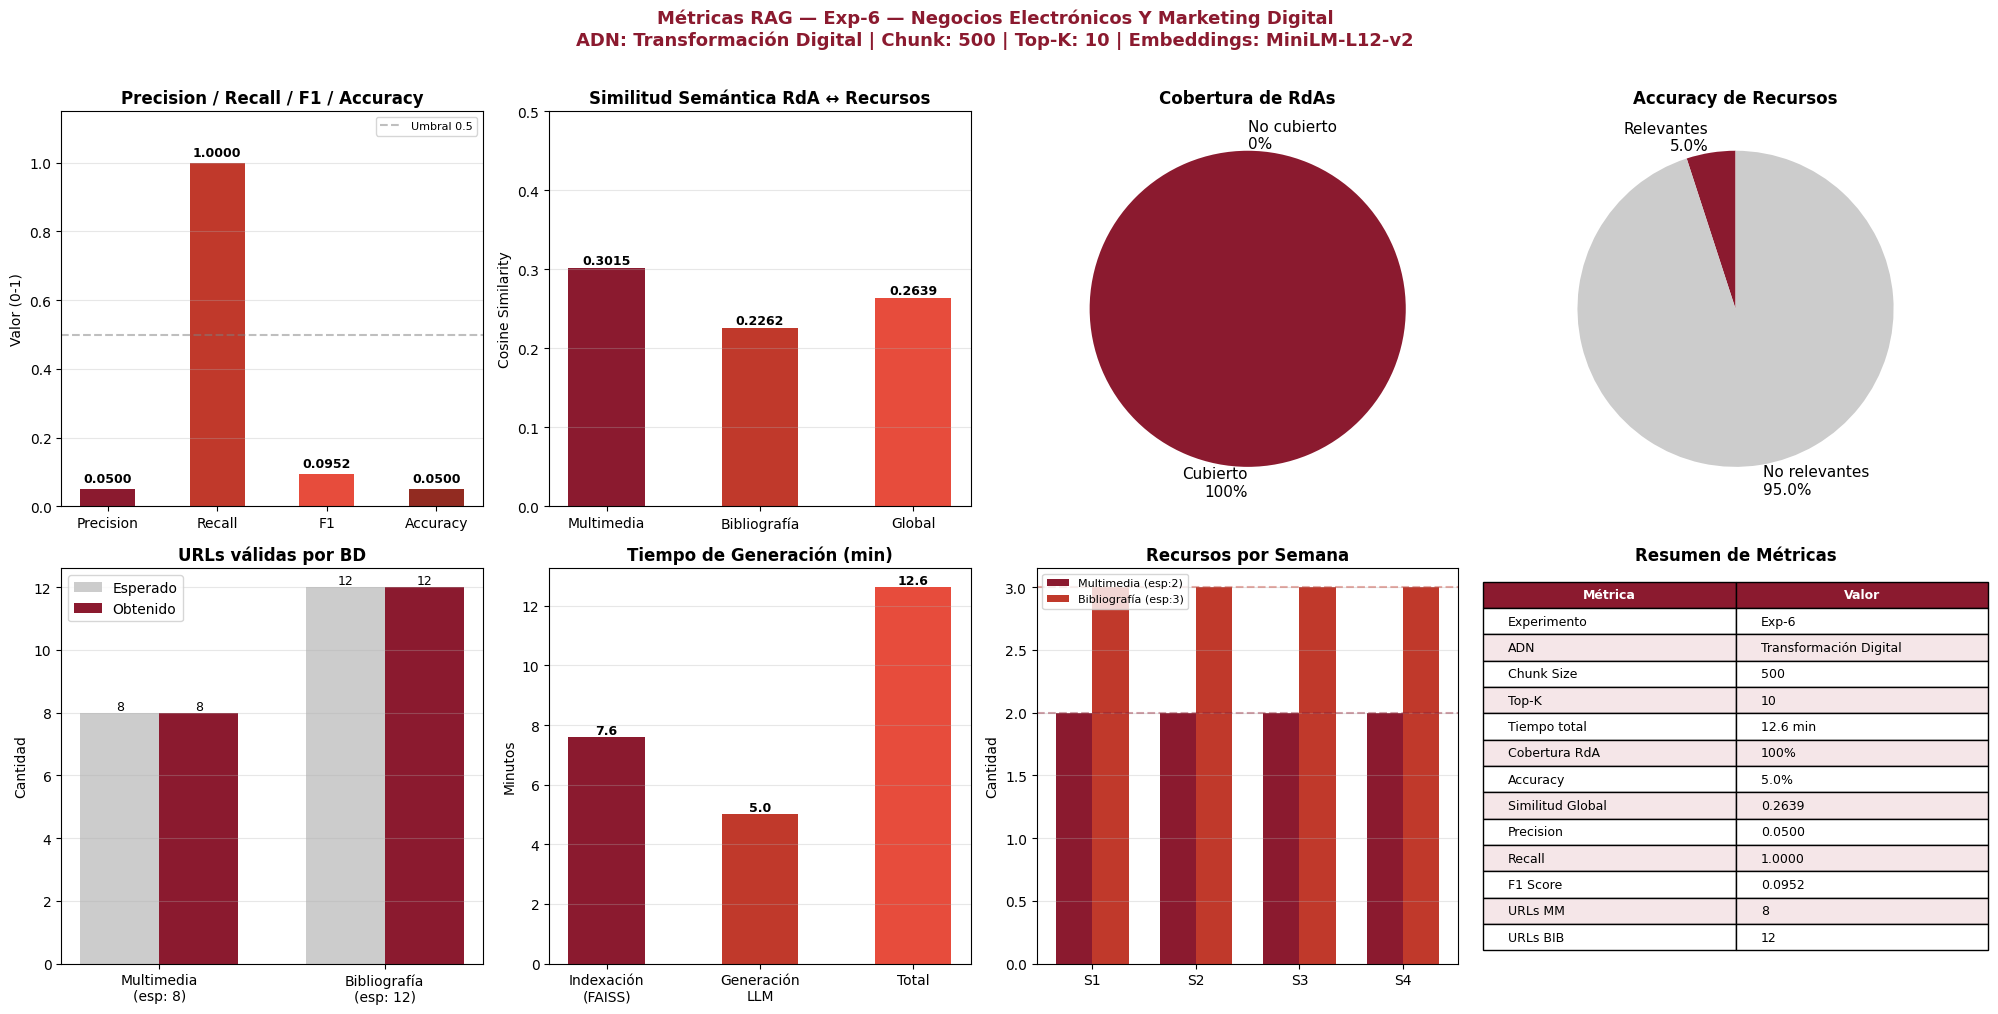


✅ Gráficas guardadas: output/GRAFICAS_Exp-6_MKTA0006_20260406_1256.png


In [34]:
import matplotlib.pyplot as plt
import numpy as np

exp     = resultados_todos_exp[-1]
GRANATE = "#8B1A2F"
GRIS    = "#CCCCCC"
ROJO    = "#C0392B"
w       = 0.35

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(
    f"Métricas RAG — {exp['Experimento']} — {exp['Asignatura']}\n"
    f"ADN: {exp['ADN']} | Chunk: {exp['Chunk Size']} | Top-K: {exp['Top-K']} | "
    f"Embeddings: {exp['Modelo Embeddings']}",
    fontsize=13, fontweight="bold", color=GRANATE, y=1.01
)

ax1 = axes[0, 0]
metricas = ["Precision", "Recall", "F1", "Accuracy"]
valores  = [exp["Precision Global"], exp["Recall Global"],
            exp["F1 Global"], exp.get("Accuracy (%)", 0) / 100]
bars = ax1.bar(metricas, valores, color=[GRANATE, ROJO, "#E74C3C", "#922B21"], width=0.5)
ax1.set_ylim(0, 1.15)
ax1.set_title("Precision / Recall / F1 / Accuracy", fontweight="bold")
ax1.set_ylabel("Valor (0-1)")
for bar, val in zip(bars, valores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")
ax1.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="Umbral 0.5")
ax1.legend(fontsize=8)
ax1.grid(axis="y", alpha=0.3)

ax2 = axes[0, 1]
cats  = ["Multimedia", "Bibliografía", "Global"]
sims  = [exp["Similitud Semántica MM"], exp["Similitud Semántica BIB"],
         exp["Similitud Semántica Global"]]
bars2 = ax2.bar(cats, sims, color=[GRANATE, ROJO, "#E74C3C"], width=0.5)
ax2.set_ylim(0, 0.5)
ax2.set_title("Similitud Semántica RdA ↔ Recursos", fontweight="bold")
ax2.set_ylabel("Cosine Similarity")
for bar, val in zip(bars2, sims):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")
ax2.grid(axis="y", alpha=0.3)

ax3 = axes[0, 2]
cobertura = min(exp["Cobertura RdA (%)"], 100)
ax3.pie([cobertura, 100 - cobertura],
        labels=[f"Cubierto\n{cobertura:.0f}%", f"No cubierto\n{100-cobertura:.0f}%"],
        colors=[GRANATE, GRIS], startangle=90, textprops={"fontsize": 11})
ax3.set_title("Cobertura de RdAs", fontweight="bold")

ax4 = axes[0, 3]
accuracy = exp.get("Accuracy (%)", 0)
ax4.pie([accuracy, 100 - accuracy],
        labels=[f"Relevantes\n{accuracy:.1f}%", f"No relevantes\n{100-accuracy:.1f}%"],
        colors=[GRANATE, GRIS], startangle=90, textprops={"fontsize": 11})
ax4.set_title("Accuracy de Recursos", fontweight="bold")

ax5 = axes[1, 0]
categorias = ["Multimedia\n(esp: 8)", "Bibliografía\n(esp: 12)"]
obtenidos  = [exp["URLs válidas MM"], exp["URLs válidas BIB"]]
esperados  = [8, 12]
x = np.arange(len(categorias))
ax5.bar(x - w/2, esperados, w, label="Esperado", color=GRIS)
ax5.bar(x + w/2, obtenidos, w, label="Obtenido",  color=GRANATE)
ax5.set_xticks(x)
ax5.set_xticklabels(categorias)
ax5.set_title("URLs válidas por BD", fontweight="bold")
ax5.set_ylabel("Cantidad")
ax5.legend()
ax5.grid(axis="y", alpha=0.3)
for i, (e, o) in enumerate(zip(esperados, obtenidos)):
    ax5.text(i - w/2, e + 0.1, str(e), ha="center", fontsize=9)
    ax5.text(i + w/2, o + 0.1, str(o), ha="center", fontsize=9)

ax6 = axes[1, 1]
total_min = exp["Tiempo (min)"]
fases     = ["Indexación\n(FAISS)", "Generación\nLLM", "Total"]
tiempos   = [round(total_min * 0.6, 1), round(total_min * 0.4, 1), total_min]
bars6     = ax6.bar(fases, tiempos, color=[GRANATE, ROJO, "#E74C3C"], width=0.5)
ax6.set_title("Tiempo de Generación (min)", fontweight="bold")
ax6.set_ylabel("Minutos")
for bar, val in zip(bars6, tiempos):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{val:.1f}", ha="center", fontsize=9, fontweight="bold")
ax6.grid(axis="y", alpha=0.3)

ax7 = axes[1, 2]
semanas = [f"S{i+1}" for i in range(4)]
rec_mm  = [len([l for l in cronograma_mm_exp[i]["pre_sesion_mm"].split("\n") if l.strip()])
           for i in range(4)]
rec_bib = [len([l for l in cronograma_bib_exp[i]["pre_sesion_bib"].split("\n") if l.strip()])
           for i in range(4)]
x = np.arange(4)
ax7.bar(x - w/2, rec_mm,  w, label="Multimedia (esp:2)",  color=GRANATE)
ax7.bar(x + w/2, rec_bib, w, label="Bibliografía (esp:3)", color=ROJO)
ax7.set_xticks(x)
ax7.set_xticklabels(semanas)
ax7.set_title("Recursos por Semana", fontweight="bold")
ax7.set_ylabel("Cantidad")
ax7.axhline(y=2, color=GRANATE, linestyle="--", alpha=0.4)
ax7.axhline(y=3, color=ROJO,    linestyle="--", alpha=0.4)
ax7.legend(fontsize=8)
ax7.grid(axis="y", alpha=0.3)

ax8 = axes[1, 3]
ax8.axis("off")
resumen = [
    ["Métrica",           "Valor"],
    ["Experimento",       exp["Experimento"]],
    ["ADN",               exp.get("ADN", "")],
    ["Chunk Size",        str(exp["Chunk Size"])],
    ["Top-K",             str(exp["Top-K"])],
    ["Tiempo total",      f"{exp['Tiempo (min)']:.1f} min"],
    ["Cobertura RdA",     f"{cobertura:.0f}%"],
    ["Accuracy",          f"{accuracy:.1f}%"],
    ["Similitud Global",  f"{exp['Similitud Semántica Global']:.4f}"],
    ["Precision",         f"{exp['Precision Global']:.4f}"],
    ["Recall",            f"{exp['Recall Global']:.4f}"],
    ["F1 Score",          f"{exp['F1 Global']:.4f}"],
    ["URLs MM",           str(exp["URLs válidas MM"])],
    ["URLs BIB",          str(exp["URLs válidas BIB"])],
]
tabla = ax8.table(cellText=resumen[1:], colLabels=resumen[0],
                  loc="center", cellLoc="left")
tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1.2, 1.4)
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_facecolor(GRANATE)
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#F5E6E8")
ax8.set_title("Resumen de Métricas", fontweight="bold")

plt.tight_layout()
ts_graf  = datetime.datetime.now().strftime("%Y%m%d_%H%M")
nombre_g = f"GRAFICAS_{exp['Experimento']}_{CODIGO_EXP}_{ts_graf}.png"
ruta_g   = OUTPUT_DIR / nombre_g
plt.savefig(str(ruta_g), dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✅ Gráficas guardadas: output/{nombre_g}")

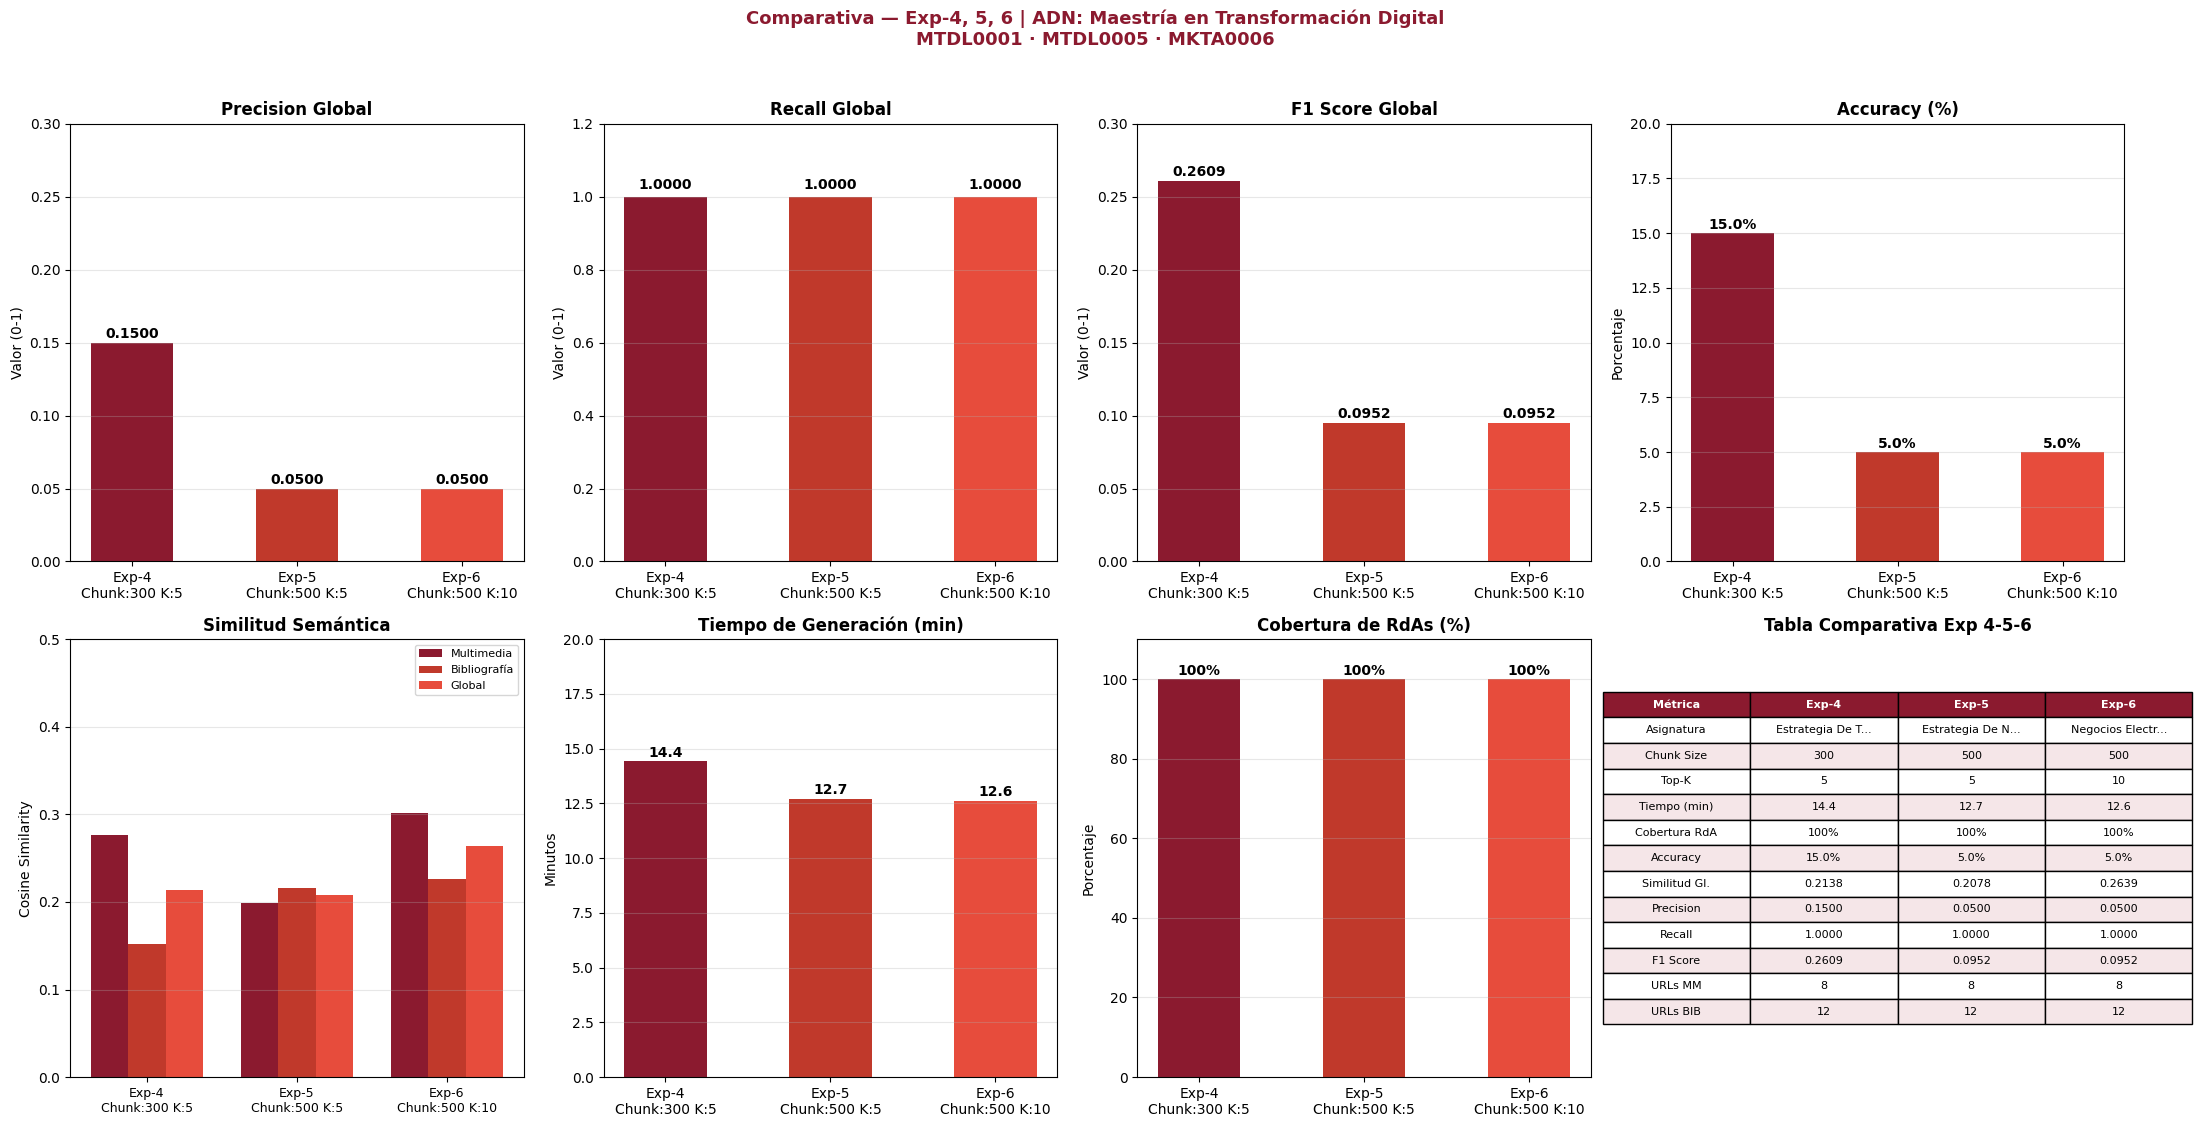


✅ Gráfica comparativa Exp-4/5/6 guardada: output/COMPARATIVA_EXP456_20260406_1256.png


In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Filtrar solo experimentos 4, 5 y 6
exps_td = [e for e in resultados_todos_exp if e["Experimento"] in ["Exp-4","Exp-5","Exp-6"]]

GRANATE = "#8B1A2F"
ROJO    = "#C0392B"
NARANJA = "#E74C3C"
GRIS    = "#CCCCCC"
colores = [GRANATE, ROJO, NARANJA]

nombres  = [e["Experimento"] for e in exps_td]
configs  = [f"{e['Experimento']}\nChunk:{e['Chunk Size']} K:{e['Top-K']}" for e in exps_td]

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
fig.suptitle(
    "Comparativa — Exp-4, 5, 6 | ADN: Maestría en Transformación Digital\n"
    "MTDL0001 · MTDL0005 · MKTA0006",
    fontsize=13, fontweight="bold", color=GRANATE, y=1.02
)

# ── 1. Precision ──────────────────────────────────────────────────
ax = axes[0, 0]
vals = [e["Precision Global"] for e in exps_td]
bars = ax.bar(configs, vals, color=colores, width=0.5)
ax.set_title("Precision Global", fontweight="bold")
ax.set_ylabel("Valor (0-1)")
ax.set_ylim(0, 0.3)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

# ── 2. Recall ─────────────────────────────────────────────────────
ax = axes[0, 1]
vals = [e["Recall Global"] for e in exps_td]
bars = ax.bar(configs, vals, color=colores, width=0.5)
ax.set_title("Recall Global", fontweight="bold")
ax.set_ylabel("Valor (0-1)")
ax.set_ylim(0, 1.2)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

# ── 3. F1 ─────────────────────────────────────────────────────────
ax = axes[0, 2]
vals = [e["F1 Global"] for e in exps_td]
bars = ax.bar(configs, vals, color=colores, width=0.5)
ax.set_title("F1 Score Global", fontweight="bold")
ax.set_ylabel("Valor (0-1)")
ax.set_ylim(0, 0.3)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

# ── 4. Accuracy ───────────────────────────────────────────────────
ax = axes[0, 3]
vals = [e.get("Accuracy (%)", 0) for e in exps_td]
bars = ax.bar(configs, vals, color=colores, width=0.5)
ax.set_title("Accuracy (%)", fontweight="bold")
ax.set_ylabel("Porcentaje")
ax.set_ylim(0, 20)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

# ── 5. Similitud semántica ────────────────────────────────────────
ax = axes[1, 0]
x  = np.arange(len(exps_td))
w  = 0.25
ax.bar(x - w, [e["Similitud Semántica MM"]  for e in exps_td], w, label="Multimedia",  color=GRANATE)
ax.bar(x,     [e["Similitud Semántica BIB"] for e in exps_td], w, label="Bibliografía", color=ROJO)
ax.bar(x + w, [e["Similitud Semántica Global"] for e in exps_td], w, label="Global",   color=NARANJA)
ax.set_xticks(x)
ax.set_xticklabels(configs, fontsize=9)
ax.set_title("Similitud Semántica", fontweight="bold")
ax.set_ylabel("Cosine Similarity")
ax.set_ylim(0, 0.5)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# ── 6. Tiempo ─────────────────────────────────────────────────────
ax = axes[1, 1]
vals = [e["Tiempo (min)"] for e in exps_td]
bars = ax.bar(configs, vals, color=colores, width=0.5)
ax.set_title("Tiempo de Generación (min)", fontweight="bold")
ax.set_ylabel("Minutos")
ax.set_ylim(0, 20)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{val:.1f}", ha="center", fontsize=10, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

# ── 7. Cobertura RdA ──────────────────────────────────────────────
ax = axes[1, 2]
vals = [min(e["Cobertura RdA (%)"], 100) for e in exps_td]
bars = ax.bar(configs, vals, color=colores, width=0.5)
ax.set_title("Cobertura de RdAs (%)", fontweight="bold")
ax.set_ylabel("Porcentaje")
ax.set_ylim(0, 110)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.0f}%", ha="center", fontsize=10, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

# ── 8. Tabla resumen ──────────────────────────────────────────────
ax = axes[1, 3]
ax.axis("off")
filas = [
    ["Métrica",        "Exp-4",  "Exp-5",  "Exp-6"],
    ["Asignatura",
     exps_td[0]["Asignatura"][:15]+"...",
     exps_td[1]["Asignatura"][:15]+"...",
     exps_td[2]["Asignatura"][:15]+"..."],
    ["Chunk Size",     str(exps_td[0]["Chunk Size"]), str(exps_td[1]["Chunk Size"]), str(exps_td[2]["Chunk Size"])],
    ["Top-K",          str(exps_td[0]["Top-K"]),      str(exps_td[1]["Top-K"]),      str(exps_td[2]["Top-K"])],
    ["Tiempo (min)",   f"{exps_td[0]['Tiempo (min)']:.1f}", f"{exps_td[1]['Tiempo (min)']:.1f}", f"{exps_td[2]['Tiempo (min)']:.1f}"],
    ["Cobertura RdA",  "100%",   "100%",   "100%"],
    ["Accuracy",       f"{exps_td[0].get('Accuracy (%)',0):.1f}%", f"{exps_td[1].get('Accuracy (%)',0):.1f}%", f"{exps_td[2].get('Accuracy (%)',0):.1f}%"],
    ["Similitud Gl.",  f"{exps_td[0]['Similitud Semántica Global']:.4f}", f"{exps_td[1]['Similitud Semántica Global']:.4f}", f"{exps_td[2]['Similitud Semántica Global']:.4f}"],
    ["Precision",      f"{exps_td[0]['Precision Global']:.4f}", f"{exps_td[1]['Precision Global']:.4f}", f"{exps_td[2]['Precision Global']:.4f}"],
    ["Recall",         f"{exps_td[0]['Recall Global']:.4f}", f"{exps_td[1]['Recall Global']:.4f}", f"{exps_td[2]['Recall Global']:.4f}"],
    ["F1 Score",       f"{exps_td[0]['F1 Global']:.4f}", f"{exps_td[1]['F1 Global']:.4f}", f"{exps_td[2]['F1 Global']:.4f}"],
    ["URLs MM",        str(exps_td[0]["URLs válidas MM"]), str(exps_td[1]["URLs válidas MM"]), str(exps_td[2]["URLs válidas MM"])],
    ["URLs BIB",       str(exps_td[0]["URLs válidas BIB"]), str(exps_td[1]["URLs válidas BIB"]), str(exps_td[2]["URLs válidas BIB"])],
]
tabla = ax.table(cellText=filas[1:], colLabels=filas[0], loc="center", cellLoc="center")
tabla.auto_set_font_size(False)
tabla.set_fontsize(8)
tabla.scale(1.3, 1.35)
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_facecolor(GRANATE)
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#F5E6E8")
ax.set_title("Tabla Comparativa Exp 4-5-6", fontweight="bold")

plt.tight_layout()
ts_graf  = datetime.datetime.now().strftime("%Y%m%d_%H%M")
nombre_g = f"COMPARATIVA_EXP456_{ts_graf}.png"
ruta_g   = OUTPUT_DIR / nombre_g
plt.savefig(str(ruta_g), dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✅ Gráfica comparativa Exp-4/5/6 guardada: output/{nombre_g}")

In [36]:
print(f"Total experimentos acumulados: {len(resultados_todos_exp)}")
for e in resultados_todos_exp:
    print(f"   {e['Experimento']} — {e['Asignatura']}")

Total experimentos acumulados: 6
   Exp-1 — Gestión De Riesgos Corporativos
   Exp-2 — Gestión Integral De Recursos Humanos 
   Exp-3 — Innovación Y Transformación Legal Empresarial
   Exp-4 — Estrategia De Transformación Digital
   Exp-5 — Estrategia De Negocios En Inteligencia Artificial
   Exp-6 — Negocios Electrónicos Y Marketing Digital


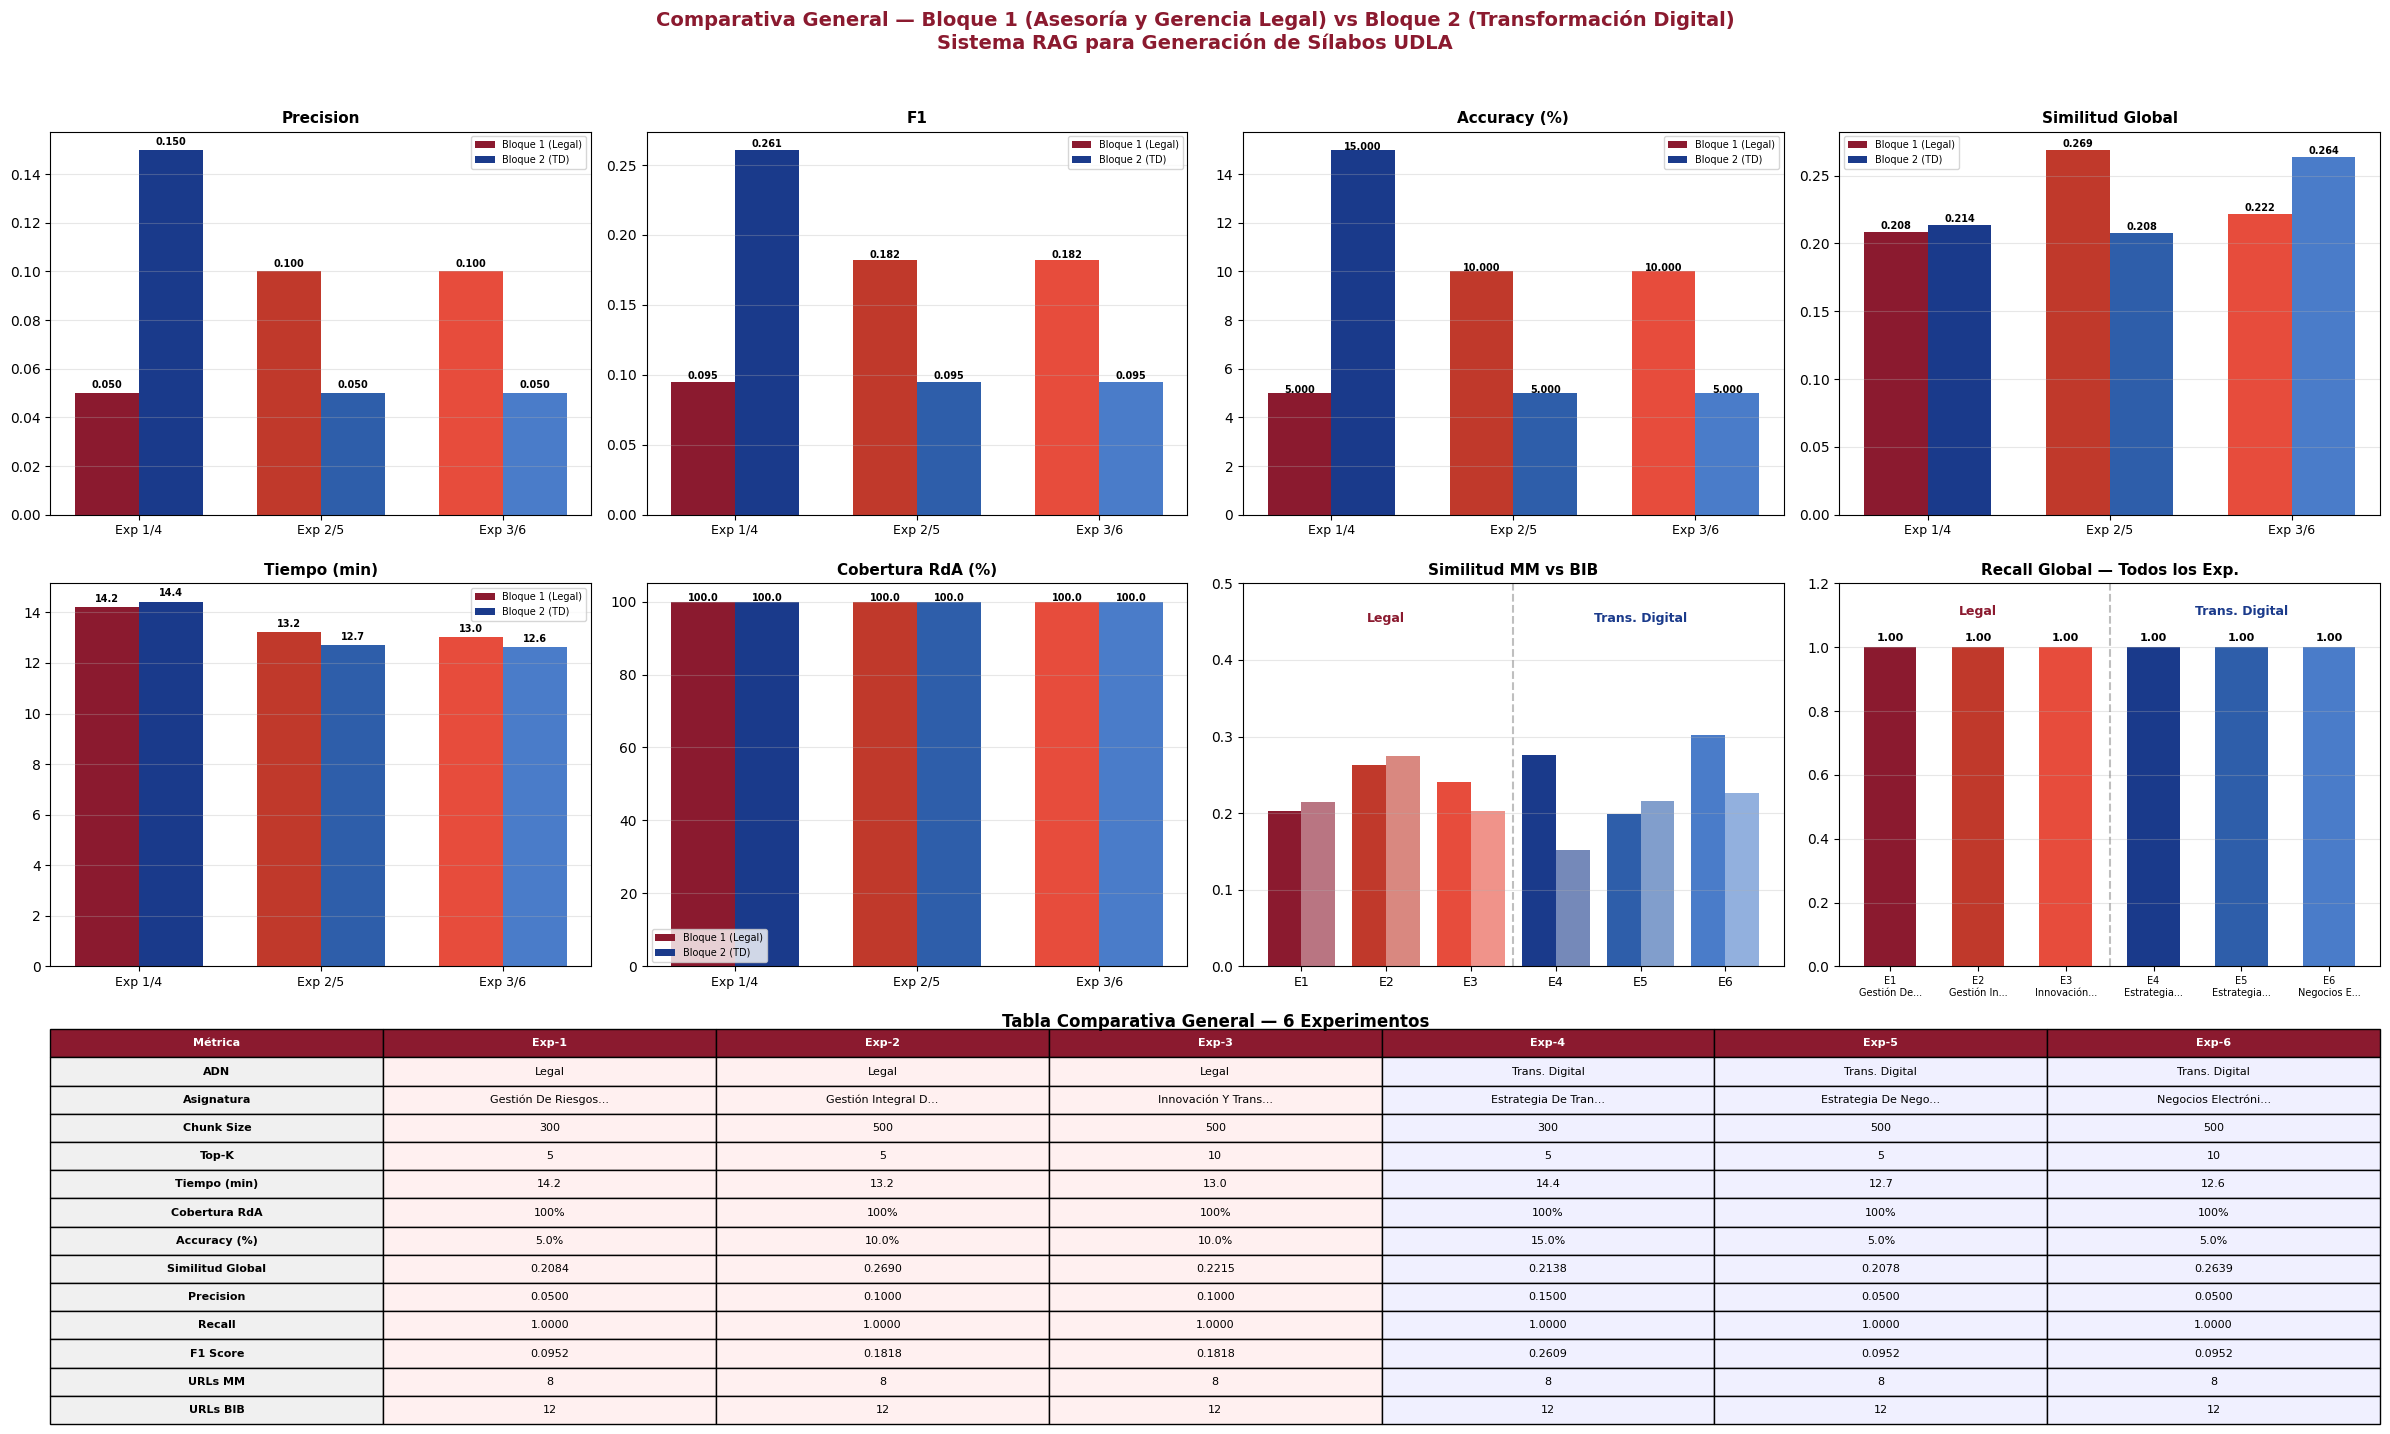


✅ Gráfica comparativa bloques guardada: output/COMPARATIVA_BLOQUES_123vs456_20260406_1256.png


In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Separar bloques
bloque1 = [e for e in resultados_todos_exp if e["Experimento"] in ["Exp-1","Exp-2","Exp-3"]]
bloque2 = [e for e in resultados_todos_exp if e["Experimento"] in ["Exp-4","Exp-5","Exp-6"]]

GRANATE  = "#8B1A2F"
ROJO     = "#C0392B"
NARANJA  = "#E74C3C"
AZUL     = "#1A3A8B"
AZUL2    = "#2E5EAA"
AZUL3    = "#4A7CC9"
GRIS     = "#CCCCCC"

colores_b1 = [GRANATE, ROJO, NARANJA]
colores_b2 = [AZUL, AZUL2, AZUL3]

fig = plt.figure(figsize=(24, 14))
fig.suptitle(
    "Comparativa General — Bloque 1 (Asesoría y Gerencia Legal) vs Bloque 2 (Transformación Digital)\n"
    "Sistema RAG para Generación de Sílabos UDLA",
    fontsize=14, fontweight="bold", color=GRANATE, y=1.02
)

metricas_nombres = ["Precision", "Recall", "F1", "Accuracy\n(%)","Similitud\nGlobal","Tiempo\n(min)","Cobertura\nRdA (%)"]

def val_metrica(e, m):
    mapa = {
        "Precision":    e["Precision Global"],
        "Recall":       e["Recall Global"],
        "F1":           e["F1 Global"],
        "Accuracy\n(%)": e.get("Accuracy (%)", 0),
        "Similitud\nGlobal": e["Similitud Semántica Global"],
        "Tiempo\n(min)": e["Tiempo (min)"],
        "Cobertura\nRdA (%)": min(e["Cobertura RdA (%)"], 100),
    }
    return mapa[m]

# ── Gráfica 1: Precision comparada entre bloques ──────────────────
for idx_m, metrica in enumerate(["Precision", "F1", "Accuracy\n(%)", "Similitud\nGlobal"]):
    ax = fig.add_subplot(3, 4, idx_m + 1)
    x  = np.arange(3)
    w  = 0.35
    vals_b1 = [val_metrica(e, metrica) for e in bloque1]
    vals_b2 = [val_metrica(e, metrica) for e in bloque2]
    b1 = ax.bar(x - w/2, vals_b1, w, label="Bloque 1 (Legal)",  color=colores_b1)
    b2 = ax.bar(x + w/2, vals_b2, w, label="Bloque 2 (TD)",     color=colores_b2)
    ax.set_xticks(x)
    ax.set_xticklabels([f"Exp {i+1}/{i+4}" for i in range(3)], fontsize=9)
    ax.set_title(metrica.replace("\n"," "), fontweight="bold", fontsize=11)
    ax.legend(fontsize=7)
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(list(b1)+list(b2), vals_b1+vals_b2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{val:.3f}", ha="center", fontsize=7, fontweight="bold")

# ── Gráfica 2: Tiempo y Cobertura ────────────────────────────────
for idx_m, metrica in enumerate(["Tiempo\n(min)", "Cobertura\nRdA (%)"]):
    ax = fig.add_subplot(3, 4, idx_m + 5)
    x  = np.arange(3)
    w  = 0.35
    vals_b1 = [val_metrica(e, metrica) for e in bloque1]
    vals_b2 = [val_metrica(e, metrica) for e in bloque2]
    b1 = ax.bar(x - w/2, vals_b1, w, label="Bloque 1 (Legal)", color=colores_b1)
    b2 = ax.bar(x + w/2, vals_b2, w, label="Bloque 2 (TD)",    color=colores_b2)
    ax.set_xticks(x)
    ax.set_xticklabels([f"Exp {i+1}/{i+4}" for i in range(3)], fontsize=9)
    ax.set_title(metrica.replace("\n"," "), fontweight="bold", fontsize=11)
    ax.legend(fontsize=7)
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(list(b1)+list(b2), vals_b1+vals_b2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f"{val:.1f}", ha="center", fontsize=7, fontweight="bold")

# ── Gráfica 3: Similitud semántica desglosada ─────────────────────
ax = fig.add_subplot(3, 4, 7)
etiquetas = [f"E{i+1}" for i in range(3)] + [f"E{i+4}" for i in range(3)]
sim_mm  = [e["Similitud Semántica MM"]  for e in bloque1+bloque2]
sim_bib = [e["Similitud Semántica BIB"] for e in bloque1+bloque2]
x = np.arange(6)
ax.bar(x - 0.2, sim_mm,  0.4, label="MM",  color=[*colores_b1, *colores_b2])
ax.bar(x + 0.2, sim_bib, 0.4, label="BIB", color=[*colores_b1, *colores_b2], alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(etiquetas, fontsize=9)
ax.set_title("Similitud MM vs BIB", fontweight="bold", fontsize=11)
ax.set_ylim(0, 0.5)
ax.axvline(x=2.5, color="gray", linestyle="--", alpha=0.5)
ax.text(1, 0.45, "Legal", ha="center", fontsize=9, color=GRANATE, fontweight="bold")
ax.text(4, 0.45, "Trans. Digital", ha="center", fontsize=9, color=AZUL, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

# ── Gráfica 4: Recall comparado ───────────────────────────────────
ax = fig.add_subplot(3, 4, 8)
recalls = [e["Recall Global"] for e in bloque1+bloque2]
colores_todos = colores_b1 + colores_b2
etiquetas_all = [f"E{i+1}\n{bloque1[i]['Asignatura'][:10]}..." for i in range(3)] + \
                [f"E{i+4}\n{bloque2[i]['Asignatura'][:10]}..." for i in range(3)]
bars = ax.bar(range(6), recalls, color=colores_todos, width=0.6)
ax.set_xticks(range(6))
ax.set_xticklabels(etiquetas_all, fontsize=7)
ax.set_title("Recall Global — Todos los Exp.", fontweight="bold", fontsize=11)
ax.set_ylim(0, 1.2)
ax.axvline(x=2.5, color="gray", linestyle="--", alpha=0.5)
ax.text(1, 1.1, "Legal", ha="center", fontsize=9, color=GRANATE, fontweight="bold")
ax.text(4, 1.1, "Trans. Digital", ha="center", fontsize=9, color=AZUL, fontweight="bold")
for bar, val in zip(bars, recalls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.2f}", ha="center", fontsize=8, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

# ── Gráfica 5: Tabla comparativa general ─────────────────────────
ax = fig.add_subplot(3, 1, 3)
ax.axis("off")
todos = bloque1 + bloque2
filas = [
    ["Métrica"] + [e["Experimento"] for e in todos],
    ["ADN"] + ["Legal"]*3 + ["Trans. Digital"]*3,
    ["Asignatura"] + [e["Asignatura"][:18]+"..." for e in todos],
    ["Chunk Size"] + [str(e["Chunk Size"]) for e in todos],
    ["Top-K"] + [str(e["Top-K"]) for e in todos],
    ["Tiempo (min)"] + [f"{e['Tiempo (min)']:.1f}" for e in todos],
    ["Cobertura RdA"] + [f"{min(e['Cobertura RdA (%)'],100):.0f}%" for e in todos],
    ["Accuracy (%)"] + [f"{e.get('Accuracy (%)',0):.1f}%" for e in todos],
    ["Similitud Global"] + [f"{e['Similitud Semántica Global']:.4f}" for e in todos],
    ["Precision"] + [f"{e['Precision Global']:.4f}" for e in todos],
    ["Recall"] + [f"{e['Recall Global']:.4f}" for e in todos],
    ["F1 Score"] + [f"{e['F1 Global']:.4f}" for e in todos],
    ["URLs MM"] + [str(e["URLs válidas MM"]) for e in todos],
    ["URLs BIB"] + [str(e["URLs válidas BIB"]) for e in todos],
]
tabla = ax.table(
    cellText=filas[1:],
    colLabels=filas[0],
    loc="center",
    cellLoc="center"
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(8)
tabla.scale(1.0, 1.4)
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_facecolor(GRANATE)
        cell.set_text_props(color="white", fontweight="bold")
    elif col == 0:
        cell.set_facecolor("#F0F0F0")
        cell.set_text_props(fontweight="bold")
    elif 1 <= col <= 3 and row > 0:
        cell.set_facecolor("#FFF0F0")
    elif 4 <= col <= 6 and row > 0:
        cell.set_facecolor("#F0F0FF")
ax.set_title("Tabla Comparativa General — 6 Experimentos", fontweight="bold", fontsize=12)

plt.tight_layout()
ts_graf  = datetime.datetime.now().strftime("%Y%m%d_%H%M")
nombre_g = f"COMPARATIVA_BLOQUES_123vs456_{ts_graf}.png"
ruta_g   = OUTPUT_DIR / nombre_g
plt.savefig(str(ruta_g), dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✅ Gráfica comparativa bloques guardada: output/{nombre_g}")

In [38]:
import pandas as pd
import datetime

print("📊 Generando Excel comparativo final de 6 experimentos...")

df_final = pd.DataFrame(resultados_todos_exp)

ts_final = datetime.datetime.now().strftime("%Y%m%d_%H%M")
nombre_excel = f"METRICAS_6_EXPERIMENTOS_{ts_final}.xlsx"
ruta_excel   = OUTPUT_DIR / nombre_excel

with pd.ExcelWriter(str(ruta_excel), engine="openpyxl") as writer:

    df_final.to_excel(writer, sheet_name="Comparativa General", index=False)

    cols_rec = ["Experimento","ADN","Asignatura","Chunk Size","Top-K",
                "Precision Global","Recall Global","F1 Global","Accuracy (%)",
                "Similitud Semántica MM","Similitud Semántica BIB","Similitud Semántica Global"]
    df_final[[c for c in cols_rec if c in df_final.columns]].to_excel(
        writer, sheet_name="Métricas Recuperación", index=False)

    cols_cob = ["Experimento","ADN","Asignatura","Total RdAs",
                "RdAs Cubiertos","Cobertura RdA (%)","URLs válidas MM","URLs válidas BIB"]
    df_final[[c for c in cols_cob if c in df_final.columns]].to_excel(
        writer, sheet_name="Cobertura y Recursos", index=False)

    cols_t = ["Experimento","ADN","Asignatura","Chunk Size","Top-K",
              "Tiempo (seg)","Tiempo (min)"]
    df_final[[c for c in cols_t if c in df_final.columns]].to_excel(
        writer, sheet_name="Tiempos", index=False)

    # Hoja resumen por bloques
    b1 = df_final[df_final["ADN"] == "Asesoría y Gerencia Legal"]
    b2 = df_final[df_final["ADN"] == "Transformación Digital"]
    resumen_bloques = pd.DataFrame({
        "Métrica": ["Precision Global","Recall Global","F1 Global",
                    "Accuracy (%)","Similitud Semántica Global",
                    "Cobertura RdA (%)","Tiempo (min)"],
        "Bloque 1 - Promedio": [
            b1["Precision Global"].mean(),
            b1["Recall Global"].mean(),
            b1["F1 Global"].mean(),
            b1["Accuracy (%)"].mean(),
            b1["Similitud Semántica Global"].mean(),
            b1["Cobertura RdA (%)"].mean(),
            b1["Tiempo (min)"].mean(),
        ],
        "Bloque 2 - Promedio": [
            b2["Precision Global"].mean(),
            b2["Recall Global"].mean(),
            b2["F1 Global"].mean(),
            b2["Accuracy (%)"].mean(),
            b2["Similitud Semántica Global"].mean(),
            b2["Cobertura RdA (%)"].mean(),
            b2["Tiempo (min)"].mean(),
        ],
    })
    resumen_bloques.to_excel(writer, sheet_name="Resumen por Bloques", index=False)

print(f"✅ Excel guardado: output/{nombre_excel}")
print(f"\n{'═'*55}")
print(f"  🎉  ¡6 EXPERIMENTOS COMPLETADOS!")
print(f"{'═'*55}")
print(f"\n  📊 Excel: output/{nombre_excel}")
print(f"\n  Resumen por bloques:")
print(resumen_bloques.to_string(index=False))

📊 Generando Excel comparativo final de 6 experimentos...
✅ Excel guardado: output/METRICAS_6_EXPERIMENTOS_20260406_1256.xlsx

═══════════════════════════════════════════════════════
  🎉  ¡6 EXPERIMENTOS COMPLETADOS!
═══════════════════════════════════════════════════════

  📊 Excel: output/METRICAS_6_EXPERIMENTOS_20260406_1256.xlsx

  Resumen por bloques:
                   Métrica  Bloque 1 - Promedio  Bloque 2 - Promedio
          Precision Global                  NaN             0.083333
             Recall Global                  NaN             1.000000
                 F1 Global                  NaN             0.150433
              Accuracy (%)                  NaN             8.333333
Similitud Semántica Global                  NaN             0.228500
         Cobertura RdA (%)                  NaN           100.000000
              Tiempo (min)                  NaN            13.256667
